# Fine-Tuning Dataset Preparation
Combine, remove duplicates, and cluster proteins based on sequence similarity for fine-tuning training/test set. 
- Datasets: BindingDB (Kd, IC50), ChEMBL (Kd, IC50), SAIR

## Configuration

In [1]:
import os
import subprocess
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
bdb_kd_csv = "/scratch/yunmin/data/graph/bdb/filtered/bindingdb_Kd_with_pdb_val_saved_pdb.csv"
bdb_ic50_csv = "/scratch/yunmin/data/graph/bdb/filtered/bindingdb_IC50_with_pdb_val_saved_pdb.csv"
chembl_kd_csv = "/scratch/yunmin/data/graph/chembl/filtered/chembl_Kd_with_pdb_val.csv"
chembl_ic50_csv = "/scratch/yunmin/data/graph/chembl/filtered/chembl_IC50_with_pdb_val.csv"
sair_csv = "/scratch/yunmin/data/graph/sair/filtered/sair_pIC50_all_tight_val.csv"

## Load data

In [3]:
def load_data(input_csv, dtype_map=None):
    print(f"Loading data from {input_csv}...")
    df = pd.read_csv(input_csv, dtype=dtype_map)
    initial_rows = len(df)

    print(f"\n✅ Loaded {initial_rows:,} rows")
    print(f"  - Columns: {df.columns.tolist()}")
    if 'protein_key' in df.columns:
        print(f"  - Unique proteins: {df['protein_key'].nunique():,}")
    elif 'protein' in df.columns:
        print(f"  - Unique proteins: {df['protein'].nunique():,}")
    print(f"  - Targets: {(df['target_type'] == 'target').sum():,}")
    print(f"  - Off-targets: {(df['target_type'] == 'off_target').sum():,}")
    print("=" * 80)
    return df

bdb_kd_df = load_data(bdb_kd_csv)
bdb_ic50_df = load_data(bdb_ic50_csv)
chembl_kd_df = load_data(chembl_kd_csv)
chembl_ic50_df = load_data(chembl_ic50_csv)
sair_df = load_data(sair_csv)

Loading data from /scratch/yunmin/data/graph/bdb/filtered/bindingdb_Kd_with_pdb_val_saved_pdb.csv...

✅ Loaded 28,033 rows
  - Columns: ['protein_key', 'uniprot_id', 'target_name', 'target_source', 'sequence', 'sequence_length', 'ligand_inchikey', 'ligand_smiles', 'ligand_name', 'ligand_het_id', 'original_Kd_nM', 'representative_assay_nM', 'target_type', 'curation_source', 'doi', 'complex_pdb_id', 'valid_pdb_id', 'validation_status']
  - Unique proteins: 445
  - Targets: 7,841
  - Off-targets: 20,192
Loading data from /scratch/yunmin/data/graph/bdb/filtered/bindingdb_IC50_with_pdb_val_saved_pdb.csv...

✅ Loaded 515,395 rows
  - Columns: ['protein_key', 'uniprot_id', 'target_name', 'target_source', 'sequence', 'sequence_length', 'ligand_inchikey', 'ligand_smiles', 'ligand_name', 'ligand_het_id', 'original_IC50_nM', 'representative_assay_nM', 'target_type', 'curation_source', 'doi', 'complex_pdb_id', 'valid_pdb_id', 'validation_status']
  - Unique proteins: 1,108
  - Targets: 252,846
  -

## Concatenate datasets

### BindingDB/ChEMBL Kd+IC50

In [4]:
def merge_assay_df(df1, df2):
    df1 = df1.copy()
    df2 = df2.copy()
    df1["assay_type"] = "Kd"
    df2["assay_type"] = "IC50"

    df1["original_assay_nM"] = df1["original_Kd_nM"]
    df2["original_assay_nM"] = df2["original_IC50_nM"]
    df1 = df1.drop(columns=["original_Kd_nM"])
    df2 = df2.drop(columns=["original_IC50_nM"])

    print(f"Merging dataframes with {len(df1):,} and {len(df2):,} rows...")
    merged_df = pd.concat([df1, df2], ignore_index=True)

    print(f"  - Columns: {merged_df.columns.tolist()}")
    if 'protein_key' in merged_df.columns:
        print(f"  - Unique proteins: {merged_df['protein_key'].nunique():,}")
    elif 'protein' in merged_df.columns:
        print(f"  - Unique proteins: {merged_df['protein'].nunique():,}")
    print(f"  - Targets: {(merged_df['target_type'] == 'target').sum():,}")
    print(f"  - Off-targets: {(merged_df['target_type'] == 'off_target').sum():,}")
    print(f"  - Kd: {(merged_df['assay_type'] == 'Kd').sum():,}")
    print(f"  - IC50: {(merged_df['assay_type'] == 'IC50').sum():,}")
    print("=" * 80)
    return merged_df

bdb_df = merge_assay_df(bdb_kd_df, bdb_ic50_df)
chembl_df = merge_assay_df(chembl_kd_df, chembl_ic50_df)

Merging dataframes with 28,033 and 515,395 rows...
  - Columns: ['protein_key', 'uniprot_id', 'target_name', 'target_source', 'sequence', 'sequence_length', 'ligand_inchikey', 'ligand_smiles', 'ligand_name', 'ligand_het_id', 'representative_assay_nM', 'target_type', 'curation_source', 'doi', 'complex_pdb_id', 'valid_pdb_id', 'validation_status', 'assay_type', 'original_assay_nM']
  - Unique proteins: 1,222
  - Targets: 260,687
  - Off-targets: 282,741
  - Kd: 28,033
  - IC50: 515,395
Merging dataframes with 75,173 and 576,831 rows...
  - Columns: ['protein_key', 'target_chembl_id', 'component_id', 'accession', 'target_name', 'target_source', 'target_tax_id', 'sequence', 'sequence_length', 'ligand_chembl_id', 'molregno', 'ligand_inchikey', 'canonical_smiles', 'compound_name', 'representative_assay_nM', 'target_type', 'n_measurements', 'assay_chembl_ids', 'doc_chembl_ids', 'doi', 'pubmed_id', 'pdb_ids', 'assay_type', 'original_assay_nM']
  - Unique proteins: 1,728
  - Targets: 269,594
  

In [5]:
# Deduplicate dataframes
key_cols = [
    "protein_key",
    "uniprot_id",
    "ligand_inchikey",
    "ligand_het_id",
    "target_type",
]

print("Deduplicating BindingDB dataframe...")
print(f"Before deduplication: {len(bdb_df):,} rows")
bdb_df_dedup = bdb_df.drop_duplicates(subset=key_cols, keep="first").reset_index(drop=True)
print(f"After deduplication: {len(bdb_df_dedup):,} rows ({len(bdb_df) - len(bdb_df_dedup):,} duplicates removed)\n")

key_cols = [
    "protein_key",
    "accession",
    "ligand_inchikey",
    "ligand_chembl_id",
    "target_type",
]
print("Deduplicating ChEMBL dataframe...")
print(f"Before deduplication: {len(chembl_df):,} rows")
chembl_df_dedup = chembl_df.drop_duplicates(subset=key_cols, keep="first").reset_index(drop=True)
print(f"After deduplication: {len(chembl_df_dedup):,} rows ({len(chembl_df) - len(chembl_df_dedup):,} duplicates removed)\n")

Deduplicating BindingDB dataframe...
Before deduplication: 543,428 rows
After deduplication: 533,126 rows (10,302 duplicates removed)

Deduplicating ChEMBL dataframe...
Before deduplication: 652,004 rows
After deduplication: 649,204 rows (2,800 duplicates removed)



### Dataset preview

In [6]:
bdb_df_dedup.head()

,protein_key,uniprot_id,target_name,target_source,sequence,sequence_length,ligand_inchikey,ligand_smiles,ligand_name,ligand_het_id,representative_assay_nM,target_type,curation_source,doi,complex_pdb_id,valid_pdb_id,validation_status,assay_type,original_assay_nM
0,C7C422_Klebsiella pneumoniae,C7C422,Metallo-beta-lactamase type 2,Klebsiella pneumoniae,MELPNIMHPVAKLSTALAAALMLSGCMPGEIRPTIGQQMETGDQRF...,270,XPRDUGXOWVXZLL-UHFFFAOYSA-N,COc1cccc(c1)-c1ccc(NC(=O)C2=C(CCC2)C(O)=O)c(F)c1,2-{[2-fluoro-4-(3-methoxyphenyl)phenyl]carbamo...,D5H,3.400000e+00,target,ChEMBL,10.1016/j.ejmech.2023.115225,5Y1J,NaN,No UniProt match,Kd,3.4
1,C7C422_Klebsiella pneumoniae,C7C422,Metallo-beta-lactamase type 2,Klebsiella pneumoniae,MELPNIMHPVAKLSTALAAALMLSGCMPGEIRPTIGQQMETGDQRF...,270,RNAHYXBPBZSDMH-CABZIAIVSA-N,CC(C)C(=O)[C@H](C)[C@H](O)[C@@]1(C)[C@H](C(C)=...,CHEMBL5398242,NaN,1.180000e+04,off_target,ChEMBL,10.1039/d3md00036b,NaN,NaN,No PDB IDs,Kd,11800
2,C7C422_Klebsiella pneumoniae,C7C422,Metallo-beta-lactamase type 2,Klebsiella pneumoniae,MELPNIMHPVAKLSTALAAALMLSGCMPGEIRPTIGQQMETGDQRF...,270,FAKRSMQSSFJEIM-RQJHMYQMSA-N,C[C@H](CS)C(=O)N1CCC[C@H]1C(O)=O,(2S)-1-[(2S)-2-methyl-3-sulfanylpropanoyl]pyrr...,X8Z,4.350000e+05,off_target,ChEMBL,10.1021/acs.jmedchem.3c00171,"4C1D,4C1F,4C1H,4DPR,3LUS,6V61,5ZIO,8SKO,4EXS,2...",5ZIO,Valid,Kd,435000
3,C7C422_Klebsiella pneumoniae,C7C422,Metallo-beta-lactamase type 2,Klebsiella pneumoniae,MELPNIMHPVAKLSTALAAALMLSGCMPGEIRPTIGQQMETGDQRF...,270,KCYKSHQJSXQPFL-UHFFFAOYSA-N,OP(O)(=O)C(NC(=O)Cc1cccs1)C1CCCCN1,CHEMBL5430990,NaN,8.366600e+05,off_target,ChEMBL,NaN,NaN,NaN,No PDB IDs,Kd,1400000; 500000
4,C7C422_Klebsiella pneumoniae,C7C422,Metallo-beta-lactamase type 2,Klebsiella pneumoniae,MELPNIMHPVAKLSTALAAALMLSGCMPGEIRPTIGQQMETGDQRF...,270,CAGUYJHZPXSDRT-UHFFFAOYSA-N,OP(O)(=O)C(NC(=O)c1cccs1)C1CCCCN1,CHEMBL5403793,NaN,2.000000e+06,off_target,ChEMBL,NaN,NaN,NaN,No PDB IDs,Kd,2000000


In [7]:
chembl_df_dedup.head()

,protein_key,target_chembl_id,component_id,accession,target_name,target_source,target_tax_id,sequence,sequence_length,ligand_chembl_id,...,representative_assay_nM,target_type,n_measurements,assay_chembl_ids,doc_chembl_ids,doi,pubmed_id,pdb_ids,assay_type,original_assay_nM
0,CHEMBL_CHEMBL1075026_COMP_4041_Streptomyces_av...,CHEMBL1075026,4041,P22629,Streptavidin,Streptomyces avidinii,1895,MRKIVVAAIAVSLTTVSITASASADPSKDSKAQVSAAEAGITGTWY...,183,CHEMBL857,...,0.00001,target,1,CHEMBL3369575,CHEMBL3351755,10.1021/jm500325k,24913411.0,1DF8;1HQQ;1HXL;1HXZ;1HY2;1I9H;1KFF;1KL3;1KL4;1...,Kd,1e-05
1,CHEMBL_CHEMBL1075026_COMP_4041_Streptomyces_av...,CHEMBL1075026,4041,P22629,Streptavidin,Streptomyces avidinii,1895,MRKIVVAAIAVSLTTVSITASASADPSKDSKAQVSAAEAGITGTWY...,183,CHEMBL280317,...,11.00000,target,1,CHEMBL3369575,CHEMBL3351755,10.1021/jm500325k,24913411.0,1DF8;1HQQ;1HXL;1HXZ;1HY2;1I9H;1KFF;1KL3;1KL4;1...,Kd,11.0
2,CHEMBL_CHEMBL1075026_COMP_4041_Streptomyces_av...,CHEMBL1075026,4041,P22629,Streptavidin,Streptomyces avidinii,1895,MRKIVVAAIAVSLTTVSITASASADPSKDSKAQVSAAEAGITGTWY...,183,CHEMBL477,...,168000.00000,off_target,1,CHEMBL2210840,CHEMBL2202973,10.1016/j.bmcl.2012.09.088,23084893.0,1DF8;1HQQ;1HXL;1HXZ;1HY2;1I9H;1KFF;1KL3;1KL4;1...,Kd,168000.0
3,CHEMBL_CHEMBL1075092_COMP_4396_Homo_sapiens,CHEMBL1075092,4396,O75311,Glycine receptor subunit alpha-3,Homo sapiens,9606,MAHVRHFRTLVSGFYFWEAALLLSLVATKETDSARSRSAPMSPSDF...,464,CHEMBL4070615,...,11.00000,target,1,CHEMBL3993231,CHEMBL3992512,10.1021/acs.jmedchem.6b01496,28001399.0,5CFB;5TIN;5TIO;5VDH;5VDI;9BU2;9BU3;9BVH;9BVJ;9...,Kd,11.0
4,CHEMBL_CHEMBL1075092_COMP_4396_Homo_sapiens,CHEMBL1075092,4396,O75311,Glycine receptor subunit alpha-3,Homo sapiens,9606,MAHVRHFRTLVSGFYFWEAALLLSLVATKETDSARSRSAPMSPSDF...,464,CHEMBL4081234,...,20000.00000,off_target,1,CHEMBL3993231,CHEMBL3992512,10.1021/acs.jmedchem.6b01496,28001399.0,5CFB;5TIN;5TIO;5VDH;5VDI;9BU2;9BU3;9BVH;9BVJ;9...,Kd,20000.0


In [8]:
sair_df.head()

,entry_id,index,protein,sequence,sequence_length,ligand_smiles,pIC50,target_type,source,assay,family,description,vina_score_min,number_clashes,internal_energy,confidence_score,complex_plddt,complex_iplddt,ptm,iptm
0,654,0,A0A0G2K344,MPPRPSSGELWGIHLMPPRILVECLLPNGMIVTLECLREATLVTIK...,1068,C[C@H]1OC(=O)N(c2nc(-c3cnc(N)nc3C(F)(F)F)cc(N3...,5.338621,off_target,ChEMBL,cell,kinase,Inhibition of PI3Kalpha in rat Rat1 cells asse...,-10.7393,1.0,1.0,0.930772,0.916796,0.899851,0.967878,0.986674
1,674,1,A0A0G2K344,MPPRPSSGELWGIHLMPPRILVECLLPNGMIVTLECLREATLVTIK...,1068,Nc1cc(C(F)(F)F)c(-c2cc(NC(CO)Cc3ccccc3)nc(N3CC...,5.209330,off_target,ChEMBL,cell,kinase,Inhibition of PI3Kalpha in rat Rat1 cells asse...,-8.8858,1.0,1.0,0.921381,0.912904,0.847111,0.957527,0.955291
2,662,1,A0A0G2K344,MPPRPSSGELWGIHLMPPRILVECLLPNGMIVTLECLREATLVTIK...,1068,Cn1c(=O)n(-c2ccc(C(C)(C)C#N)cc2)c2c3cc(-c4cnc5...,8.277862,target,ChEMBL,cell,kinase,Inhibition of PI3Kalpha in rat Rat1 cells asse...,-11.6466,1.0,1.0,0.928460,0.914086,0.895977,0.964621,0.985958
3,634,4,A0A0G2K344,MPPRPSSGELWGIHLMPPRILVECLLPNGMIVTLECLREATLVTIK...,1068,CC1C(c2cccnc2)OC(=O)N1c1cc(-c2cnc(N)nc2C(F)(F)...,7.537602,target,BindingDB,na,kinase,US10202371,-10.7742,1.0,1.0,0.921728,0.910370,0.871247,0.957377,0.967160
4,660,1,A0A0G2K344,MPPRPSSGELWGIHLMPPRILVECLLPNGMIVTLECLREATLVTIK...,1068,C[C@H]1[C@H](c2nccs2)OC(=O)N1c1cc(-c2cnc(N)nc2...,7.508638,target,BindingDB,na,kinase,US10202371,-10.3188,1.0,1.0,0.925128,0.912977,0.879408,0.965920,0.973730



  - Columns: ['protein_key', 'uniprot_id', 'target_name', 'target_source', 'sequence', 'sequence_length', 'ligand_inchikey', 'ligand_smiles', 'ligand_name', 'ligand_het_id', 'representative_assay_nM', 'target_type', 'curation_source', 'doi', 'complex_pdb_id', 'valid_pdb_id', 'validation_status', 'assay_type', 'original_assay_nM']
  - Columns: ['protein_key', 'accession', 'target_name', 'target_source', 'sequence', 'sequence_length', 'ligand_inchikey', 'canonical_smiles', 'compound_name', ('ligand_het_id'), 'representative_assay_nM', 'target_type', 'doc_chembl_ids', 'doi', 'pdb_ids', ('valid_pdb_id', 'validation_status',) 'assay_type', 'original_assay_nM']
  - Columns: ['entry_id', 'index', 'protein', 'sequence', 'sequence_length', 'ligand_smiles', 'pIC50', 'target_type', 'source', 'assay', 'family', 'description', 'vina_score_min', 'number_clashes', 'internal_energy', 'confidence_score', 'complex_plddt', 'complex_iplddt', 'ptm', 'iptm']
  
  -> 'protein_key' = 'entry_id'_'index'
    'protein' -> 'uniprot_id'
    ('target_name', 'target_source',) 'sequence', 'sequence_length', 
    ('ligand_inchikey'), 'ligand_smiles', ('ligand_name', 'ligand_het_id',)
    'pIC50' -> 'representative_asssay_nM' (unit conversion to nM), 'target_type',
    'source' -> 'curation_source', 
    drop 'assay', 
    'doi', 'complex_pdb_id', 'valid_pdb_id' ('protein_key'), 
    'validation_status' -> all True, 
    'assay_type' -> all IC50, 
    'original_assay_nM' -> 'pIC50'
    after follows sair original columns: 'family', 'description', 'vina_score_min', 'number_clashes', 'internal_energy', 'confidence_score', 'complex_plddt', 'complex_iplddt', 'ptm', 'iptm'


### BindingDB + ChEMBL

In [9]:
# Concatenate BindingDB and ChEMBL dataframes
bdb_df_copy = bdb_df_dedup.copy()
chembl_df_copy = chembl_df_dedup.copy()
chembl_df_copy = chembl_df_copy[[
    'protein_key', 'accession', 'target_name', 'target_source', 
    'sequence', 'sequence_length', 'ligand_inchikey', 'canonical_smiles', 
    'compound_name', 'representative_assay_nM', 'target_type', 
    'doi', 'pdb_ids', 'assay_type', 'original_assay_nM'
    ]]
# dropped 
# ['target_chembl_id', 'component_id', 'target_tax_id', 
# 'ligand_chembl_id', 'molregno', 
# 'n_measurements', 'assay_chembl_ids', 'doc_chembl_ids', 'pubmed_id']
chembl_df_copy = chembl_df_copy.rename(columns={
    "accession": "uniprot_id",
    "canonical_smiles": "ligand_smiles",
    "compound_name": "ligand_name",
    "pdb_ids": "complex_pdb_id",
    })

bdb_df_copy["data_source"] = "BindingDB"
chembl_df_copy["data_source"] = "ChEMBL"

print(f"Merging dataframes with {len(bdb_df_copy):,} and {len(chembl_df_copy):,} rows...")
bdb_chembl_df = pd.concat([bdb_df_copy, chembl_df_copy], ignore_index=True)
print(f"  - Columns: {bdb_chembl_df.columns.tolist()}")
print(f"  - Unique proteins: {bdb_chembl_df['protein_key'].nunique():,}")
n_tar = (bdb_chembl_df['target_type'] == 'target').sum()
n_off = (bdb_chembl_df['target_type'] == 'off_target').sum()
total = n_tar + n_off
print(f"  - Targets: {n_tar:,} ({n_tar/total*100:.2f}%)")
print(f"  - Off-targets: {n_off:,} ({n_off/total*100:.2f}%)")
n_Kd = (bdb_chembl_df['assay_type'] == 'Kd').sum()
n_IC50 = (bdb_chembl_df['assay_type'] == 'IC50').sum()
total = n_Kd + n_IC50
print(f"  - Kd: {n_Kd:,} ({n_Kd/total*100:.2f}%)")
print(f"  - IC50: {n_IC50:,} ({n_IC50/total*100:.2f}%)")
print("=" * 80)

# Deduplicate combined BindingDB + ChEMBL dataframe
key_cols = [
    "uniprot_id",
    "ligand_inchikey",
    "target_type",
    "sequence",
]

print("Deduplicating BindingDB + ChEMBL dataframe...")
print(f"Before deduplication: {len(bdb_chembl_df):,} rows")
bdb_chembl_df_dedup = bdb_chembl_df.drop_duplicates(subset=key_cols, keep="first").reset_index(drop=True)
print(f"After deduplication: {len(bdb_chembl_df_dedup):,} rows ({len(bdb_chembl_df) - len(bdb_chembl_df_dedup):,} duplicates removed)\n")

dup_mask = bdb_chembl_df.duplicated(subset=key_cols, keep="first")
removed_df = bdb_chembl_df[dup_mask]
removed_unique_uniprot = removed_df["uniprot_id"].nunique()
removed_unique_ligand = removed_df["ligand_inchikey"].nunique()

print(f"Unique uniprot_id in removed rows: {removed_unique_uniprot:,}")
print(f"Unique ligand_inchikey in removed rows: {removed_unique_ligand:,}")

Merging dataframes with 533,126 and 649,204 rows...
  - Columns: ['protein_key', 'uniprot_id', 'target_name', 'target_source', 'sequence', 'sequence_length', 'ligand_inchikey', 'ligand_smiles', 'ligand_name', 'ligand_het_id', 'representative_assay_nM', 'target_type', 'curation_source', 'doi', 'complex_pdb_id', 'valid_pdb_id', 'validation_status', 'assay_type', 'original_assay_nM', 'data_source']
  - Unique proteins: 2,950
  - Targets: 522,216 (44.17%)
  - Off-targets: 660,114 (55.83%)
  - Kd: 102,930 (8.71%)
  - IC50: 1,079,400 (91.29%)
Deduplicating BindingDB + ChEMBL dataframe...
Before deduplication: 1,182,330 rows
After deduplication: 811,972 rows (370,358 duplicates removed)

Unique uniprot_id in removed rows: 875
Unique ligand_inchikey in removed rows: 265,059


### BindingDB + ChEMBL + SAIR

In [10]:
bdb_chembl_df_dedup_copy = bdb_chembl_df_dedup.copy()
sair_df_copy = sair_df.copy()

sair_df_copy = sair_df_copy[[
    'entry_id', 'index', 'protein', 'sequence', 'sequence_length', 
    'ligand_smiles', 'pIC50', 'target_type', 'source',
    # sair original columns
    'family', 'description', 'vina_score_min', 'number_clashes', 'internal_energy', 
    'confidence_score', 'complex_plddt', 'complex_iplddt', 'ptm', 'iptm'
    ]]
# dropped: 'assay'
sair_df_copy = sair_df_copy.rename(columns={
    "protein": "uniprot_id",
    "source": "curation_source",
    })

sair_df_copy["data_source"] = "SAIR"

sair_df_copy["protein_key"] = sair_df_copy["entry_id"].astype(str) + "_" + sair_df_copy["index"].astype(str)
sair_df_copy["valid_pdb_id"] = sair_df_copy["protein_key"]
sair_df_copy["representative_assay_nM"] = sair_df_copy["pIC50"].apply(lambda x: 10 ** (9 - x) if pd.notnull(x) else x)
sair_df_copy["original_assay_nM"] = sair_df_copy["pIC50"].apply(lambda x: 10 ** (9 - x) if pd.notnull(x) else x)
sair_df_copy["validation_status"] = "Valid"
sair_df_copy["assay_type"] = "IC50"

cols_to_tag = [
    'entry_id', 'index', 'pIC50', 'family', 'description',
    'vina_score_min', 'number_clashes', 'internal_energy',
    'confidence_score', 'complex_plddt', 'complex_iplddt',
    'ptm', 'iptm'
]
rename_map = {col: f"{col} (SAIR)" for col in cols_to_tag if col in sair_df_copy.columns}
sair_df_copy = sair_df_copy.rename(columns=rename_map)

print(f"Merging dataframes with {len(bdb_chembl_df_dedup_copy):,} and {len(sair_df_copy):,} rows...")
total_df = pd.concat([bdb_chembl_df_dedup_copy, sair_df_copy], ignore_index=True)
print(f"  - Columns: {total_df.columns.tolist()}")
print(f"  - Unique proteins: {total_df['protein_key'].nunique():,}")
print(f"  - Unique proteins: {total_df[['uniprot_id', 'sequence']].drop_duplicates().shape[0]:,}")
n_tar = (total_df['target_type'] == 'target').sum()
n_off = (total_df['target_type'] == 'off_target').sum()
total = n_tar + n_off
print(f"  - Targets: {n_tar:,} ({n_tar/total*100:.2f}%)")
print(f"  - Off-targets: {n_off:,} ({n_off/total*100:.2f}%)")
n_Kd = (total_df['assay_type'] == 'Kd').sum()
n_IC50 = (total_df['assay_type'] == 'IC50').sum()
total = n_Kd + n_IC50
print(f"  - Kd: {n_Kd:,} ({n_Kd/total*100:.2f}%)")
print(f"  - IC50: {n_IC50:,} ({n_IC50/total*100:.2f}%)")
print("=" * 80)

# Deduplicate combined BindingDB + ChEMBL + SAIR dataframe
key_cols = [
    "uniprot_id",
    "ligand_smiles",
    "target_type",
    "sequence",
]

print("Deduplicating BindingDB + ChEMBL + SAIR dataframe...")
print(f"Before deduplication: {len(total_df):,} rows")
total_df_dedup = total_df.drop_duplicates(subset=key_cols, keep="first").reset_index(drop=True)
print(f"After deduplication: {len(total_df_dedup):,} rows ({len(total_df) - len(total_df_dedup):,} duplicates removed)\n")

dup_mask = total_df.duplicated(subset=key_cols, keep="first")
removed_df = total_df[dup_mask]
removed_unique_uniprot = removed_df["uniprot_id"].nunique()
removed_unique_ligand = removed_df["ligand_smiles"].nunique()

print(f"Unique uniprot_id in removed rows: {removed_unique_uniprot:,}")
print(f"Unique ligand_smiles in removed rows: {removed_unique_ligand:,}")

Merging dataframes with 811,972 and 75,409 rows...
  - Columns: ['protein_key', 'uniprot_id', 'target_name', 'target_source', 'sequence', 'sequence_length', 'ligand_inchikey', 'ligand_smiles', 'ligand_name', 'ligand_het_id', 'representative_assay_nM', 'target_type', 'curation_source', 'doi', 'complex_pdb_id', 'valid_pdb_id', 'validation_status', 'assay_type', 'original_assay_nM', 'data_source', 'entry_id (SAIR)', 'index (SAIR)', 'pIC50 (SAIR)', 'family (SAIR)', 'description (SAIR)', 'vina_score_min (SAIR)', 'number_clashes (SAIR)', 'internal_energy (SAIR)', 'confidence_score (SAIR)', 'complex_plddt (SAIR)', 'complex_iplddt (SAIR)', 'ptm (SAIR)', 'iptm (SAIR)']
  - Unique proteins: 78,323
  - Unique proteins: 2,926
  - Targets: 407,628 (45.94%)
  - Off-targets: 479,753 (54.06%)
  - Kd: 80,658 (9.09%)
  - IC50: 806,723 (90.91%)
Deduplicating BindingDB + ChEMBL + SAIR dataframe...
Before deduplication: 887,381 rows
After deduplication: 863,800 rows (23,581 duplicates removed)

Unique unip

In [11]:
bdb_chembl_df_dedup.to_csv("/scratch/yunmin/data/graph/train/concat_bc.csv", index=False) # BindingDB + ChEMBL
total_df_dedup.to_csv("/scratch/yunmin/data/graph/train/concat_bcs.csv", index=False) # BindingDB + ChEMBL + SAIR

## Similarity Clustering

In [15]:
# to prevent dtype warnings
dtype_map = {
    2: 'string',
    3: 'string',
    6: 'string',
    8: 'string',
    9: 'string',
    12: 'string',
    13: 'string',
    14: 'string',
    15: 'string',
    16: 'string',
    18: 'string',
    23: 'string',
    24: 'string',
}

total_df_dedup = load_data("/scratch/yunmin/data/graph/train/concat_bcs.csv", dtype_map=dtype_map)

Loading data from /scratch/yunmin/data/graph/train/concat_bcs.csv...

✅ Loaded 887,381 rows
  - Columns: ['protein_key', 'uniprot_id', 'target_name', 'target_source', 'sequence', 'sequence_length', 'ligand_inchikey', 'ligand_smiles', 'ligand_name', 'ligand_het_id', 'representative_assay_nM', 'target_type', 'curation_source', 'doi', 'complex_pdb_id', 'valid_pdb_id', 'validation_status', 'assay_type', 'original_assay_nM', 'data_source', 'entry_id (SAIR)', 'index (SAIR)', 'pIC50 (SAIR)', 'family (SAIR)', 'description (SAIR)', 'vina_score_min (SAIR)', 'number_clashes (SAIR)', 'internal_energy (SAIR)', 'confidence_score (SAIR)', 'complex_plddt (SAIR)', 'complex_iplddt (SAIR)', 'ptm (SAIR)', 'iptm (SAIR)']
  - Unique proteins: 78,323
  - Targets: 407,628
  - Off-targets: 479,753


### Write sequences to FASTA file

In [12]:
print("=" * 80)
print("STEP 1: Extracting unique proteins and adding mmseqs_key")
print("=" * 80)

# Get unique proteins by (uniprot_id, sequence)
unique_proteins = (
    total_df_dedup[['uniprot_id', 'sequence', 'sequence_length']]
    .drop_duplicates(subset=['uniprot_id', 'sequence'])
    .reset_index(drop=True)
)

print(f"Original dataset: {len(total_df_dedup):,} protein-ligand pairs")
print(f"Unique proteins: {len(unique_proteins):,}")

# Create standardized keys
unique_proteins['mmseqs_id'] = range(len(unique_proteins))
unique_proteins['mmseqs_key'] = 'seq_' + unique_proteins['mmseqs_id'].astype(str).str.zfill(8)

# Add mmseqs_key to total_df_dedup NOW (before clustering)
protein_to_key = unique_proteins[['uniprot_id', 'sequence', 'mmseqs_key']].copy()
total_df_dedup_copy = total_df_dedup.copy()
total_df_dedup_copy = total_df_dedup_copy.merge(
    protein_to_key,
    on=['uniprot_id', 'sequence'],
    how='left'
)

print(f"\n✅ Added mmseqs_key to {len(total_df_dedup_copy):,} records")

# Write FASTA
fasta_path = "/scratch/yunmin/data/graph/train/sequences_unique.fasta"
output_dir = "/scratch/yunmin/data/graph/train/mmseqs_tmp"
os.makedirs(output_dir, exist_ok=True)

print(f"\nWriting {len(unique_proteins):,} unique sequences to FASTA...")
with open(fasta_path, 'w') as f:
    for idx, row in unique_proteins.iterrows():
        f.write(f">{row['mmseqs_key']}\n{row['sequence']}\n")

print(f"✅ Wrote FASTA: {fasta_path}")

STEP 1: Extracting unique proteins and adding mmseqs_key
Original dataset: 863,800 protein-ligand pairs
Unique proteins: 2,926

✅ Added mmseqs_key to 863,800 records

Writing 2,926 unique sequences to FASTA...
✅ Wrote FASTA: /scratch/yunmin/data/graph/train/sequences_unique.fasta


In [13]:
print(unique_proteins.columns.to_list())
unique_proteins.head()

['uniprot_id', 'sequence', 'sequence_length', 'mmseqs_id', 'mmseqs_key']


,uniprot_id,sequence,sequence_length,mmseqs_id,mmseqs_key
0,C7C422,MELPNIMHPVAKLSTALAAALMLSGCMPGEIRPTIGQQMETGDQRF...,270,0,seq_00000000
1,O00238,MLLRSAGKLNVGTKKEDGESTAPTPRPKVLRCKCHHHCPEDSVNNI...,502,1,seq_00000001
2,O00255,MGLKAAQKTLFPLRSIDDVVRLFAAELGREEPDLVLLSLVLGFVEH...,615,2,seq_00000002
3,O00329,MPPGVDCPMEFWTKEENQSVVVDFLLPTGVYLNFPVSRNANLSTIK...,1044,3,seq_00000003
4,O00444,MATCIGEKIEDFKVGNLLGKGSFAGVYRAESIHTGLEVAIKMIDKK...,970,4,seq_00000004


### Run MMseqs2 clustering

### 1. Tight: identity cutoff=0.7, coverage cutoff=0.6

In [17]:
db_path = os.path.join(output_dir, "seqdb")
clusters_path = os.path.join(output_dir, "clusters")

print("=" * 80)
print("STEP 2: Running MMseqs2 clustering")
print("=" * 80)

# Create database
subprocess.run(['mmseqs', 'createdb', fasta_path, db_path], check=True)
print(f"✅ Database created: {db_path}")

# Clean old clusters
import shutil
if os.path.exists(clusters_path):
    # Remove the cluster database files if they exist
    for f in Path(output_dir).glob("clusters*"):
        if f.is_file():
            f.unlink()
        elif f.is_dir():
            shutil.rmtree(f)

if os.path.exists(os.path.join(output_dir, 'tmp')):
    shutil.rmtree(os.path.join(output_dir, 'tmp'), ignore_errors=True)

# Cluster
print(f"Running MMseqs2 cluster...")
result = subprocess.run([
    'mmseqs', 'cluster',
    db_path,
    clusters_path,
    os.path.join(output_dir, 'tmp'),
    '--min-seq-id', '0.7',
    '-c', '0.6',
    '--threads', '4'
], check=True, capture_output=True, text=True)

print("✅ Clustering complete")
print(f"MMseqs2 output:\n{result.stdout}")

# Verify cluster database was created
# MMseqs2 creates multiple files: clusters, clusters.index, clusters.0, etc.
cluster_files = list(Path(output_dir).glob("clusters*"))
if not cluster_files:
    raise RuntimeError(f"No cluster database files created in {output_dir}")

print(f"✅ Found {len(cluster_files)} cluster database files:")
for f in sorted(cluster_files):
    print(f"   - {f.name}")

# Convert to TSV
tsv_path = os.path.join(output_dir, "clusters.tsv")
print(f"\nConverting cluster database to TSV...")
subprocess.run([
    'mmseqs', 'createtsv',
    db_path,
    db_path,
    clusters_path,
    tsv_path
], check=True)

print(f"✅ Created TSV: {tsv_path}")

# Verify TSV was created and has content
if os.path.exists(tsv_path):
    file_size = os.path.getsize(tsv_path)
    print(f"\n✅ TSV file created with content:")
    print(f"   File size: {file_size:,} bytes")
    
    if file_size > 0:
        with open(tsv_path, 'r') as f:
            first_lines = [next(f, None) for _ in range(5)]
            first_lines = [line for line in first_lines if line is not None]
        
        print(f"   First {len(first_lines)} lines:")
        for line in first_lines:
            print(f"   {line.strip()}")
    else:
        print(f"   ⚠️ File is empty!")
else:
    raise RuntimeError(f"TSV file not created: {tsv_path}")

STEP 2: Running MMseqs2 clustering
createdb /scratch/yunmin/data/graph/train/sequences_unique.fasta /scratch/yunmin/data/graph/train/mmseqs_tmp/seqdb 

MMseqs Version:       	13.45111
Database type         	0
Shuffle input database	true
Createdb mode         	0
Write lookup file     	1
Offset of numeric ids 	0
Compressed            	0
Verbosity             	3

Converting sequences
[
Time for merging to seqdb_h: 0h 0m 0s 1ms
Time for merging to seqdb: 0h 0m 0s 2ms
Database type: Aminoacid
Time for processing: 0h 0m 0s 14ms
✅ Database created: /scratch/yunmin/data/graph/train/mmseqs_tmp/seqdb
Running MMseqs2 cluster...
✅ Clustering complete
MMseqs2 output:
Create directory /scratch/yunmin/data/graph/train/mmseqs_tmp/tmp
cluster /scratch/yunmin/data/graph/train/mmseqs_tmp/seqdb /scratch/yunmin/data/graph/train/mmseqs_tmp/clusters /scratch/yunmin/data/graph/train/mmseqs_tmp/tmp --min-seq-id 0.7 -c 0.6 --threads 4 

MMseqs Version:                     	13.45111
Substitution matrix          

### 2. LigandMPNN setting: identity cutoff=0.3(, coverage cutoff=0.25)

In [ ]:
# identity cutoff matching LigandMPNN paper
# previous: identity cutoff=0.7, coverage cutoff=0.6
# LigandMPNN: identity cutoff=0.3(, coverage cutoff=0.25)

db_path = os.path.join(output_dir, "seqdb")
clusters_path = os.path.join(output_dir, "clusters")

print("=" * 80)
print("STEP 2: Running MMseqs2 clustering (LigandMPNN settings)")
print("=" * 80)

# Create database
subprocess.run(['mmseqs', 'createdb', fasta_path, db_path], check=True)
print(f"✅ Database created: {db_path}")

# Clean old clusters
import shutil
if os.path.exists(clusters_path):
    # Remove the cluster database files if they exist
    for f in Path(output_dir).glob("clusters*"):
        if f.is_file():
            f.unlink()
        elif f.is_dir():
            shutil.rmtree(f)

if os.path.exists(os.path.join(output_dir, 'tmp')):
    shutil.rmtree(os.path.join(output_dir, 'tmp'), ignore_errors=True)

# Cluster
print(f"Running MMseqs2 cluster...")
result = subprocess.run([
    'mmseqs', 'cluster',
    db_path,
    clusters_path,
    os.path.join(output_dir, 'tmp'),
    '--min-seq-id', '0.3',
    '-c', '0.25',
    '--threads', '4'
], check=True, capture_output=True, text=True)

print("✅ Clustering complete")
print(f"MMseqs2 output:\n{result.stdout}")

# Verify cluster database was created
# MMseqs2 creates multiple files: clusters, clusters.index, clusters.0, etc.
cluster_files = list(Path(output_dir).glob("clusters*"))
if not cluster_files:
    raise RuntimeError(f"No cluster database files created in {output_dir}")

print(f"✅ Found {len(cluster_files)} cluster database files:")
for f in sorted(cluster_files):
    print(f"   - {f.name}")

# Convert to TSV
tsv_path = os.path.join(output_dir, "clusters.tsv")
print(f"\nConverting cluster database to TSV...")
subprocess.run([
    'mmseqs', 'createtsv',
    db_path,
    db_path,
    clusters_path,
    tsv_path
], check=True)

print(f"✅ Created TSV: {tsv_path}")

# Verify TSV was created and has content
if os.path.exists(tsv_path):
    file_size = os.path.getsize(tsv_path)
    print(f"\n✅ TSV file created with content:")
    print(f"   File size: {file_size:,} bytes")
    
    if file_size > 0:
        with open(tsv_path, 'r') as f:
            first_lines = [next(f, None) for _ in range(5)]
            first_lines = [line for line in first_lines if line is not None]
        
        print(f"   First {len(first_lines)} lines:")
        for line in first_lines:
            print(f"   {line.strip()}")
    else:
        print(f"   ⚠️ File is empty!")
else:
    raise RuntimeError(f"TSV file not created: {tsv_path}")

STEP 2: Running MMseqs2 clustering (LigandMPNN settings)
createdb /scratch/yunmin/data/graph/train/sequences_unique.fasta /scratch/yunmin/data/graph/train/mmseqs_tmp/seqdb 

MMseqs Version:       	13.45111
Database type         	0
Shuffle input database	true
Createdb mode         	0
Write lookup file     	1
Offset of numeric ids 	0
Compressed            	0
Verbosity             	3

Converting sequences
[
Time for merging to seqdb_h: 0h 0m 0s 1ms
Time for merging to seqdb: 0h 0m 0s 2ms
Database type: Aminoacid
Time for processing: 0h 0m 0s 15ms
✅ Database created: /scratch/yunmin/data/graph/train/mmseqs_tmp/seqdb
Running MMseqs2 cluster...
✅ Clustering complete
MMseqs2 output:
Create directory /scratch/yunmin/data/graph/train/mmseqs_tmp/tmp
cluster /scratch/yunmin/data/graph/train/mmseqs_tmp/seqdb /scratch/yunmin/data/graph/train/mmseqs_tmp/clusters /scratch/yunmin/data/graph/train/mmseqs_tmp/tmp --min-seq-id 0.5 -c 0.45 --threads 4 

MMseqs Version:                     	13.45111
Substi

### 3. Moderate: identity cutoff=0.5, coverage cutoff=0.45

In [14]:
# moderate: identity cutoff=0.5, coverage cutoff=0.45

db_path = os.path.join(output_dir, "seqdb")
clusters_path = os.path.join(output_dir, "clusters")

print("=" * 80)
print("STEP 2: Running MMseqs2 clustering (Moderate settings)")
print("=" * 80)

# Create database
subprocess.run(['mmseqs', 'createdb', fasta_path, db_path], check=True)
print(f"✅ Database created: {db_path}")

# Clean old clusters
import shutil
if os.path.exists(clusters_path):
    # Remove the cluster database files if they exist
    for f in Path(output_dir).glob("clusters*"):
        if f.is_file():
            f.unlink()
        elif f.is_dir():
            shutil.rmtree(f)

if os.path.exists(os.path.join(output_dir, 'tmp')):
    shutil.rmtree(os.path.join(output_dir, 'tmp'), ignore_errors=True)

# Cluster
print(f"Running MMseqs2 cluster...")
result = subprocess.run([
    'mmseqs', 'cluster',
    db_path,
    clusters_path,
    os.path.join(output_dir, 'tmp'),
    '--min-seq-id', '0.5',
    '-c', '0.45',
    '--threads', '4'
], check=True, capture_output=True, text=True)

print("✅ Clustering complete")
print(f"MMseqs2 output:\n{result.stdout}")

# Verify cluster database was created
# MMseqs2 creates multiple files: clusters, clusters.index, clusters.0, etc.
cluster_files = list(Path(output_dir).glob("clusters*"))
if not cluster_files:
    raise RuntimeError(f"No cluster database files created in {output_dir}")

print(f"✅ Found {len(cluster_files)} cluster database files:")
for f in sorted(cluster_files):
    print(f"   - {f.name}")

# Convert to TSV
tsv_path = os.path.join(output_dir, "clusters.tsv")
print(f"\nConverting cluster database to TSV...")
subprocess.run([
    'mmseqs', 'createtsv',
    db_path,
    db_path,
    clusters_path,
    tsv_path
], check=True)

print(f"✅ Created TSV: {tsv_path}")

# Verify TSV was created and has content
if os.path.exists(tsv_path):
    file_size = os.path.getsize(tsv_path)
    print(f"\n✅ TSV file created with content:")
    print(f"   File size: {file_size:,} bytes")
    
    if file_size > 0:
        with open(tsv_path, 'r') as f:
            first_lines = [next(f, None) for _ in range(5)]
            first_lines = [line for line in first_lines if line is not None]
        
        print(f"   First {len(first_lines)} lines:")
        for line in first_lines:
            print(f"   {line.strip()}")
    else:
        print(f"   ⚠️ File is empty!")
else:
    raise RuntimeError(f"TSV file not created: {tsv_path}")

STEP 2: Running MMseqs2 clustering (Moderate settings)
createdb /scratch/yunmin/data/graph/train/sequences_unique.fasta /scratch/yunmin/data/graph/train/mmseqs_tmp/seqdb 

MMseqs Version:       	13.45111
Database type         	0
Shuffle input database	true
Createdb mode         	0
Write lookup file     	1
Offset of numeric ids 	0
Compressed            	0
Verbosity             	3

Converting sequences
[
Time for merging to seqdb_h: 0h 0m 0s 1ms
Time for merging to seqdb: 0h 0m 0s 2ms
Database type: Aminoacid
Time for processing: 0h 0m 0s 14ms
✅ Database created: /scratch/yunmin/data/graph/train/mmseqs_tmp/seqdb
Running MMseqs2 cluster...
✅ Clustering complete
MMseqs2 output:
Create directory /scratch/yunmin/data/graph/train/mmseqs_tmp/tmp
cluster /scratch/yunmin/data/graph/train/mmseqs_tmp/seqdb /scratch/yunmin/data/graph/train/mmseqs_tmp/clusters /scratch/yunmin/data/graph/train/mmseqs_tmp/tmp --min-seq-id 0.5 -c 0.45 --threads 4 

MMseqs Version:                     	13.45111
Substitu

### Parse clustering results and create cluster mapping

In [15]:
# ========================================================================
# STEP 4: Parse clustering results
# ========================================================================

print("\n" + "=" * 80)
print("STEP 4: Parsing clustering results")
print("=" * 80)

tsv_path = os.path.join(output_dir, "clusters.tsv")
print(f"Parsing cluster assignments from {tsv_path}...")

clusters = {}
seq_to_cluster = {}  # mmseqs_key -> cluster_id
cluster_id_map = {}

with open(tsv_path, 'r') as f:
    for line in f:
        parts = line.strip().split('\t')
        if len(parts) >= 2:
            representative, member = parts[0], parts[1]
            
            if representative not in cluster_id_map:
                cluster_id = len(cluster_id_map)
                cluster_id_map[representative] = cluster_id
                clusters[cluster_id] = []
            
            cluster_id = cluster_id_map[representative]
            clusters[cluster_id].append(member)
            seq_to_cluster[member] = cluster_id

print(f"✅ Created {len(clusters):,} clusters from {len(unique_proteins):,} unique proteins")


STEP 4: Parsing clustering results
Parsing cluster assignments from /scratch/yunmin/data/graph/train/mmseqs_tmp/clusters.tsv...
✅ Created 1,610 clusters from 2,926 unique proteins


In [16]:
# ========================================================================
# STEP 5: Map clusters back to unique proteins
# ========================================================================

print("\n" + "=" * 80)
print("STEP 5: Mapping clusters to unique proteins")
print("=" * 80)

unique_proteins['cluster_id'] = unique_proteins['mmseqs_key'].map(seq_to_cluster)

unassigned = unique_proteins['cluster_id'].isna().sum()
print(f"Mapping verification:")
print(f"  - Unique proteins: {len(unique_proteins):,}")
print(f"  - Successfully clustered: {len(unique_proteins) - unassigned:,}")
print(f"  - Unassigned: {unassigned:,}")


STEP 5: Mapping clusters to unique proteins
Mapping verification:
  - Unique proteins: 2,926
  - Successfully clustered: 2,926
  - Unassigned: 0


In [17]:
# ========================================================================
# STEP 6: Map clusters to ALL protein-ligand pairs
# ========================================================================

print("\n" + "=" * 80)
print("STEP 6: Mapping clusters to all protein-ligand pairs")
print("=" * 80)

# Create mapping: (uniprot_id, sequence) -> cluster_id
protein_cluster_map = unique_proteins.set_index(['uniprot_id', 'sequence'])['cluster_id'].to_dict()

# Map to original dataframe
total_df_dedup['cluster_id'] = total_df_dedup.apply(
    lambda row: protein_cluster_map.get((row['uniprot_id'], row['sequence']), None),
    axis=1
)

unassigned_pairs = total_df_dedup['cluster_id'].isna().sum()
print(f"Mapping verification:")
print(f"  - Total protein-ligand pairs: {len(total_df_dedup):,}")
print(f"  - Successfully mapped: {len(total_df_dedup) - unassigned_pairs:,}")
print(f"  - Unassigned: {unassigned_pairs:,}")

if unassigned_pairs == 0:
    print(f"✅ All protein-ligand pairs successfully assigned to clusters")



STEP 6: Mapping clusters to all protein-ligand pairs
Mapping verification:
  - Total protein-ligand pairs: 863,800
  - Successfully mapped: 863,800
  - Unassigned: 0
✅ All protein-ligand pairs successfully assigned to clusters


### Select representatitve sequences

In [18]:
# ========================================================================
# STEP 7: Select representative proteins (not pairs)
# ========================================================================

print("\n" + "=" * 80)
print("STEP 7: Selecting representative proteins from each cluster")
print("=" * 80)

def select_representative_proteins(unique_proteins_df, clusters, strategy='shortest'):
    """Select one representative protein from each cluster
    
    Args:
        unique_proteins_df: DataFrame with unique proteins and mmseqs_key
        clusters: dict mapping cluster_id -> list of mmseqs_key values
        strategy: 'shortest', 'longest', or 'first'
    """
    representative_mmseqs_keys = []
    
    for cluster_id, members in clusters.items():
        member_data = unique_proteins_df[unique_proteins_df['mmseqs_key'].isin(members)]
        
        if len(member_data) > 0:
            if strategy == 'shortest':
                best_idx = member_data['sequence_length'].idxmin()
            elif strategy == 'longest':
                best_idx = member_data['sequence_length'].idxmax()
            else:  # 'first'
                best_idx = member_data.index[0]
            
            representative_mmseqs_keys.append(member_data.loc[best_idx, 'mmseqs_key'])
        else:
            representative_mmseqs_keys.append(members[0])
    
    return representative_mmseqs_keys

# Select representative proteins
representative_protein_keys = select_representative_proteins(
    unique_proteins, 
    clusters, 
    strategy='shortest'
)

# Get representative proteins
representative_proteins = unique_proteins[
    unique_proteins['mmseqs_key'].isin(representative_protein_keys)
].copy()

print(f"✅ Selected {len(representative_proteins):,} representative proteins")
print(f"  - Original unique proteins: {len(unique_proteins):,}")
print(f"  - Reduction: {(1 - len(representative_proteins)/len(unique_proteins))*100:.1f}%")



STEP 7: Selecting representative proteins from each cluster
✅ Selected 1,610 representative proteins
  - Original unique proteins: 2,926
  - Reduction: 45.0%


In [ ]:
# ========================================================================
# STEP 8: Filter dataset to representative proteins
# ========================================================================

print("\n" + "=" * 80)
print("STEP 8: Filtering dataset to representative proteins")
print("=" * 80)

# Get (uniprot_id, sequence) pairs of representative proteins
representative_protein_ids = set(
    zip(representative_proteins['uniprot_id'], representative_proteins['sequence'])
)

# Filter original dataframe
representative_df = total_df_dedup[
    total_df_dedup.apply(
        lambda row: (row['uniprot_id'], row['sequence']) in representative_protein_ids,
        axis=1
    )
].copy()

print(f"Dataset statistics:")
print(f"  - Original protein-ligand pairs: {len(total_df_dedup):,}")
print(f"  - Representative pairs: {len(total_df_dedup_copy):,}")
print(f"  - Reduction: {(1 - len(representative_df)/len(total_df_dedup))*100:.1f}%")
print(f"\n  - Original unique proteins: {len(unique_proteins):,}")
print(f"  - Representative proteins: {len(representative_proteins):,}")
print(f"  - Average ligands per representative: {len(representative_df) / len(representative_proteins):.2f}")



STEP 8: Filtering dataset to representative proteins
Dataset statistics:
  - Original protein-ligand pairs: 863,800
  - Representative pairs: 344,472
  - Reduction: 60.1%

  - Original unique proteins: 2,926
  - Representative proteins: 1,610
  - Average ligands per representative: 213.96


In [22]:
# Check 1: Distribution of ligands per protein
ligands_per_protein = representative_df.groupby(['uniprot_id', 'sequence']).size()
print(f"\n📊 Ligands per protein distribution:")
print(f"   Mean: {ligands_per_protein.mean():.1f}")
print(f"   Median: {ligands_per_protein.median():.1f}")
print(f"   Max: {ligands_per_protein.max()}")
print(f"   Proteins with >100 ligands: {(ligands_per_protein > 100).sum()}")

# Check 2: Unique ligands
print(f"\n📊 Ligand diversity:")
print(f"   Unique ligands (SMILES): {representative_df['ligand_smiles'].nunique():,}")
print(f"   Unique proteins: {len(representative_proteins):,}")
print(f"   Ratio: {representative_df['ligand_smiles'].nunique() / len(representative_proteins):.2f} unique ligands/protein")

# Check 3: Cluster size distribution
cluster_sizes = [len(members) for members in clusters.values()]
print(f"\n📊 Cluster analysis:")
print(f"   Singleton clusters (size=1): {(pd.Series(cluster_sizes) == 1).sum():,} ({(pd.Series(cluster_sizes) == 1).sum()/len(cluster_sizes)*100:.1f}%)")
print(f"   Large clusters (size>10): {(pd.Series(cluster_sizes) > 10).sum():,}")
print(f"   Largest cluster: {max(cluster_sizes)} proteins")


📊 Ligands per protein distribution:
   Mean: 260.8
   Median: 67.0
   Max: 10999
   Proteins with >100 ligands: 528

📊 Ligand diversity:
   Unique ligands (SMILES): 275,078
   Unique proteins: 1,610
   Ratio: 170.86 unique ligands/protein

📊 Cluster analysis:
   Singleton clusters (size=1): 1,092 (67.8%)
   Large clusters (size>10): 17
   Largest cluster: 42 proteins


### Save results

In [ ]:
# ========================================================================
# STEP 9: Save results
# ========================================================================

print("\n" + "=" * 80)
print("STEP 9: Saving results")
print("=" * 80)

# Save full dataset with cluster assignments
total_df_dedup.to_csv("/scratch/yunmin/data/graph/train/total_df_clustered.csv", index=False)
print(f"✅ Saved: /scratch/yunmin/data/graph/train/total_df_clustered.csv")

# Save representative dataset
representative_df.to_csv("/scratch/yunmin/data/graph/train/representative_sequences.csv", index=False)
print(f"✅ Saved: /scratch/yunmin/data/graph/train/representative_sequences.csv")

# Save unique proteins with cluster info
unique_proteins.to_csv("/scratch/yunmin/data/graph/train/unique_proteins_clustered.csv", index=False)
print(f"✅ Saved: /scratch/yunmin/data/graph/train/unique_proteins_clustered.csv")

# Save cluster statistics
cluster_sizes = [len(members) for members in clusters.values()]
cluster_stats = pd.DataFrame({
    'cluster_id': list(clusters.keys()),
    'cluster_size': cluster_sizes
})
cluster_stats.to_csv("/scratch/yunmin/data/graph/train/cluster_statistics.csv", index=False)
print(f"✅ Saved: /scratch/yunmin/data/graph/train/cluster_statistics.csv")

print("\n" + "=" * 80)
print("Clustering complete!")
print("=" * 80)
print(f"Unique proteins: {len(unique_proteins):,}")
print(f"Number of clusters: {len(clusters):,}")
print(f"Representative proteins: {len(representative_proteins):,}")
print(f"Protein reduction ratio: {len(representative_proteins)/len(unique_proteins):.1%}")
print(f"\nProtein-ligand pairs: {len(total_df_dedup):,}")
print(f"Representative pairs: {len(representative_df):,}")
print(f"Pair reduction ratio: {len(total_df_dedup_copy)/len(total_df_dedup):.1%}")


STEP 9: Saving results
✅ Saved: /scratch/yunmin/data/graph/train/total_df_clustered.csv
✅ Saved: /scratch/yunmin/data/graph/train/representative_sequences.csv
✅ Saved: /scratch/yunmin/data/graph/train/unique_proteins_clustered.csv
✅ Saved: /scratch/yunmin/data/graph/train/cluster_statistics.csv

Clustering complete!
Unique proteins: 2,926
Number of clusters: 1,610
Representative proteins: 1,610
Protein reduction ratio: 55.0%

Protein-ligand pairs: 863,800
Representative pairs: 344,472
Pair reduction ratio: 39.9%


### Visualize clustering results


STEP 10: Visualizing clustering results
✅ Saved: /scratch/yunmin/data/graph/train/cluster_size_distribution.png


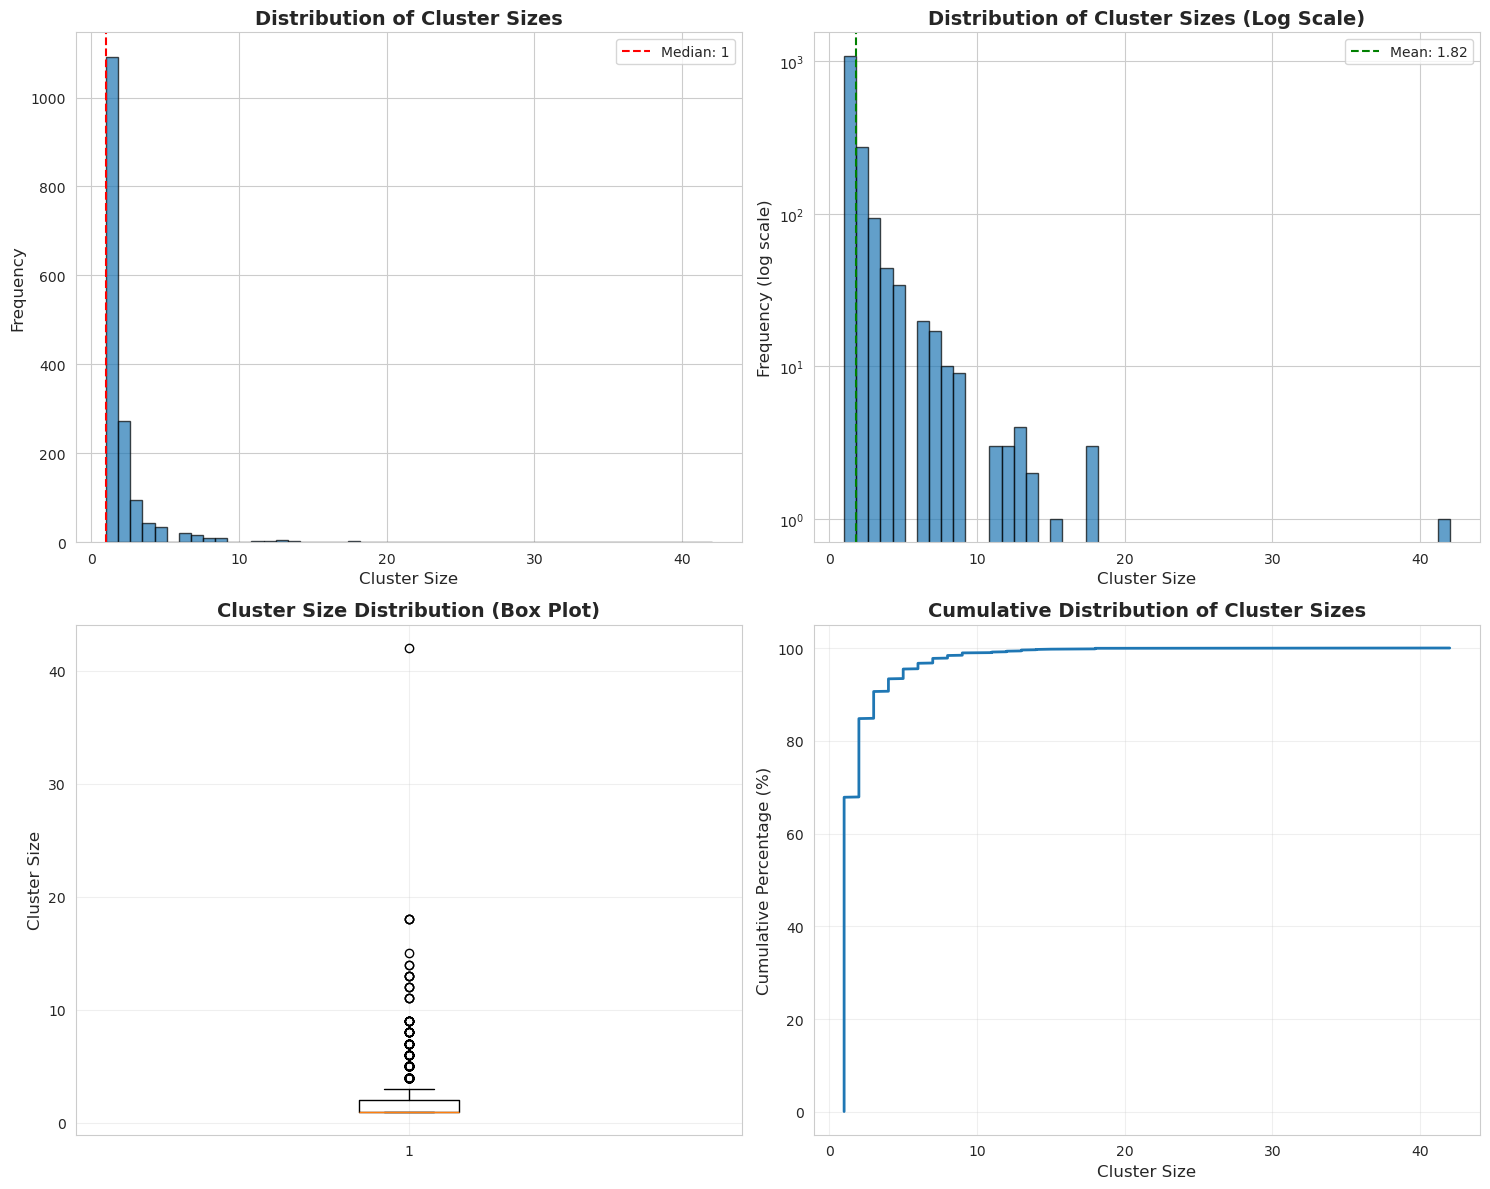

✅ Saved: /scratch/yunmin/data/graph/train/sequence_length_distribution.png


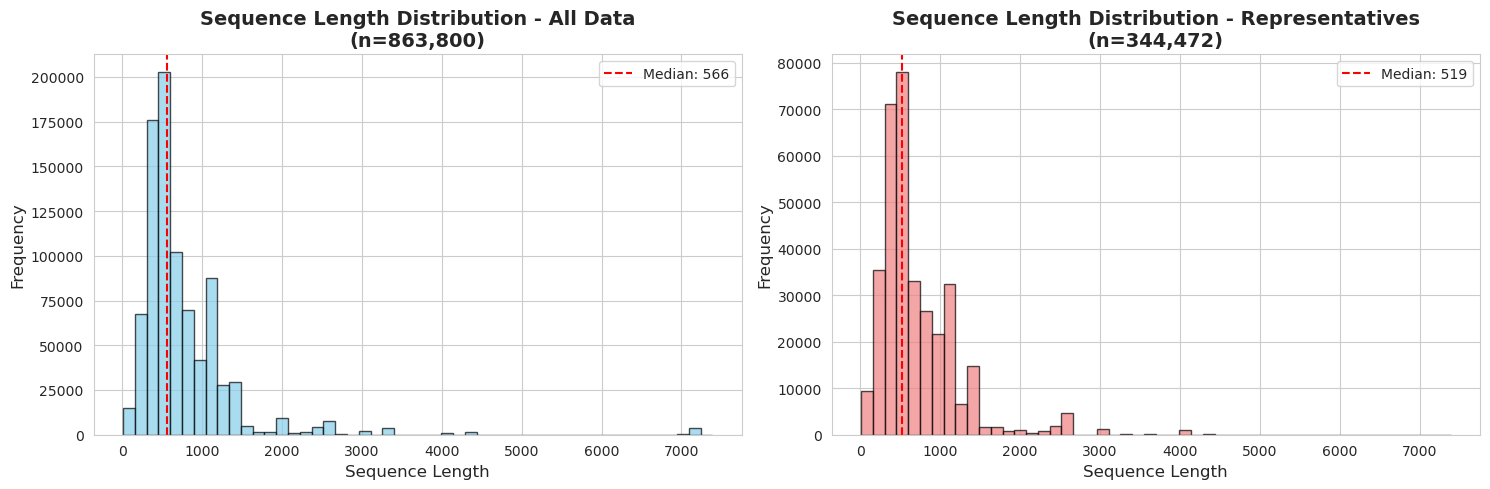

✅ Saved: /scratch/yunmin/data/graph/train/binding_affinity_distribution.png


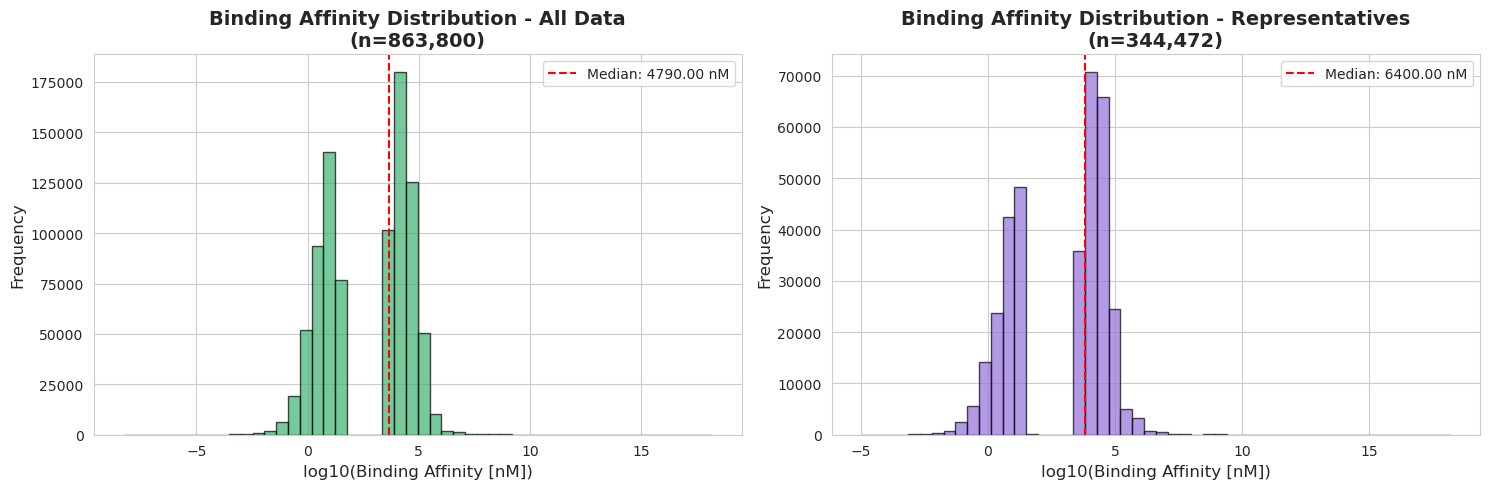

✅ Saved: /scratch/yunmin/data/graph/train/data_source_composition.png


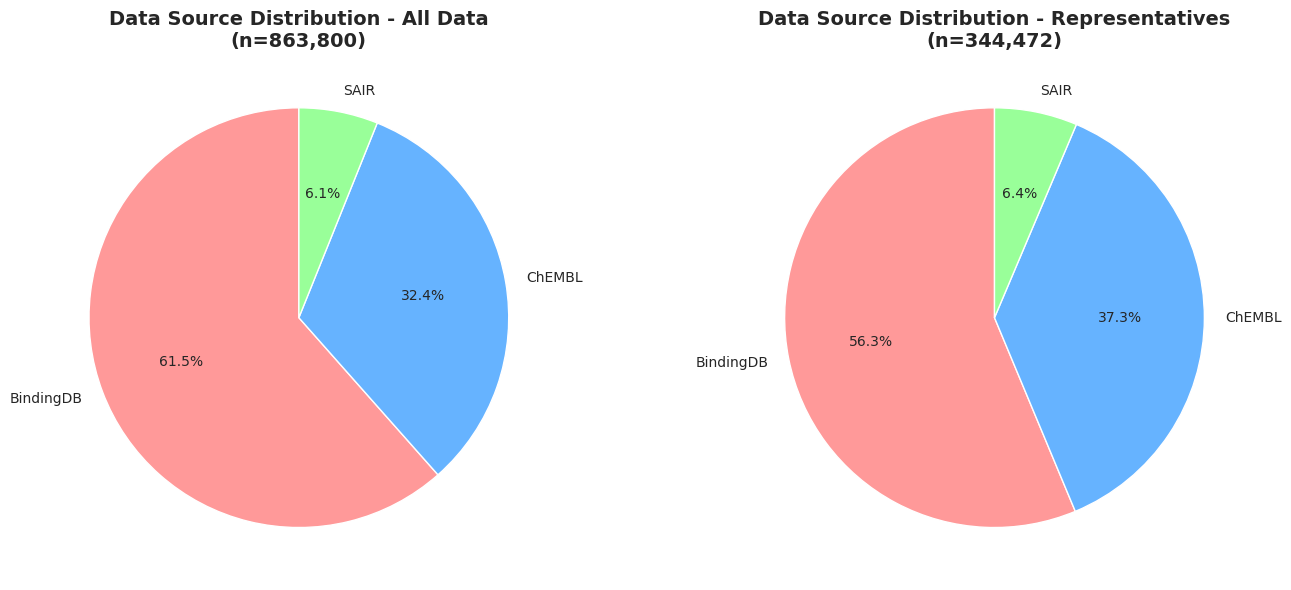

✅ Saved: /scratch/yunmin/data/graph/train/target_type_distribution.png


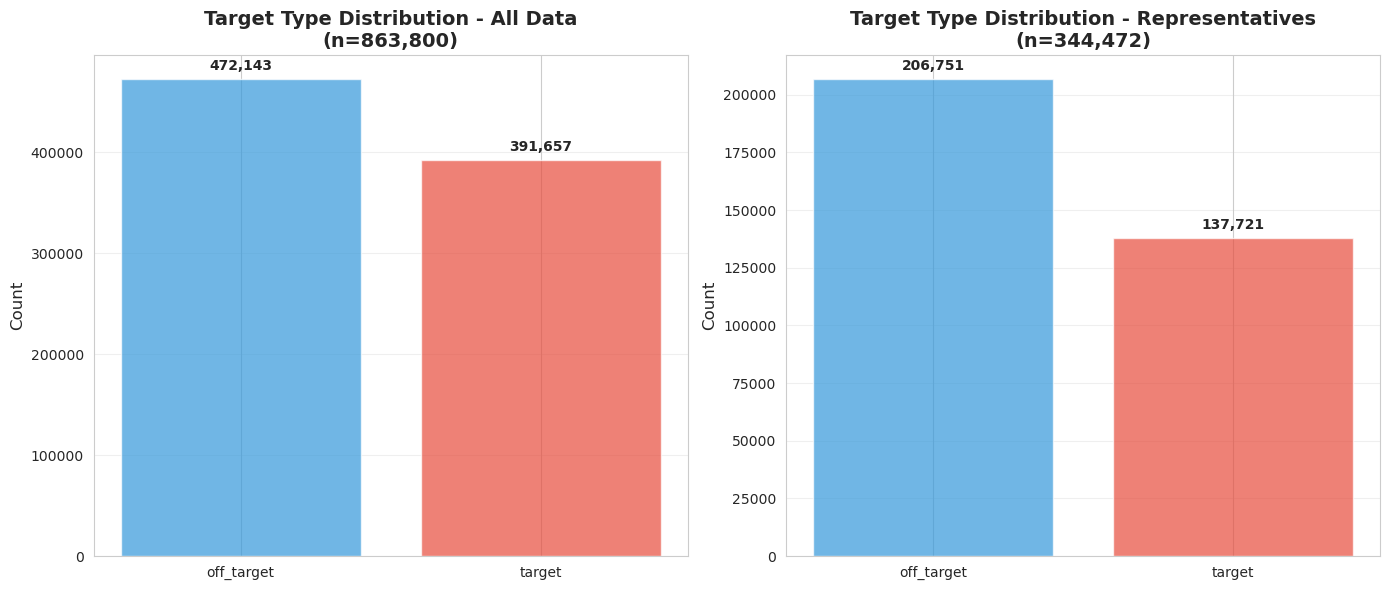

✅ Saved: /scratch/yunmin/data/graph/train/clustering_summary.png


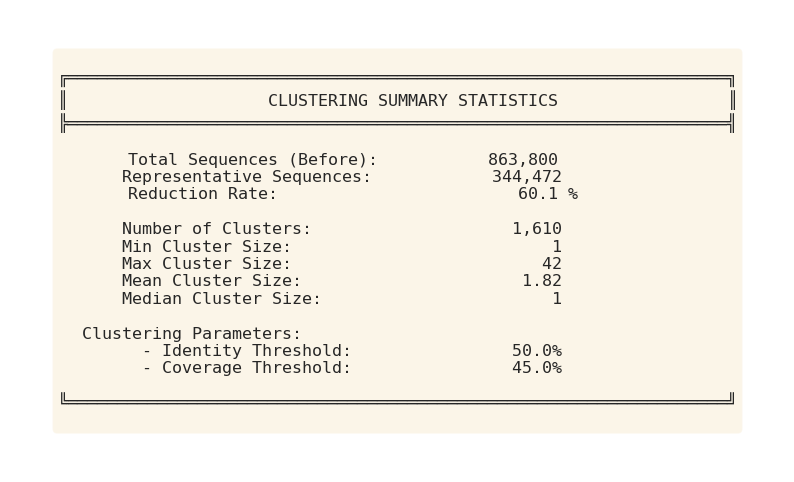


All visualizations complete!


In [25]:
# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

print("\n" + "=" * 80)
print("STEP 10: Visualizing clustering results")
print("=" * 80)

# 1. Cluster Size Distribution
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Histogram of cluster sizes
axes[0, 0].hist(cluster_sizes, bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Cluster Size', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[0, 0].set_title('Distribution of Cluster Sizes', fontsize=14, fontweight='bold')
axes[0, 0].axvline(np.median(cluster_sizes), color='red', linestyle='--', 
                   label=f'Median: {np.median(cluster_sizes):.0f}')
axes[0, 0].legend()

# Log-scale histogram for better visualization
axes[0, 1].hist(cluster_sizes, bins=50, edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Cluster Size', fontsize=12)
axes[0, 1].set_ylabel('Frequency (log scale)', fontsize=12)
axes[0, 1].set_title('Distribution of Cluster Sizes (Log Scale)', fontsize=14, fontweight='bold')
axes[0, 1].set_yscale('log')
axes[0, 1].axvline(np.mean(cluster_sizes), color='green', linestyle='--', 
                   label=f'Mean: {np.mean(cluster_sizes):.2f}')
axes[0, 1].legend()

# Box plot of cluster sizes
axes[1, 0].boxplot(cluster_sizes, vert=True)
axes[1, 0].set_ylabel('Cluster Size', fontsize=12)
axes[1, 0].set_title('Cluster Size Distribution (Box Plot)', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Cumulative distribution
sorted_sizes = np.sort(cluster_sizes)
cumulative = np.arange(1, len(sorted_sizes) + 1) / len(sorted_sizes) * 100
axes[1, 1].plot(sorted_sizes, cumulative, linewidth=2)
axes[1, 1].set_xlabel('Cluster Size', fontsize=12)
axes[1, 1].set_ylabel('Cumulative Percentage (%)', fontsize=12)
axes[1, 1].set_title('Cumulative Distribution of Cluster Sizes', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/scratch/yunmin/data/graph/train/cluster_size_distribution.png', dpi=300, bbox_inches='tight')
print("✅ Saved: /scratch/yunmin/data/graph/train/cluster_size_distribution.png")
plt.show()

# 2. Sequence Length Distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Before clustering
axes[0].hist(total_df_dedup['sequence_length'], bins=50, edgecolor='black', alpha=0.7, color='skyblue')
axes[0].set_xlabel('Sequence Length', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title(f'Sequence Length Distribution - All Data\n(n={len(total_df_dedup):,})', 
                  fontsize=14, fontweight='bold')
axes[0].axvline(total_df_dedup['sequence_length'].median(), color='red', linestyle='--', 
               label=f"Median: {total_df_dedup['sequence_length'].median():.0f}")
axes[0].legend()

# After clustering (representatives)
axes[1].hist(representative_df['sequence_length'], bins=50, edgecolor='black', alpha=0.7, color='lightcoral')
axes[1].set_xlabel('Sequence Length', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title(f'Sequence Length Distribution - Representatives\n(n={len(representative_df):,})', 
                  fontsize=14, fontweight='bold')
axes[1].axvline(representative_df['sequence_length'].median(), color='red', linestyle='--', 
               label=f"Median: {representative_df['sequence_length'].median():.0f}")
axes[1].legend()

plt.tight_layout()
plt.savefig('/scratch/yunmin/data/graph/train/sequence_length_distribution.png', dpi=300, bbox_inches='tight')
print("✅ Saved: /scratch/yunmin/data/graph/train/sequence_length_distribution.png")
plt.show()

# 3. Binding Affinity Distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Before clustering (log scale)
valid_assay_all = total_df_dedup[total_df_dedup['representative_assay_nM'].notna()]['representative_assay_nM']
axes[0].hist(np.log10(valid_assay_all), bins=50, edgecolor='black', alpha=0.7, color='mediumseagreen')
axes[0].set_xlabel('log10(Binding Affinity [nM])', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title(f'Binding Affinity Distribution - All Data\n(n={len(valid_assay_all):,})', 
                  fontsize=14, fontweight='bold')
axes[0].axvline(np.log10(valid_assay_all.median()), color='red', linestyle='--', 
               label=f"Median: {valid_assay_all.median():.2f} nM")
axes[0].legend()

# After clustering (representatives)
valid_assay_rep = representative_df[representative_df['representative_assay_nM'].notna()]['representative_assay_nM']
axes[1].hist(np.log10(valid_assay_rep), bins=50, edgecolor='black', alpha=0.7, color='mediumpurple')
axes[1].set_xlabel('log10(Binding Affinity [nM])', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title(f'Binding Affinity Distribution - Representatives\n(n={len(valid_assay_rep):,})', 
                  fontsize=14, fontweight='bold')
axes[1].axvline(np.log10(valid_assay_rep.median()), color='red', linestyle='--', 
               label=f"Median: {valid_assay_rep.median():.2f} nM")
axes[1].legend()

plt.tight_layout()
plt.savefig('/scratch/yunmin/data/graph/train/binding_affinity_distribution.png', dpi=300, bbox_inches='tight')
print("✅ Saved: /scratch/yunmin/data/graph/train/binding_affinity_distribution.png")
plt.show()

# 4. Data Source Composition
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Before clustering
source_counts_all = total_df_dedup['data_source'].value_counts()
axes[0].pie(source_counts_all, labels=source_counts_all.index, autopct='%1.1f%%', 
           startangle=90, colors=['#ff9999', '#66b3ff', '#99ff99'])
axes[0].set_title(f'Data Source Distribution - All Data\n(n={len(total_df_dedup):,})', 
                 fontsize=14, fontweight='bold')

# After clustering
source_counts_rep = representative_df['data_source'].value_counts()
axes[1].pie(source_counts_rep, labels=source_counts_rep.index, autopct='%1.1f%%', 
           startangle=90, colors=['#ff9999', '#66b3ff', '#99ff99'])
axes[1].set_title(f'Data Source Distribution - Representatives\n(n={len(representative_df):,})', 
                 fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('/scratch/yunmin/data/graph/train/data_source_composition.png', dpi=300, bbox_inches='tight')
print("✅ Saved: /scratch/yunmin/data/graph/train/data_source_composition.png")
plt.show()

# 5. Target Type Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Before clustering
target_counts_all = total_df_dedup['target_type'].value_counts()
axes[0].bar(target_counts_all.index, target_counts_all.values, color=['#3498db', '#e74c3c'], alpha=0.7)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title(f'Target Type Distribution - All Data\n(n={len(total_df_dedup):,})', 
                 fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(target_counts_all.values):
    axes[0].text(i, v + max(target_counts_all.values)*0.02, f'{v:,}', ha='center', fontweight='bold')

# After clustering
target_counts_rep = representative_df['target_type'].value_counts()
axes[1].bar(target_counts_rep.index, target_counts_rep.values, color=['#3498db', '#e74c3c'], alpha=0.7)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title(f'Target Type Distribution - Representatives\n(n={len(representative_df):,})', 
                 fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(target_counts_rep.values):
    axes[1].text(i, v + max(target_counts_rep.values)*0.02, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('/scratch/yunmin/data/graph/train/target_type_distribution.png', dpi=300, bbox_inches='tight')
print("✅ Saved: /scratch/yunmin/data/graph/train/target_type_distribution.png")
plt.show()

# 6. Summary Statistics
fig, ax = plt.subplots(figsize=(10, 6))
ax.axis('off')
min_seq_id = 0.5
coverage = 0.45

summary_text = f"""
╔══════════════════════════════════════════════════════════════════╗
║                    CLUSTERING SUMMARY STATISTICS                 ║
╠══════════════════════════════════════════════════════════════════╣
                                                                   
  Total Sequences (Before):        {len(total_df_dedup):>10,}             
  Representative Sequences:         {len(representative_df):>10,}             
  Reduction Rate:                   {(1 - len(representative_df)/len(total_df_dedup))*100:>9.1f} %           
                                                                   
  Number of Clusters:               {len(clusters):>10,}             
  Min Cluster Size:                 {min(cluster_sizes):>10}             
  Max Cluster Size:                 {max(cluster_sizes):>10}             
  Mean Cluster Size:                {np.mean(cluster_sizes):>10.2f}             
  Median Cluster Size:              {np.median(cluster_sizes):>10.0f}             
                                                                   
  Clustering Parameters:                                           
    - Identity Threshold:           {min_seq_id:>10.1%}             
    - Coverage Threshold:           {coverage:>10.1%}             
                                                                   
╚══════════════════════════════════════════════════════════════════╝
"""

ax.text(0.5, 0.5, summary_text, fontsize=12, family='monospace',
        ha='center', va='center', transform=ax.transAxes,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.savefig('/scratch/yunmin/data/graph/train/clustering_summary.png', dpi=300, bbox_inches='tight')
print("✅ Saved: /scratch/yunmin/data/graph/train/clustering_summary.png")
plt.show()

print("\n" + "=" * 80)
print("All visualizations complete!")
print("=" * 80)

## # of Ligands per protein filtering

In [31]:
print(len(unique_proteins), "unique proteins after clustering:")
unique_proteins.head()

2926 unique proteins after clustering:


,uniprot_id,sequence,sequence_length,mmseqs_id,mmseqs_key,cluster_id
0,C7C422,MELPNIMHPVAKLSTALAAALMLSGCMPGEIRPTIGQQMETGDQRF...,270,0,seq_00000000,0
1,O00238,MLLRSAGKLNVGTKKEDGESTAPTPRPKVLRCKCHHHCPEDSVNNI...,502,1,seq_00000001,1091
2,O00255,MGLKAAQKTLFPLRSIDDVVRLFAAELGREEPDLVLLSLVLGFVEH...,615,2,seq_00000002,193
3,O00329,MPPGVDCPMEFWTKEENQSVVVDFLLPTGVYLNFPVSRNANLSTIK...,1044,3,seq_00000003,1086
4,O00444,MATCIGEKIEDFKVGNLLGKGSFAGVYRAESIHTGLEVAIKMIDKK...,970,4,seq_00000004,1335


In [ ]:
# ========================================================================
# Flexible filtering by off-target count threshold
# ========================================================================

def filter_by_offtarget_count(df, min_offtargets=100, min_targets=1):
    """
    Filter proteins with minimum off-targets and optionally minimum targets
    
    Args:
        df: total_df_dedup DataFrame
        min_offtargets: minimum number of off-target ligands
        min_targets: minimum number of target ligands (optional)
    """
    
    # Count off-targets per protein
    off_targets = df[
        df['target_type'] == 'off_target'
    ].groupby(['uniprot_id', 'sequence']).size().reset_index(name='n_off_targets')
    
    # Count targets per protein (optional)
    targets = df[
        df['target_type'] == 'target'
    ].groupby(['uniprot_id', 'sequence']).size().reset_index(name='n_targets')
    
    # Merge
    protein_counts = off_targets.merge(
        targets, 
        on=['uniprot_id', 'sequence'],
        how='left'
    ).fillna(0)
    
    # Filter
    filtered_proteins = protein_counts[
        (protein_counts['n_off_targets'] >= min_offtargets) &
        (protein_counts['n_targets'] >= min_targets)
    ]
    
    # Create protein ID set
    protein_ids_set = set(
        zip(filtered_proteins['uniprot_id'], filtered_proteins['sequence'])
    )
    
    # Filter dataframe
    filtered_df = df[
        df.apply(
            lambda row: (row['uniprot_id'], row['sequence']) in protein_ids_set,
            axis=1
        )
    ].copy()
    
    return filtered_df, filtered_proteins

# Test different thresholds
print("=" * 80)
print("EXPLORING DIFFERENT OFF-TARGET THRESHOLDS")
print("=" * 80)

total_df_dedup_copy = total_df_dedup.copy()
print(f"Total proteins: {total_df_dedup_copy[['uniprot_id', 'sequence']].drop_duplicates().shape[0]:,}")

off_thresholds = [20, 50, 100, 150]
tar_thresholds = [1, 3, 5, 10, 20]

for tar_threshold in tar_thresholds:
    for off_threshold in off_thresholds:
        filtered_df, filtered_proteins = filter_by_offtarget_count(
            total_df_dedup_copy, 
            min_offtargets=off_threshold,
            min_targets=tar_threshold,
        )
        
        n_proteins = len(filtered_proteins)
        n_pairs = len(filtered_df)
        n_off = (filtered_df['target_type'] == 'off_target').sum()
        n_target = (filtered_df['target_type'] == 'target').sum()
        
        print(f"\n🔹 Threshold: >{off_threshold} off-targets / >{tar_threshold} targets")
        print(f"   Proteins: {n_proteins:,}")
        print(f"   Pairs: {n_pairs:,}")
        print(f"   Off-targets: {n_off:,}")
        print(f"   Targets: {n_target:,}")
        print(f"   Ratio: {n_off/n_target:.2f} off-targets per target")

EXPLORING DIFFERENT OFF-TARGET THRESHOLDS
Total proteins: 2,926

🔹 Threshold: >20 off-targets / >1 targets
   Proteins: 1,456
   Pairs: 812,247
   Off-targets: 452,989
   Targets: 359,258
   Ratio: 1.26 off-targets per target

🔹 Threshold: >50 off-targets / >1 targets
   Proteins: 1,137
   Pairs: 786,963
   Off-targets: 442,861
   Targets: 344,102
   Ratio: 1.29 off-targets per target

🔹 Threshold: >100 off-targets / >1 targets
   Proteins: 852
   Pairs: 744,875
   Off-targets: 422,481
   Targets: 322,394
   Ratio: 1.31 off-targets per target

🔹 Threshold: >150 off-targets / >1 targets
   Proteins: 697
   Pairs: 701,952
   Off-targets: 403,463
   Targets: 298,489
   Ratio: 1.35 off-targets per target

🔹 Threshold: >20 off-targets / >3 targets
   Proteins: 1,263
   Pairs: 789,272
   Off-targets: 430,286
   Targets: 358,986
   Ratio: 1.20 off-targets per target

🔹 Threshold: >50 off-targets / >3 targets
   Proteins: 1,019
   Pairs: 766,313
   Off-targets: 422,373
   Targets: 343,940
   R

In [71]:
# ========================================================================
# Filter proteins with >100 off-targets
# ========================================================================

print("=" * 80)
print("EXTRACTING PROTEINS WITH >100 OFF-TARGETS")
print("=" * 80)

# Count off-targets per protein
def count_ligands_per_protein(df, target_type):
    target_type = str(target_type)

    ligands_per_protein = (df[
        df['target_type'] == target_type
    ].groupby(['uniprot_id', 'sequence']).size().reset_index(name=f'n_{target_type}s'))

    print(f"\n📊 {target_type} distribution across proteins:")
    print(f"   Mean: {ligands_per_protein[f'n_{target_type}s'].mean():.1f}")
    print(f"   Median: {ligands_per_protein[f'n_{target_type}s'].median():.1f}")
    print(f"   Max: {ligands_per_protein[f'n_{target_type}s'].max()}")
    print(f"   Min: {ligands_per_protein[f'n_{target_type}s'].min()}")
    return ligands_per_protein

off_targets_per_protein = count_ligands_per_protein(
    total_df_dedup_copy, 
    target_type='off_target'
)

targets_per_protein = count_ligands_per_protein(
    total_df_dedup_copy, 
    target_type='target'
)

protein_counts = (
    off_targets_per_protein.merge(targets_per_protein, on=["uniprot_id", "sequence"], how="left")
)
protein_counts["n_targets"] = protein_counts["n_targets"].fillna(0).astype(int)

# Filter proteins with ≥100 off-targets AND ≥20 target
proteins_morethan_off = protein_counts[
    (protein_counts["n_off_targets"] >= 100) & (protein_counts["n_targets"] >= 20)
]

print(f"\n✅ Found {len(proteins_morethan_off):,} proteins with ≥100 off-targets AND ≥20 target")
print(f"   Total off-target pairs: {proteins_morethan_off['n_off_targets'].sum():,}")

# Extract total_df_dedup_copy for these proteins
protein_ids_set = set(
    zip(proteins_morethan_off['uniprot_id'], 
        proteins_morethan_off['sequence'])
)

total_df_dedup_copy_100plus = total_df_dedup_copy.merge(
    proteins_morethan_off[["uniprot_id", "sequence"]],
    on=["uniprot_id", "sequence"],
    how="inner"
).copy()

print(f"\n📊 Filtered dataset statistics:")
print(f"   Original pairs: {len(total_df_dedup_copy):,}")
print(f"   Filtered pairs: {len(total_df_dedup_copy_100plus):,}")
print(f"   Reduction: {(1 - len(total_df_dedup_copy_100plus)/len(total_df_dedup_copy))*100:.1f}%")

# Breakdown by target type
n_target = (total_df_dedup_copy_100plus['target_type'] == 'target').sum()
n_off = (total_df_dedup_copy_100plus['target_type'] == 'off_target').sum()
total = n_target + n_off

print(f"\n   Targets: {n_target:,} ({n_target/total*100:.1f}%)")
print(f"   Off-targets: {n_off:,} ({n_off/total*100:.1f}%)")

# Unique proteins
unique_proteins_100plus = total_df_dedup_copy_100plus[
    ['uniprot_id', 'sequence']
].drop_duplicates()

print(f"\n   Unique proteins: {len(unique_proteins_100plus):,}")
print(f"   Unique ligands: {total_df_dedup_copy_100plus['ligand_smiles'].nunique():,}")
print(f"   Avg off-targets/protein: {n_off / len(unique_proteins_100plus):.1f}")

print("\n" + "=" * 80)

EXTRACTING PROTEINS WITH >100 OFF-TARGETS

📊 off_target distribution across proteins:
   Mean: 197.9
   Median: 47.0
   Max: 10582
   Min: 1

📊 target distribution across proteins:
   Mean: 163.2
   Median: 15.0
   Max: 7083
   Min: 1

✅ Found 624 proteins with ≥100 off-targets AND ≥20 target
   Total off-target pairs: 360,304

📊 Filtered dataset statistics:
   Original pairs: 863,800
   Filtered pairs: 681,083
   Reduction: 21.2%

   Targets: 320,779 (47.1%)
   Off-targets: 360,304 (52.9%)

   Unique proteins: 624
   Unique ligands: 501,188
   Avg off-targets/protein: 577.4



In [72]:
# ========================================================================
# Save filtered dataset
# ========================================================================

output_dir = "/scratch/yunmin/data/graph/train"

total_df_dedup_copy_100plus.to_csv(
    f"{output_dir}/representative_sequences_100plus_offtargets.csv", 
    index=False
)

print(f"✅ Saved: {output_dir}/representative_sequences_100plus_offtargets.csv")

# Also save protein list
proteins_morethan_off.to_csv(
    f"{output_dir}/proteins_100plus_offtargets.csv",
    index=False
)

print(f"✅ Saved: {output_dir}/proteins_100plus_offtargets.csv")

✅ Saved: /scratch/yunmin/data/graph/train/representative_sequences_100plus_offtargets.csv
✅ Saved: /scratch/yunmin/data/graph/train/proteins_100plus_offtargets.csv


✅ Saved: /scratch/yunmin/data/graph/train/offtargets_distribution.png


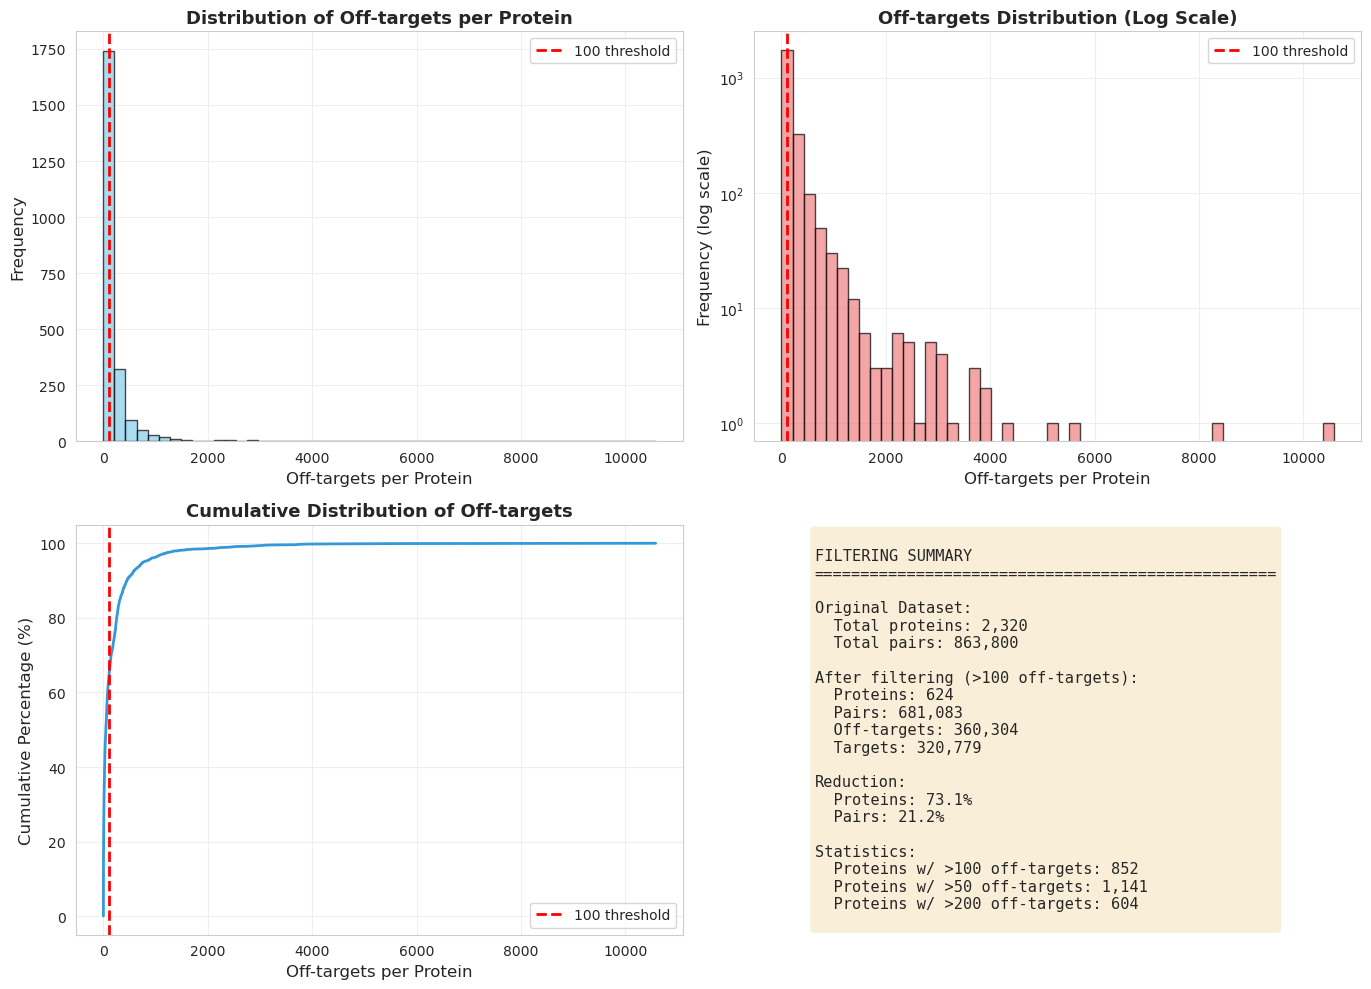

In [73]:
# ========================================================================
# Visualize off-target distribution
# ========================================================================

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Histogram of off-targets per protein
axes[0, 0].hist(off_targets_per_protein['n_off_targets'], bins=50, 
                edgecolor='black', alpha=0.7, color='skyblue')
axes[0, 0].axvline(100, color='red', linestyle='--', linewidth=2, label='100 threshold')
axes[0, 0].set_xlabel('Off-targets per Protein', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[0, 0].set_title('Distribution of Off-targets per Protein', fontsize=13, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Log scale histogram
axes[0, 1].hist(off_targets_per_protein['n_off_targets'], bins=50, 
                edgecolor='black', alpha=0.7, color='lightcoral')
axes[0, 1].axvline(100, color='red', linestyle='--', linewidth=2, label='100 threshold')
axes[0, 1].set_xlabel('Off-targets per Protein', fontsize=12)
axes[0, 1].set_ylabel('Frequency (log scale)', fontsize=12)
axes[0, 1].set_yscale('log')
axes[0, 1].set_title('Off-targets Distribution (Log Scale)', fontsize=13, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Cumulative distribution
sorted_offtargets = np.sort(off_targets_per_protein['n_off_targets'])
cumulative = np.arange(1, len(sorted_offtargets) + 1) / len(sorted_offtargets) * 100
axes[1, 0].plot(sorted_offtargets, cumulative, linewidth=2, color='#3498db')
axes[1, 0].axvline(100, color='red', linestyle='--', linewidth=2, label='100 threshold')
axes[1, 0].set_xlabel('Off-targets per Protein', fontsize=12)
axes[1, 0].set_ylabel('Cumulative Percentage (%)', fontsize=12)
axes[1, 0].set_title('Cumulative Distribution of Off-targets', fontsize=13, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Summary statistics
axes[1, 1].axis('off')

summary_text = f"""
FILTERING SUMMARY
{'='*50}

Original Dataset:
  Total proteins: {len(off_targets_per_protein):,}
  Total pairs: {len(total_df_dedup_copy):,}

After filtering (>100 off-targets):
  Proteins: {len(proteins_morethan_off):,}
  Pairs: {len(total_df_dedup_copy_100plus):,}
  Off-targets: {(total_df_dedup_copy_100plus['target_type'] == 'off_target').sum():,}
  Targets: {(total_df_dedup_copy_100plus['target_type'] == 'target').sum():,}

Reduction:
  Proteins: {(1 - len(proteins_morethan_off)/len(off_targets_per_protein))*100:.1f}%
  Pairs: {(1 - len(total_df_dedup_copy_100plus)/len(total_df_dedup_copy))*100:.1f}%

Statistics:
  Proteins w/ >100 off-targets: {(off_targets_per_protein['n_off_targets'] > 100).sum():,}
  Proteins w/ >50 off-targets: {(off_targets_per_protein['n_off_targets'] > 50).sum():,}
  Proteins w/ >200 off-targets: {(off_targets_per_protein['n_off_targets'] > 200).sum():,}
"""

axes[1, 1].text(0.1, 0.5, summary_text, fontsize=11, family='monospace',
                verticalalignment='center', transform=axes[1, 1].transAxes,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig(f"{output_dir}/offtargets_distribution.png", dpi=300, bbox_inches='tight')
print("✅ Saved: /scratch/yunmin/data/graph/train/offtargets_distribution.png")
plt.show()

## Ligand Diversity Clustering

Separately done in `/home/yunmin/proj/LigandMPNN/dataprep/off_cluster.py`

### Configuration

In [74]:
print("\n" + "=" * 80)
print("LIGAND SIMILARITY CLUSTERING AND DIFFICULTY BUCKETING")
print("=" * 80)

from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors, Lipinski, rdMolDescriptors
from rdkit.Chem import DataStructs
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
from rdkit.Chem.Scaffolds import MurckoScaffold
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')


LIGAND SIMILARITY CLUSTERING AND DIFFICULTY BUCKETING


### Compute molecular features and fingerprints

In [75]:
print("\n1️⃣ Computing molecular features and fingerprints...")

def compute_mol_features(smiles):
    """Compute physicochemical properties and fingerprints"""
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None
        
        # Physicochemical properties
        features = {
            'MW': Descriptors.MolWt(mol),
            'cLogP': Descriptors.MolLogP(mol),
            'TPSA': Descriptors.TPSA(mol),
            'HBD': Descriptors.NumHDonors(mol),
            'HBA': Descriptors.NumHAcceptors(mol),
            'RotBonds': Descriptors.NumRotatableBonds(mol),
            'Charge': Chem.GetFormalCharge(mol),
            # Additional features
            'NumRings': Descriptors.RingCount(mol),
            'NumAromaticRings': Descriptors.NumAromaticRings(mol),
        }
        
        # ECFP4 fingerprint (Morgan fingerprint, radius=2)
        gen = GetMorganGenerator(radius=2, fpSize=2048)
        fp_ecfp4 = gen.GetFingerprint(mol)
        
        # MACCS keys
        fp_maccs = AllChem.GetMACCSKeysFingerprint(mol)
        
        # Scaffold
        try:
            scaffold = MurckoScaffold.GetScaffoldForMol(mol)
            scaffold_smiles = Chem.MolToSmiles(scaffold)
        except:
            scaffold_smiles = None
        
        return {
            'mol': mol,
            'features': features,
            'fp_ecfp4': fp_ecfp4,
            'fp_maccs': fp_maccs,
            'scaffold': scaffold_smiles
        }
    except Exception as e:
        print(f"Error processing {smiles}: {e}")
        return None

# Load filtered dataset (>100 off-targets, >20 targets)
print(f"\nProcessing dataset: {len(total_df_dedup_copy_100plus):,} protein-ligand pairs")

# Compute features for all ligands
print("Computing molecular features for all ligands...")
ligand_data = {}

unique_smiles = total_df_dedup_copy_100plus['ligand_smiles'].unique()
print(f"  Total unique ligands: {len(unique_smiles):,}")

for i, smiles in enumerate(unique_smiles):
    if (i + 1) % 1000 == 0:
        print(f"  Processed {i+1:,}/{len(unique_smiles):,} ligands...")
    
    mol_data = compute_mol_features(smiles)
    if mol_data:
        ligand_data[smiles] = mol_data

print(f"✅ Successfully processed {len(ligand_data):,}/{len(unique_smiles):,} ligands")

# Add features to dataframe
total_df_dedup_copy_100plus['mol_valid'] = total_df_dedup_copy_100plus['ligand_smiles'].isin(ligand_data.keys())
print(f"  Valid molecules: {total_df_dedup_copy_100plus['mol_valid'].sum():,}")
# took about 5m


1️⃣ Computing molecular features and fingerprints...

Processing dataset: 681,083 protein-ligand pairs
Computing molecular features for all ligands...
  Total unique ligands: 501,188
  Processed 1,000/501,188 ligands...
  Processed 2,000/501,188 ligands...
  Processed 3,000/501,188 ligands...
  Processed 4,000/501,188 ligands...
  Processed 5,000/501,188 ligands...
  Processed 6,000/501,188 ligands...
  Processed 7,000/501,188 ligands...
  Processed 8,000/501,188 ligands...
  Processed 9,000/501,188 ligands...
  Processed 10,000/501,188 ligands...
  Processed 11,000/501,188 ligands...


[18:05:18] Explicit valence for atom # 24 N, 4, is greater than permitted
[18:05:18] Explicit valence for atom # 24 N, 4, is greater than permitted


  Processed 12,000/501,188 ligands...
  Processed 13,000/501,188 ligands...
  Processed 14,000/501,188 ligands...
  Processed 15,000/501,188 ligands...
  Processed 16,000/501,188 ligands...
  Processed 17,000/501,188 ligands...
  Processed 18,000/501,188 ligands...
  Processed 19,000/501,188 ligands...


[18:05:29] Explicit valence for atom # 20 H, 2, is greater than permitted


  Processed 20,000/501,188 ligands...
  Processed 21,000/501,188 ligands...
  Processed 22,000/501,188 ligands...
  Processed 23,000/501,188 ligands...
  Processed 24,000/501,188 ligands...
  Processed 25,000/501,188 ligands...
  Processed 26,000/501,188 ligands...


...

  Processed 319,000/501,188 ligands...


[18:12:07] Explicit valence for atom # 19 N, 4, is greater than permitted


  Processed 320,000/501,188 ligands...
  Processed 321,000/501,188 ligands...
  Processed 322,000/501,188 ligands...
  Processed 323,000/501,188 ligands...
  Processed 324,000/501,188 ligands...


[18:12:19] Explicit valence for atom # 1 N, 4, is greater than permitted


  Processed 325,000/501,188 ligands...
  Processed 326,000/501,188 ligands...
  Processed 327,000/501,188 ligands...
  Processed 328,000/501,188 ligands...
  Processed 329,000/501,188 ligands...
  Processed 330,000/501,188 ligands...
  Processed 331,000/501,188 ligands...
  Processed 332,000/501,188 ligands...
  Processed 333,000/501,188 ligands...
  Processed 334,000/501,188 ligands...
  Processed 335,000/501,188 ligands...
  Processed 336,000/501,188 ligands...
  Processed 337,000/501,188 ligands...
  Processed 338,000/501,188 ligands...
  Processed 339,000/501,188 ligands...
  Processed 340,000/501,188 ligands...
  Processed 341,000/501,188 ligands...
  Processed 342,000/501,188 ligands...
  Processed 343,000/501,188 ligands...
  Processed 344,000/501,188 ligands...
  Processed 345,000/501,188 ligands...
  Processed 346,000/501,188 ligands...
  Processed 347,000/501,188 ligands...
  Processed 348,000/501,188 ligands...
  Processed 349,000/501,188 ligands...
  Processed 350,000/501,1

### Compute similarity scores

In [56]:
def compute_tanimoto_similarity(fp1, fp2):
    """Compute Tanimoto similarity between two fingerprints"""
    return DataStructs.TanimotoSimilarity(fp1, fp2)

def compute_scaffold_similarity(scaffold1, scaffold2):
    """Binary scaffold match (1 if same, 0 if different)"""
    if scaffold1 is None or scaffold2 is None:
        return 0.0
    return 1.0 if scaffold1 == scaffold2 else 0.0

def compute_physicochemical_similarity(features1, features2):
    """Compute normalized euclidean distance between physicochemical properties"""
    # Extract feature vectors
    keys = ['MW', 'cLogP', 'TPSA', 'HBD', 'HBA', 'RotBonds', 'Charge', 'NumRings', 'NumAromaticRings']
    vec1 = np.array([features1[k] for k in keys])
    vec2 = np.array([features2[k] for k in keys])
    
    # Normalize using StandardScaler (fit on both vectors)
    scaler = StandardScaler()
    vecs = np.vstack([vec1, vec2])
    vecs_scaled = scaler.fit_transform(vecs)
    
    # Compute Euclidean distance
    distance = np.linalg.norm(vecs_scaled[0] - vecs_scaled[1])
    
    # Convert to similarity (inverse exponential decay)
    similarity = np.exp(-distance)
    return similarity

In [ ]:
# Process each protein-target pair
print("\n2️⃣ Computing similarities for each protein-target pair...")

protein_target_scores = []

# Get unique proteins
unique_proteins_100plus = total_df_dedup_copy_100plus[
    ['uniprot_id', 'sequence', 'cluster_id']
].drop_duplicates()

print(f"Processing {len(unique_proteins_100plus):,} unique proteins...")

for protein_idx, protein_row in tqdm(unique_proteins_100plus.iterrows(), 
                                     total=len(unique_proteins_100plus),
                                     desc="Processing proteins"):
    uniprot_id = protein_row['uniprot_id']
    sequence = protein_row['sequence']
    cluster_id = protein_row['cluster_id']
    
    # Get all ligands for this protein
    protein_df = total_df_dedup_copy_100plus[
        (total_df_dedup_copy_100plus['uniprot_id'] == uniprot_id) &
        (total_df_dedup_copy_100plus['sequence'] == sequence) &
        (total_df_dedup_copy_100plus['mol_valid'] == True)
    ].copy()
    
    # Get target and off-target ligands
    target_df = protein_df[protein_df['target_type'] == 'target']
    off_target_df = protein_df[protein_df['target_type'] == 'off_target']
    
    if len(target_df) == 0 or len(off_target_df) == 0:
        continue
    
    # Get unique target ligands
    target_smiles_list = target_df['ligand_smiles'].unique()
    
    # For EACH target ligand, compute similarity of ALL off-targets to it
    for target_smiles in target_smiles_list:
        target_data = ligand_data[target_smiles]
        
        # Store similarities for this specific target
        target_off_target_scores = []
        
        for _, off_row in off_target_df.iterrows():
            off_smiles = off_row['ligand_smiles']
            off_data = ligand_data[off_smiles]
            
            # Skip if off-target is same as target
            if off_smiles == target_smiles:
                continue
            
            # 1. 2D Structural similarity (ECFP4 Tanimoto)
            sim_2d = compute_tanimoto_similarity(
                off_data['fp_ecfp4'], 
                target_data['fp_ecfp4']
            )
            
            # 2. Scaffold similarity (Murcko)
            sim_scaffold = compute_scaffold_similarity(
                off_data['scaffold'],
                target_data['scaffold']
            )
            
            # 3. Physicochemical similarity
            sim_physchem = compute_physicochemical_similarity(
                off_data['features'],
                target_data['features']
            )
            
            # Compute composite similarity score
            composite_score = (
                0.4 * sim_2d +
                0.3 * sim_scaffold +
                0.3 * sim_physchem
            )
            
            target_off_target_scores.append({
                'uniprot_id': uniprot_id,
                'sequence': sequence,
                'cluster_id': cluster_id,
                'target_smiles': target_smiles,
                'off_target_smiles': off_smiles,
                'similarity_2d': sim_2d,
                'similarity_scaffold': sim_scaffold,
                'similarity_physchem': sim_physchem,
                'similarity_composite': composite_score,
            })
        
        # Add to main list
        protein_target_scores.extend(target_off_target_scores)

# Convert to DataFrame
similarity_df = pd.DataFrame(protein_target_scores)
print(f"\n✅ Computed similarities for {len(similarity_df):,} protein-target-offtarget combinations")
print(f"   Unique proteins: {similarity_df['uniprot_id'].nunique():,}")
print(f"   Unique targets: {similarity_df['target_smiles'].nunique():,}")
print(f"   Unique off-targets: {similarity_df['off_target_smiles'].nunique():,}")


2️⃣ Computing similarities for each protein-target pair...
Processing 263 unique proteins...


Processing proteins:   8%|▊         | 21/263 [18:15<3:30:25, 52.17s/it] 


KeyboardInterrupt: 

### Assign difficulty buckets per protein

In [ ]:
print("\n3️⃣ Assigning difficulty buckets...")

def assign_difficulty_bucket(group):
    """Assign difficulty bucket based on composite similarity"""
    group = group.sort_values('similarity_composite', ascending=True).copy()
    n = len(group)
    
    # Easy: lowest 30% similarity (least similar to target)
    # Medium: middle 40%
    # Hard: top 30% similarity (most similar to target, hardest to discriminate)
    
    easy_cutoff = int(n * 0.30)
    hard_cutoff = int(n * 0.70)
    
    group['difficulty_bucket'] = 'medium'
    group.iloc[:easy_cutoff, group.columns.get_loc('difficulty_bucket')] = 'easy'
    group.iloc[hard_cutoff:, group.columns.get_loc('difficulty_bucket')] = 'hard'
    
    return group

# Group by protein and assign buckets
similarity_df_bucketed = (
    similarity_df
    .groupby(['uniprot_id', 'sequence'], group_keys=False)
    .apply(assign_difficulty_bucket)
    .reset_index(drop=True)
)

print(f"\n📊 Difficulty bucket distribution:")
bucket_counts = similarity_df_bucketed['difficulty_bucket'].value_counts()
for bucket, count in bucket_counts.items():
    print(f"  - {bucket.capitalize()}: {count:,} ({count/len(similarity_df_bucketed)*100:.1f}%)")

# Check per-protein distribution
print(f"\n📊 Per-protein bucket statistics:")
bucket_stats = (
    similarity_df_bucketed
    .groupby(['uniprot_id', 'sequence'])['difficulty_bucket']
    .value_counts()
    .unstack(fill_value=0)
)
print(f"  Mean easy per protein: {bucket_stats['easy'].mean():.1f}")
print(f"  Mean medium per protein: {bucket_stats['medium'].mean():.1f}")
print(f"  Mean hard per protein: {bucket_stats['hard'].mean():.1f}")

### Merge back with original dataframe

In [ ]:

print("\n4️⃣ Merging with original dataset...")

# Merge similarity scores back to total_df_dedup_copy_100plus
total_df_dedup_copy_100plus_bucketed = total_df_dedup_copy_100plus.merge(
    similarity_df_bucketed[['uniprot_id', 'sequence', 'ligand_smiles', 
                            'similarity_2d', 'similarity_scaffold', 
                            'similarity_physchem', 'similarity_composite', 
                            'difficulty_bucket']],
    on=['uniprot_id', 'sequence', 'ligand_smiles'],
    how='left'
)

# Fill NaN for targets (no bucket assignment)
total_df_dedup_copy_100plus_bucketed['difficulty_bucket'] = (
    total_df_dedup_copy_100plus_bucketed['difficulty_bucket']
    .fillna('target')
)

print(f"✅ Merged similarity data")
print(f"  Total rows: {len(total_df_dedup_copy_100plus_bucketed):,}")
print(f"  Rows with bucket: {(total_df_dedup_copy_100plus_bucketed['difficulty_bucket'] != 'target').sum():,}")


### Save results

In [ ]:
print("\n5️⃣ Saving results...")

output_dir = "/scratch/yunmin/data/graph/train"

# Save bucketed dataset
total_df_dedup_copy_100plus_bucketed.to_csv(
    f"{output_dir}/total_df_dedup_copy_100plus_bucketed.csv",
    index=False
)
print(f"✅ Saved: {output_dir}/total_df_dedup_copy_100plus_bucketed.csv")
# Save similarity statistics
similarity_df_bucketed.to_csv(
    f"{output_dir}/ligand_similarity_scores.csv",
    index=False
)
print(f"✅ Saved: {output_dir}/ligand_similarity_scores.csv")

### Visualize similarity distributions

In [ ]:
print("\n6️⃣ Creating visualization plots...")

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 6.1 Similarity score distributions
for idx, (col, title) in enumerate([
    ('similarity_2d', '2D Structural Similarity (ECFP4 Tanimoto)'),
    ('similarity_scaffold', 'Scaffold Similarity (Murcko)'),
    ('similarity_physchem', 'Physicochemical Similarity')
]):
    axes[0, idx].hist(similarity_df_bucketed[col], bins=50, 
                     edgecolor='black', alpha=0.7, color='skyblue')
    axes[0, idx].set_xlabel('Similarity Score', fontsize=11, fontweight='bold')
    axes[0, idx].set_ylabel('Frequency', fontsize=11, fontweight='bold')
    axes[0, idx].set_title(title, fontsize=12, fontweight='bold')
    axes[0, idx].axvline(similarity_df_bucketed[col].median(), 
                        color='red', linestyle='--', linewidth=2,
                        label=f'Median: {similarity_df_bucketed[col].median():.3f}')
    axes[0, idx].legend()
    axes[0, idx].grid(True, alpha=0.3)

# 6.2 Composite similarity by bucket
bucket_colors = {'easy': '#2ecc71', 'medium': '#f39c12', 'hard': '#e74c3c'}

for bucket in ['easy', 'medium', 'hard']:
    data = similarity_df_bucketed[
        similarity_df_bucketed['difficulty_bucket'] == bucket
    ]['similarity_composite']
    axes[1, 0].hist(data, bins=30, alpha=0.6, 
                   label=bucket.capitalize(), 
                   color=bucket_colors[bucket], edgecolor='black')

axes[1, 0].set_xlabel('Composite Similarity Score', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Composite Similarity by Difficulty Bucket', fontsize=12, fontweight='bold')
axes[1, 0].legend(fontsize=11)
axes[1, 0].grid(True, alpha=0.3)

# 6.3 Bucket distribution (pie chart)
bucket_counts = similarity_df_bucketed['difficulty_bucket'].value_counts()
axes[1, 1].pie(bucket_counts, labels=bucket_counts.index, autopct='%1.1f%%',
              colors=[bucket_colors[b] for b in bucket_counts.index],
              startangle=90, explode=[0.05] * len(bucket_counts),
              textprops={'fontsize': 11, 'fontweight': 'bold'},
              wedgeprops={'edgecolor': 'black', 'linewidth': 2})
axes[1, 1].set_title('Difficulty Bucket Distribution', fontsize=12, fontweight='bold')

# 6.4 Buckets per protein distribution
buckets_per_protein = (
    similarity_df_bucketed
    .groupby(['uniprot_id', 'sequence'])['difficulty_bucket']
    .value_counts()
    .unstack(fill_value=0)
)

x = np.arange(len(buckets_per_protein.columns))
width = 0.25

for i, (protein_idx, row) in enumerate(buckets_per_protein.head(20).iterrows()):
    if i >= 20:  # Only show first 20 proteins
        break

axes[1, 2].bar(x, [row['easy'], row['medium'], row['hard']], width,
              color=[bucket_colors['easy'], bucket_colors['medium'], bucket_colors['hard']],
              alpha=0.7, edgecolor='black')

axes[1, 2].set_xlabel('Protein Index', fontsize=11, fontweight='bold')
axes[1, 2].set_ylabel('Count', fontsize=11, fontweight='bold')
axes[1, 2].set_title('Bucket Distribution (First 20 Proteins)', fontsize=12, fontweight='bold')
axes[1, 2].set_xticks([])
axes[1, 2].legend(['Easy', 'Medium', 'Hard'], fontsize=10)
axes[1, 2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f"{output_dir}/ligand_similarity_distribution.png", dpi=300, bbox_inches='tight')
print(f"✅ Saved: {output_dir}/ligand_similarity_distribution.png")
plt.show()

### Summary statistics

In [ ]:
print("\n" + "=" * 80)
print("LIGAND SIMILARITY CLUSTERING SUMMARY")
print("=" * 80)

summary = f"""
Total off-target ligands: {len(similarity_df_bucketed):,}
Unique proteins: {similarity_df_bucketed['uniprot_id'].nunique():,}

Difficulty Buckets:
  Easy:   {(similarity_df_bucketed['difficulty_bucket'] == 'easy').sum():,} ({(similarity_df_bucketed['difficulty_bucket'] == 'easy').sum()/len(similarity_df_bucketed)*100:.1f}%)
  Medium: {(similarity_df_bucketed['difficulty_bucket'] == 'medium').sum():,} ({(similarity_df_bucketed['difficulty_bucket'] == 'medium').sum()/len(similarity_df_bucketed)*100:.1f}%)
  Hard:   {(similarity_df_bucketed['difficulty_bucket'] == 'hard').sum():,} ({(similarity_df_bucketed['difficulty_bucket'] == 'hard').sum()/len(similarity_df_bucketed)*100:.1f}%)

Similarity Score Ranges:
  2D Structural:      [{similarity_df_bucketed['similarity_2d'].min():.3f}, {similarity_df_bucketed['similarity_2d'].max():.3f}] (mean: {similarity_df_bucketed['similarity_2d'].mean():.3f})
  Scaffold:           [{similarity_df_bucketed['similarity_scaffold'].min():.3f}, {similarity_df_bucketed['similarity_scaffold'].max():.3f}] (mean: {similarity_df_bucketed['similarity_scaffold'].mean():.3f})
  Physicochemical:    [{similarity_df_bucketed['similarity_physchem'].min():.3f}, {similarity_df_bucketed['similarity_physchem'].max():.3f}] (mean: {similarity_df_bucketed['similarity_physchem'].mean():.3f})
  Composite:          [{similarity_df_bucketed['similarity_composite'].min():.3f}, {similarity_df_bucketed['similarity_composite'].max():.3f}] (mean: {similarity_df_bucketed['similarity_composite'].mean():.3f})

Per-Protein Statistics:
  Avg easy per protein:   {bucket_stats['easy'].mean():.1f}
  Avg medium per protein: {bucket_stats['medium'].mean():.1f}
  Avg hard per protein:   {bucket_stats['hard'].mean():.1f}
"""

print(summary)
print("=" * 80)

## Train/Test set splitting

In [79]:
# Configuration
from sklearn.model_selection import train_test_split

TRAIN_RATIO = 0.80
VAL_RATIO = 0.10
TEST_RATIO = 0.10
RANDOM_SEED = 42

print(f"\nSplit ratios:")
print(f"  - Train: {TRAIN_RATIO:.0%}")
print(f"  - Val:   {VAL_RATIO:.0%}")
print(f"  - Test:  {TEST_RATIO:.0%}")


Split ratios:
  - Train: 80%
  - Val:   10%
  - Test:  10%


### Basic splitting

In [ ]:
print("\n" + "=" * 80)
print("STEP 10: Train/Val/Test Splitting (Using ALL proteins, not just representatives)")
print("=" * 80)

# Load the filtered dataset with >100 off-targets
total_df_dedup_copy_100plus = pd.read_csv(
    "/scratch/yunmin/data/graph/train/representative_sequences_100plus_offtargets.csv"
)

print(f"Starting with filtered dataset: {len(total_df_dedup_copy_100plus):,} rows")
print(f"Unique proteins: {total_df_dedup_copy_100plus[['uniprot_id', 'sequence']].nunique().sum():,}")

# Get all cluster IDs from this filtered dataset
all_cluster_ids = np.array(sorted(total_df_dedup_copy_100plus['cluster_id'].unique()))
print(f"Total clusters in filtered dataset: {len(all_cluster_ids):,}")

# Split clusters (this ensures all proteins in a cluster go to same split)
train_clusters, temp_clusters = train_test_split(
    all_cluster_ids,
    test_size=(VAL_RATIO + TEST_RATIO),
    random_state=RANDOM_SEED
)

val_clusters, test_clusters = train_test_split(
    temp_clusters,
    test_size=TEST_RATIO / (VAL_RATIO + TEST_RATIO),
    random_state=RANDOM_SEED
)

print(f"\n📊 Cluster distribution:")
print(f"  - Train clusters: {len(train_clusters):,}")
print(f"  - Val clusters:   {len(val_clusters):,}")
print(f"  - Test clusters:  {len(test_clusters):,}")


STEP 10: Splitting clusters into Train/Val/Test sets

Split ratios:
  - Train: 70%
  - Val:   15%
  - Test:  15%

Total clusters: 1,979

📊 Cluster distribution:
  - Train clusters: 1,385 (70.0%)
  - Val clusters:   297 (15.0%)
  - Test clusters:  297 (15.0%)
✅ No cluster overlap between splits


In [ ]:
print("\n" + "=" * 80)
print("STEP 11: Creating train/val/test datasets (Using ALL data)")
print("=" * 80)

train_df = total_df_dedup_copy_100plus[
    total_df_dedup_copy_100plus['cluster_id'].isin(train_clusters)
].copy()

val_df = total_df_dedup_copy_100plus[
    total_df_dedup_copy_100plus['cluster_id'].isin(val_clusters)
].copy()

test_df = total_df_dedup_copy_100plus[
    total_df_dedup_copy_100plus['cluster_id'].isin(test_clusters)
].copy()

train_df['split'] = 'train'
val_df['split'] = 'val'
test_df['split'] = 'test'

print(f"\n📊 Data distribution:")
print(f"  Train: {len(train_df):,} rows")
print(f"  Val:   {len(val_df):,} rows")
print(f"  Test:  {len(test_df):,} rows")
print(f"  Total: {len(train_df) + len(val_df) + len(test_df):,} rows")

# Verify we got all the data
total_rows = len(train_df) + len(val_df) + len(test_df)
original_rows = len(total_df_dedup_copy_100plus)
print(f"\n✅ Data coverage: {total_rows:,}/{original_rows:,} ({total_rows/original_rows*100:.1f}%)")


In [ ]:
# ========================================================================
# Analyze distribution
# ========================================================================

print("\n" + "=" * 80)
print("STEP 12: Analyzing split distribution")
print("=" * 80)

for split_name, split_df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    unique_proteins = split_df[['uniprot_id', 'sequence']].drop_duplicates()
    n_target = (split_df['target_type'] == 'target').sum()
    n_off = (split_df['target_type'] == 'off_target').sum()
    
    print(f"\n{split_name}:")
    print(f"  Total rows: {len(split_df):,}")
    print(f"  Unique proteins: {len(unique_proteins):,}")
    print(f"  Unique ligands: {split_df['ligand_smiles'].nunique():,}")
    print(f"  Targets: {n_target:,} ({n_target/(n_target+n_off)*100:.1f}%)")
    print(f"  Off-targets: {n_off:,} ({n_off/(n_target+n_off)*100:.1f}%)")
    print(f"  Avg ligands/protein: {len(split_df) / len(unique_proteins):.2f}")


In [ ]:
# ========================================================================
# Save splits
# ========================================================================

print("\n" + "=" * 80)
print("STEP 13: Saving split datasets")
print("=" * 80)

output_dir = "/scratch/yunmin/data/graph/train"

train_df.to_csv(f"{output_dir}/train_set.csv", index=False)
val_df.to_csv(f"{output_dir}/val_set.csv", index=False)
test_df.to_csv(f"{output_dir}/test_set.csv", index=False)

combined_df = pd.concat([train_df, val_df, test_df], ignore_index=True)
combined_df.to_csv(f"{output_dir}/all_splits_labeled.csv", index=False)

print(f"✅ Saved train set: {len(train_df):,} rows")
print(f"✅ Saved val set: {len(val_df):,} rows")
print(f"✅ Saved test set: {len(test_df):,} rows")
print(f"✅ Saved combined: {len(combined_df):,} rows")

# Verify no overlap
train_clusters_set = set(train_df['cluster_id'].unique())
val_clusters_set = set(val_df['cluster_id'].unique())
test_clusters_set = set(test_df['cluster_id'].unique())

assert len(train_clusters_set & val_clusters_set) == 0, "Train/Val cluster overlap!"
assert len(train_clusters_set & test_clusters_set) == 0, "Train/Test cluster overlap!"
assert len(val_clusters_set & test_clusters_set) == 0, "Val/Test cluster overlap!"

print(f"\n✅ No cluster overlap between splits")

### Stratified splitting

In [110]:
print("\n" + "=" * 80)
print("OPTIONAL: Stratified Splitting by Target Type")
print("=" * 80)
print("(Run this section if you need balanced target/off-target distribution)")

from sklearn.model_selection import StratifiedShuffleSplit

total_df_dedup_copy_100plus = pd.read_csv(
    "/scratch/yunmin/data/graph/train/identity50/csvs/representative_sequences_100plus_offtargets.csv"
)

print(f"Dataset: {len(total_df_dedup_copy_100plus):,} rows")
print(f"Unique proteins: {total_df_dedup_copy_100plus[['uniprot_id', 'sequence']].drop_duplicates().shape[0]:,}")

# ========================================================================
# Create stratification labels: majority target type per cluster
# ========================================================================

cluster_stratify_labels = (
    total_df_dedup_copy_100plus
    .groupby('cluster_id')['target_type']
    .apply(lambda x: x.value_counts().index[0])  # Get majority type
)

print(f"\nCluster stratification labels:")
print(f"  - Clusters with majority targets: {(cluster_stratify_labels == 'target').sum():,}")
print(f"  - Clusters with majority off-targets: {(cluster_stratify_labels == 'off_target').sum():,}")

# ========================================================================
# Get cluster IDs and corresponding stratification labels
# ========================================================================

all_cluster_ids = np.array(sorted(total_df_dedup_copy_100plus['cluster_id'].unique()))
all_stratify_labels = cluster_stratify_labels[all_cluster_ids].values

print(f"\nTotal clusters: {len(all_cluster_ids):,}")
print(f"Stratification labels shape: {all_stratify_labels.shape}")

# ========================================================================
# First split: train vs (val+test)
# ========================================================================

splitter1 = StratifiedShuffleSplit(
    n_splits=1,
    test_size=(VAL_RATIO + TEST_RATIO),
    random_state=RANDOM_SEED
)

train_idx, temp_idx = next(splitter1.split(all_cluster_ids, all_stratify_labels))

train_clusters_strat = all_cluster_ids[train_idx]
temp_clusters_strat = all_cluster_ids[temp_idx]
temp_labels = all_stratify_labels[temp_idx]

# ========================================================================
# Second split: val vs test
# ========================================================================

splitter2 = StratifiedShuffleSplit(
    n_splits=1,
    test_size=TEST_RATIO / (VAL_RATIO + TEST_RATIO),
    random_state=RANDOM_SEED
)

val_idx, test_idx = next(splitter2.split(temp_clusters_strat, temp_labels))

val_clusters_strat = temp_clusters_strat[val_idx]
test_clusters_strat = temp_clusters_strat[test_idx]

print(f"\n📊 Stratified cluster distribution:")
print(f"  - Train clusters: {len(train_clusters_strat):,}")
print(f"  - Val clusters:   {len(val_clusters_strat):,}")
print(f"  - Test clusters:  {len(test_clusters_strat):,}")

# ========================================================================
# Create stratified splits
# ========================================================================

train_df_strat = total_df_dedup_copy_100plus[
    total_df_dedup_copy_100plus['cluster_id'].isin(train_clusters_strat)
].copy()

val_df_strat = total_df_dedup_copy_100plus[
    total_df_dedup_copy_100plus['cluster_id'].isin(val_clusters_strat)
].copy()

test_df_strat = total_df_dedup_copy_100plus[
    total_df_dedup_copy_100plus['cluster_id'].isin(test_clusters_strat)
].copy()

# ========================================================================
# Check target distribution across splits
# ========================================================================

print(f"\n📊 Target/Off-target distribution across splits:")

for split_name, split_df in [('Train', train_df_strat), ('Val', val_df_strat), ('Test', test_df_strat)]:
    n_target = (split_df['target_type'] == 'target').sum()
    n_off = (split_df['target_type'] == 'off_target').sum()
    total = len(split_df)
    unique_proteins = split_df[['uniprot_id', 'sequence']].drop_duplicates()
    n_proteins = len(unique_proteins)

    print(f"\n{split_name}:")
    print(f"  Proteins: {n_proteins:,}")
    print(f"  Total rows: {total:,}")
    print(f"  Targets: {n_target:,} ({n_target/total*100:.1f}%)")
    print(f"  Off-targets: {n_off:,} ({n_off/total*100:.1f}%)")
    print(f"  Ratio: {n_off/n_target:.2f} off-targets per target")

print("\n" + "=" * 80)


OPTIONAL: Stratified Splitting by Target Type
(Run this section if you need balanced target/off-target distribution)
Dataset: 681,083 rows
Unique proteins: 624

Cluster stratification labels:
  - Clusters with majority targets: 162
  - Clusters with majority off-targets: 274

Total clusters: 436
Stratification labels shape: (436,)

📊 Stratified cluster distribution:
  - Train clusters: 348
  - Val clusters:   44
  - Test clusters:  44

📊 Target/Off-target distribution across splits:

Train:
  Proteins: 501
  Total rows: 563,133
  Targets: 261,665 (46.5%)
  Off-targets: 301,468 (53.5%)
  Ratio: 1.15 off-targets per target

Val:
  Proteins: 62
  Total rows: 60,068
  Targets: 27,888 (46.4%)
  Off-targets: 32,180 (53.6%)
  Ratio: 1.15 off-targets per target

Test:
  Proteins: 61
  Total rows: 57,882
  Targets: 31,226 (53.9%)
  Off-targets: 26,656 (46.1%)
  Ratio: 0.85 off-targets per target



In [ ]:
print("\n" + "=" * 80)
print("STRATIFIED SPLITTING: Cluster-Based Stratification")
print("=" * 80)

from sklearn.model_selection import StratifiedShuffleSplit

total_df_dedup_copy_100plus = pd.read_csv(
    "/scratch/yunmin/data/graph/train/identity50/csvs/representative_sequences_100plus_offtargets.csv"
)

print(f"Dataset: {len(total_df_dedup_copy_100plus):,} rows")
print(f"Unique proteins: {total_df_dedup_copy_100plus[['uniprot_id', 'sequence']].drop_duplicates().shape[0]:,}")

# ========================================================================
# STEP 1: Analyze each cluster's composition
# ========================================================================

cluster_stats = []

for cluster_id in total_df_dedup_copy_100plus['cluster_id'].unique():
    cluster_df = total_df_dedup_copy_100plus[
        total_df_dedup_copy_100plus['cluster_id'] == cluster_id
    ]
    
    n_proteins = cluster_df[['uniprot_id', 'sequence']].drop_duplicates().shape[0]
    n_ligands = len(cluster_df)
    n_targets = (cluster_df['target_type'] == 'target').sum()
    n_off_targets = (cluster_df['target_type'] == 'off_target').sum()
    
    cluster_stats.append({
        'cluster_id': cluster_id,
        'n_proteins': n_proteins,
        'n_ligands': n_ligands,
        'n_targets': n_targets,
        'n_off_targets': n_off_targets,
    })

cluster_stats_df = pd.DataFrame(cluster_stats)

print(f"\n📊 Cluster composition statistics:")
print(f"  Clusters: {len(cluster_stats_df):,}")
print(f"  Proteins per cluster - Mean: {cluster_stats_df['n_proteins'].mean():.1f}, Median: {cluster_stats_df['n_proteins'].median():.0f}")
print(f"  Ligands per cluster - Mean: {cluster_stats_df['n_ligands'].mean():.1f}, Median: {cluster_stats_df['n_ligands'].median():.0f}")

# ========================================================================
# STEP 2: Create stratification bins - BETTER APPROACH
# ========================================================================
# 핵심: protein 개수 기준 PRIMARY, ligand 개수 보조
# 각 stratum이 최소 2개 이상 cluster를 가지도록 보장

def create_stratification_labels(cluster_stats_df):
    """Create stratification labels with guaranteed minimum cluster count per stratum"""
    
    # Sort by protein count
    df = cluster_stats_df.sort_values('n_proteins').reset_index(drop=True)
    
    # Primary: protein 개수 기준으로 3등분 (균등하게 cluster 배분)
    n_clusters = len(df)
    n_per_stratum = max(2, n_clusters // 3)  # 최소 2개 cluster per stratum
    
    strata = []
    
    # Stratum 1: Single protein clusters
    single_protein_mask = df['n_proteins'] == 1
    if single_protein_mask.sum() >= 2:
        strata.extend(['single_protein'] * single_protein_mask.sum())
    else:
        # Merge into small_protein
        strata.extend(['small_protein'] * single_protein_mask.sum())
    
    # Remaining clusters
    remaining = df[~single_protein_mask].reset_index(drop=True)
    
    # Divide remaining into two groups by protein count
    mid_point = len(remaining) // 2
    
    if mid_point >= 2:
        strata.extend(['small_protein'] * mid_point)
        strata.extend(['large_protein'] * (len(remaining) - mid_point))
    else:
        # If not enough clusters, use single stratum
        strata.extend(['large_protein'] * len(remaining))
    
    return strata

strata_list = create_stratification_labels(cluster_stats_df)
cluster_stats_df['stratum'] = strata_list

print(f"\n📊 Cluster stratification distribution:")
stratum_counts = cluster_stats_df['stratum'].value_counts().sort_values(ascending=False)
for stratum, count in stratum_counts.items():
    total_ligands = cluster_stats_df[cluster_stats_df['stratum'] == stratum]['n_ligands'].sum()
    total_proteins = cluster_stats_df[cluster_stats_df['stratum'] == stratum]['n_proteins'].sum()
    print(f"  {stratum:20s}: {count:4,} clusters ({total_proteins:4,} proteins, {total_ligands:6,} ligands)")

# ========================================================================
# STEP 3: Verify stratification validity
# ========================================================================

print(f"\n✅ Stratification validation:")
min_clusters_per_stratum = stratum_counts.min()
print(f"  Total unique strata: {len(stratum_counts)}")
print(f"  Min clusters per stratum: {min_clusters_per_stratum}")
print(f"  Max clusters per stratum: {stratum_counts.max()}")

if min_clusters_per_stratum < 2:
    raise ValueError(f"❌ Still have strata with <2 clusters! Need to adjust splitting logic.")
else:
    print(f"  ✅ All strata have ≥2 clusters - Safe for StratifiedShuffleSplit")

# ========================================================================
# STEP 4: Prepare data for stratified split
# ========================================================================

all_cluster_ids = cluster_stats_df['cluster_id'].values
all_strata = cluster_stats_df['stratum'].values

print(f"\nTotal clusters: {len(all_cluster_ids):,}")
print(f"Stratification strata: {np.unique(all_strata)}")

# ========================================================================
# STEP 5: First split - train vs (val+test)
# ========================================================================

print("\n" + "=" * 80)
print("Performing stratified split (1st split: train vs temp)...")
print("=" * 80)

splitter1 = StratifiedShuffleSplit(
    n_splits=1,
    test_size=(VAL_RATIO + TEST_RATIO),
    random_state=RANDOM_SEED
)

train_idx, temp_idx = next(splitter1.split(all_cluster_ids, all_strata))

train_clusters_strat = all_cluster_ids[train_idx]
temp_clusters_strat = all_cluster_ids[temp_idx]
temp_strata = all_strata[temp_idx]

print(f"✅ Split 1 complete:")
print(f"  Train clusters: {len(train_clusters_strat):,}")
print(f"  Temp clusters: {len(temp_clusters_strat):,}")

# ========================================================================
# STEP 6: Second split - val vs test
# ========================================================================

print("\nPerforming stratified split (2nd split: val vs test)...")

splitter2 = StratifiedShuffleSplit(
    n_splits=1,
    test_size=TEST_RATIO / (VAL_RATIO + TEST_RATIO),
    random_state=RANDOM_SEED
)

val_idx, test_idx = next(splitter2.split(temp_clusters_strat, temp_strata))

val_clusters_strat = temp_clusters_strat[val_idx]
test_clusters_strat = temp_clusters_strat[test_idx]

print(f"✅ Split 2 complete:")
print(f"  Val clusters: {len(val_clusters_strat):,}")
print(f"  Test clusters: {len(test_clusters_strat):,}")

print(f"\n📊 Stratified cluster distribution:")
print(f"  - Train clusters: {len(train_clusters_strat):,}")
print(f"  - Val clusters:   {len(val_clusters_strat):,}")
print(f"  - Test clusters:  {len(test_clusters_strat):,}")

# ========================================================================
# STEP 7: Create stratified splits
# ========================================================================

train_df_strat = total_df_dedup_copy_100plus[
    total_df_dedup_copy_100plus['cluster_id'].isin(train_clusters_strat)
].copy()

val_df_strat = total_df_dedup_copy_100plus[
    total_df_dedup_copy_100plus['cluster_id'].isin(val_clusters_strat)
].copy()

test_df_strat = total_df_dedup_copy_100plus[
    total_df_dedup_copy_100plus['cluster_id'].isin(test_clusters_strat)
].copy()

# ========================================================================
# STEP 8: Detailed statistics - FOCUS ON PROTEIN BALANCE
# ========================================================================

print(f"\n📊 DETAILED SPLIT STATISTICS")
print("=" * 80)

for split_name, split_df in [('Train', train_df_strat), ('Val', val_df_strat), ('Test', test_df_strat)]:
    unique_proteins = split_df[['uniprot_id', 'sequence']].drop_duplicates()
    n_proteins = len(unique_proteins)
    
    n_target = (split_df['target_type'] == 'target').sum()
    n_off = (split_df['target_type'] == 'off_target').sum()
    total = len(split_df)
    
    n_ligands = split_df['ligand_smiles'].nunique()
    
    print(f"\n{split_name}:")
    print(f"  PROTEINS: {n_proteins:,}")
    print(f"  Total rows: {total:,}")
    print(f"  Unique ligands: {n_ligands:,}")
    print(f"  Targets: {n_target:,} ({n_target/total*100:.1f}%)")
    print(f"  Off-targets: {n_off:,} ({n_off/total*100:.1f}%)")
    print(f"  Ratio: {n_off/n_target:.2f} off-targets per target")
    print(f"  Avg ligands/protein: {total / n_proteins:.2f}")

# ========================================================================
# STEP 9: Verify protein distribution
# ========================================================================

print(f"\n✅ PROTEIN DISTRIBUTION VERIFICATION")
print("=" * 80)

train_protein_counts = train_df_strat[['uniprot_id', 'sequence']].drop_duplicates()['uniprot_id'].value_counts()
val_protein_counts = val_df_strat[['uniprot_id', 'sequence']].drop_duplicates()['uniprot_id'].value_counts()
test_protein_counts = test_df_strat[['uniprot_id', 'sequence']].drop_duplicates()['uniprot_id'].value_counts()

print(f"\nUnique proteins per split:")
print(f"  Train: {len(train_protein_counts):,}")
print(f"  Val:   {len(val_protein_counts):,}")
print(f"  Test:  {len(test_protein_counts):,}")
print(f"  Total: {len(train_protein_counts) + len(val_protein_counts) + len(test_protein_counts):,}")

# Check for protein overlap (should be 0)
train_proteins_set = set(zip(train_df_strat['uniprot_id'], train_df_strat['sequence']))
val_proteins_set = set(zip(val_df_strat['uniprot_id'], val_df_strat['sequence']))
test_proteins_set = set(zip(test_df_strat['uniprot_id'], test_df_strat['sequence']))

overlap_train_val = len(train_proteins_set & val_proteins_set)
overlap_train_test = len(train_proteins_set & test_proteins_set)
overlap_val_test = len(val_proteins_set & test_proteins_set)

print(f"\nProtein overlap (should be 0):")
print(f"  Train ∩ Val:  {overlap_train_val}")
print(f"  Train ∩ Test: {overlap_train_test}")
print(f"  Val ∩ Test:   {overlap_val_test}")

if overlap_train_val + overlap_train_test + overlap_val_test == 0:
    print(f"\n✅ No protein overlap between splits!")
else:
    print(f"\n⚠️  WARNING: Protein overlap detected!")

print("\n" + "=" * 80)
print("✅ Stratified splitting complete!")
print("=" * 80)


STRATIFIED SPLITTING: Cluster-Based Stratification
Dataset: 681,083 rows
Unique proteins: 624

📊 Cluster composition statistics:
  Clusters: 436
  Proteins per cluster - Mean: 1.4, Median: 1
  Ligands per cluster - Mean: 1562.1, Median: 721

📊 Cluster stratification distribution:
  single_protein      :  314 clusters ( 488 proteins, 575,044 ligands)
  small_protein       :   61 clusters (  72 proteins, 71,119 ligands)
  large_protein       :   61 clusters (  64 proteins, 34,920 ligands)

✅ Stratification validation:
  Total unique strata: 3
  Min clusters per stratum: 61
  Max clusters per stratum: 314
  ✅ All strata have ≥2 clusters - Safe for StratifiedShuffleSplit

Total clusters: 436
Stratification strata: ['large_protein' 'single_protein' 'small_protein']

Performing stratified split (1st split: train vs temp)...
✅ Split 1 complete:
  Train clusters: 348
  Temp clusters: 88

Performing stratified split (2nd split: val vs test)...
✅ Split 2 complete:
  Val clusters: 44
  Test clus

In [98]:
# ========================================================================
# Save split datasets (Stratified split)
# ========================================================================

print("\n" + "=" * 80)
print("Saving train/val/test datasets (Stratified split)")
print("=" * 80)

output_dir = "/scratch/yunmin/data/graph/train/identity50/csvs"

# Save individual splits
train_df_strat.to_csv(f"{output_dir}/train_set_stratified.csv", index=False)
val_df_strat.to_csv(f"{output_dir}/val_set_stratified.csv", index=False)
test_df_strat.to_csv(f"{output_dir}/test_set_stratified.csv", index=False)

print(f"✅ Saved: {output_dir}/train_set_stratified.csv ({len(train_df_strat):,} rows)")
print(f"✅ Saved: {output_dir}/val_set_stratified.csv ({len(val_df_strat):,} rows)")
print(f"✅ Saved: {output_dir}/test_set_stratified.csv ({len(test_df_strat):,} rows)")

# Save combined dataset with split labels
combined_df = pd.concat([train_df_strat, val_df_strat, test_df_strat], ignore_index=True)
combined_df.to_csv(f"{output_dir}/all_splits_labeled_stratified.csv", index=False)
print(f"✅ Saved: {output_dir}/all_splits_labeled_stratified.csv ({len(combined_df):,} rows)")

# Save cluster split assignments
cluster_splits = pd.DataFrame({
    'cluster_id': list(train_clusters_strat) + list(val_clusters_strat) + list(test_clusters_strat),
    'split': ['train'] * len(train_clusters_strat) + ['val'] * len(val_clusters_strat) + ['test'] * len(test_clusters_strat)
})
cluster_splits.to_csv(f"{output_dir}/cluster_splits_stratified.csv", index=False)
print(f"✅ Saved: {output_dir}/cluster_splits_stratified.csv ({len(cluster_splits):,} clusters)")

print("\n" + "=" * 80)
print("Train/Val/Test splitting complete!")
print("=" * 80)


Saving train/val/test datasets (Stratified split)
✅ Saved: /scratch/yunmin/data/graph/train/identity50/csvs/train_set_stratified.csv (563,133 rows)
✅ Saved: /scratch/yunmin/data/graph/train/identity50/csvs/val_set_stratified.csv (60,068 rows)
✅ Saved: /scratch/yunmin/data/graph/train/identity50/csvs/test_set_stratified.csv (57,882 rows)
✅ Saved: /scratch/yunmin/data/graph/train/identity50/csvs/all_splits_labeled_stratified.csv (681,083 rows)
✅ Saved: /scratch/yunmin/data/graph/train/identity50/csvs/cluster_splits_stratified.csv (436 clusters)

Train/Val/Test splitting complete!



Creating comprehensive split distribution plots (stratified splitting)

1️⃣ Creating target type distribution plots...
✅ Saved: /scratch/yunmin/data/graph/train/identity50/plots/stratified/split_target_type_distribution.png


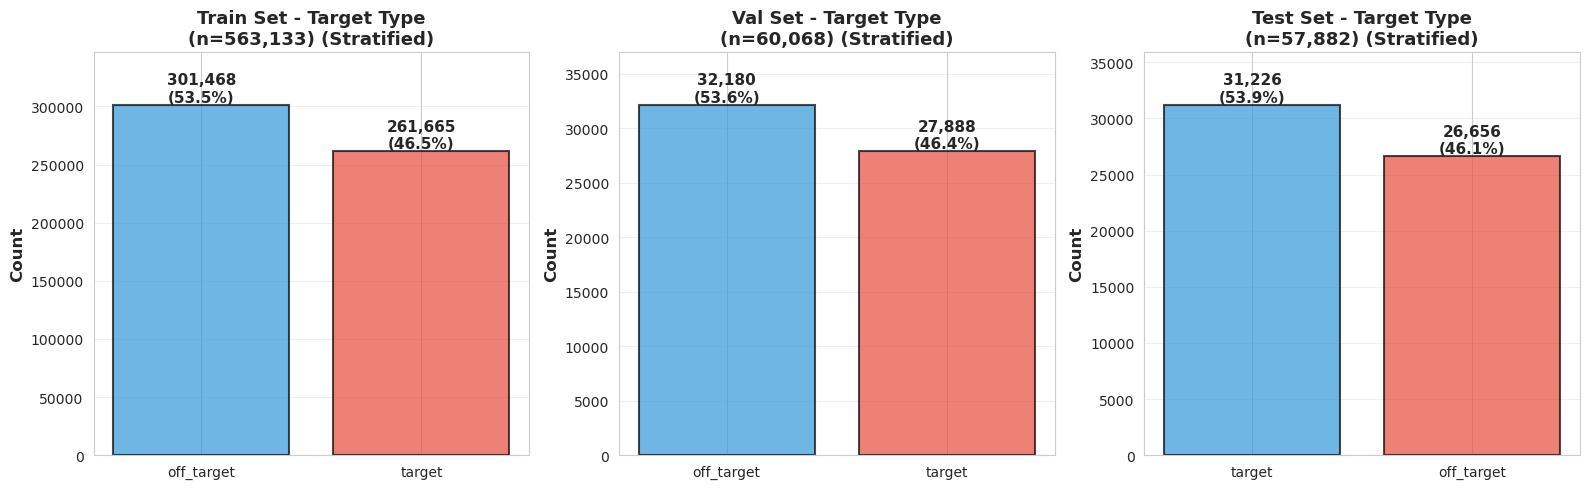


2️⃣ Creating stacked target type comparison...
✅ Saved: /scratch/yunmin/data/graph/train/identity50/plots/stratified/split_target_type_stacked.png


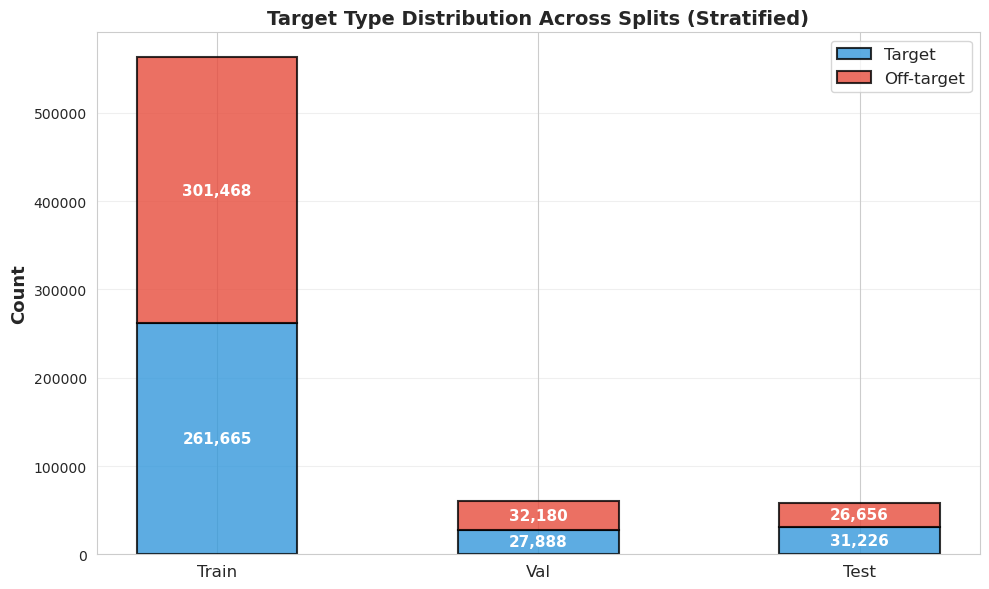


3️⃣ Creating data source distribution plots...
✅ Saved: /scratch/yunmin/data/graph/train/identity50/plots/stratified/split_data_source_distribution.png


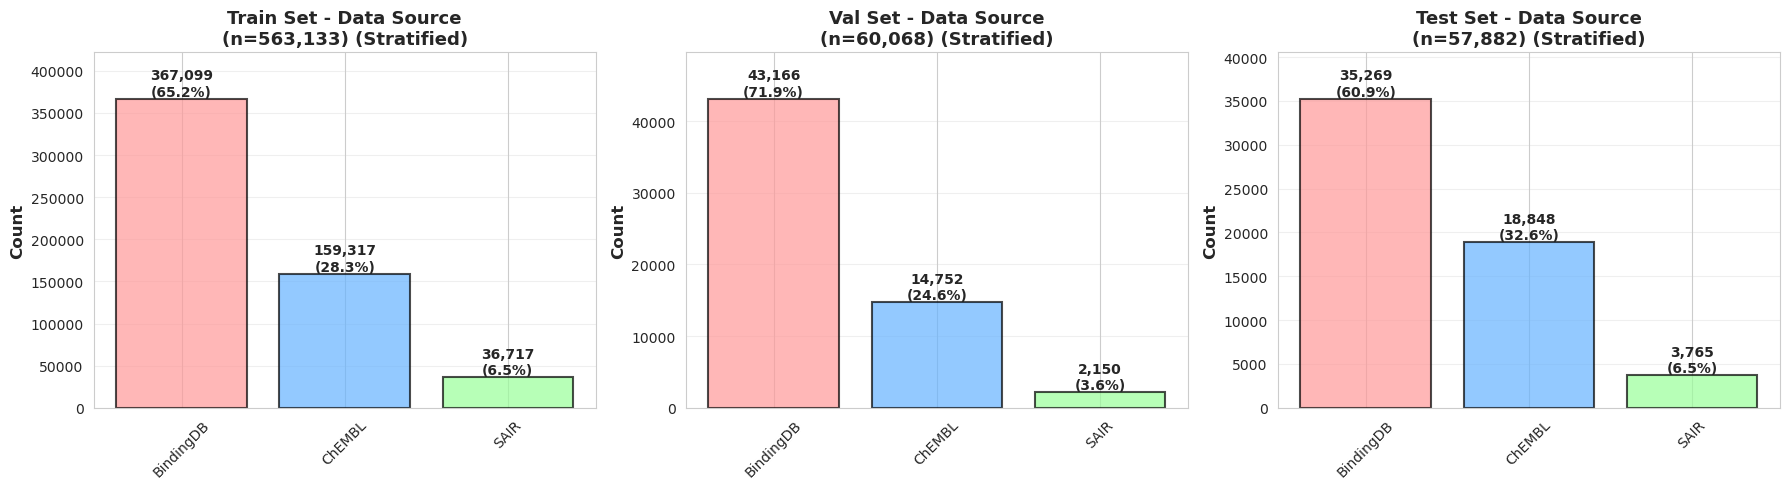


4️⃣ Creating stacked data source comparison...
✅ Saved: /scratch/yunmin/data/graph/train/identity50/plots/stratified/split_data_source_stacked.png


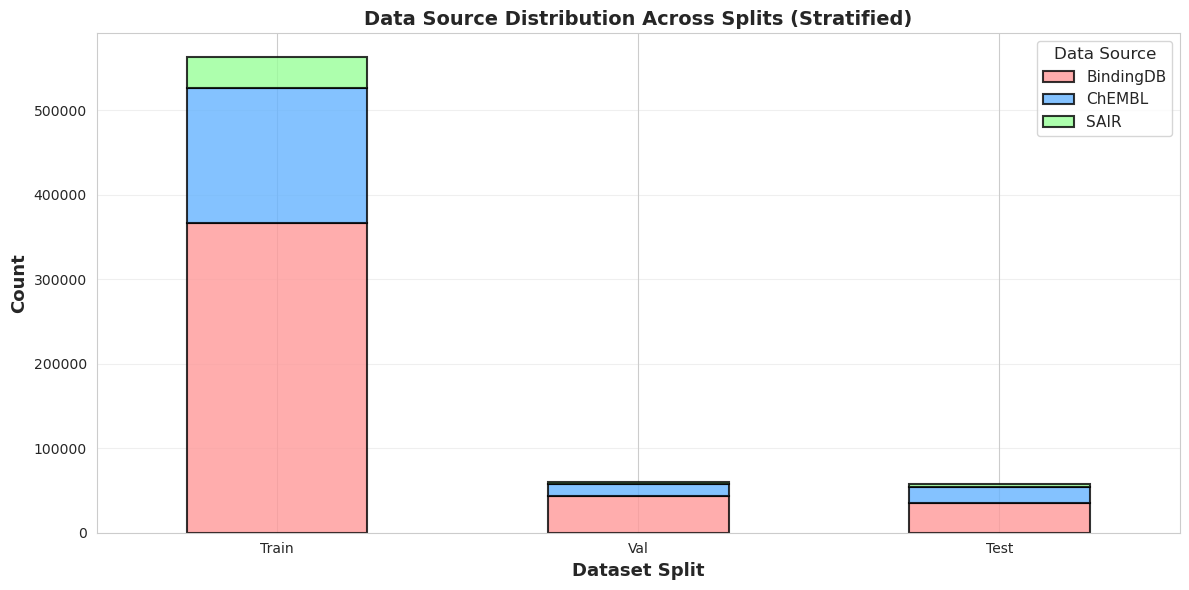


5️⃣ Creating protein-ligand pairs distribution plots...
✅ Saved: /scratch/yunmin/data/graph/train/identity50/plots/stratified/split_pl_pairs_distribution.png


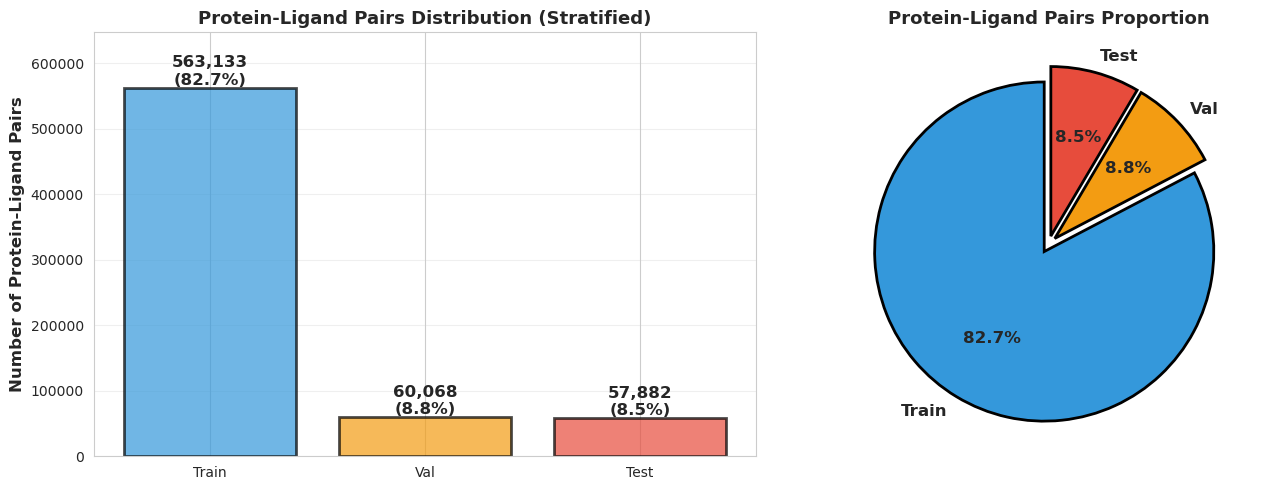


6️⃣ Creating unique proteins distribution plots...
✅ Saved: /scratch/yunmin/data/graph/train/identity50/plots/stratified/split_unique_proteins_distribution.png


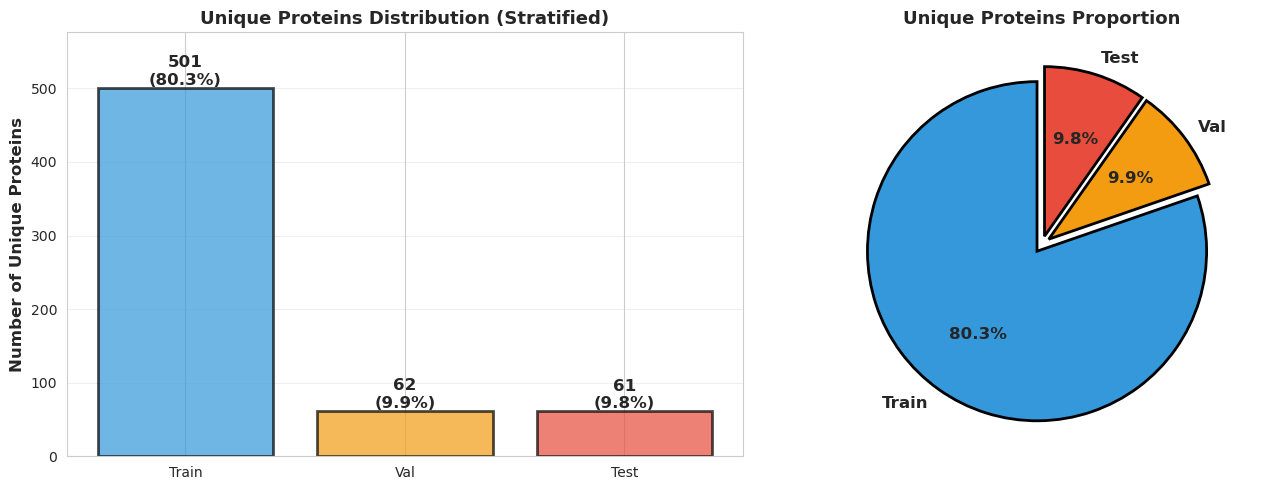


7️⃣ Creating unique ligands distribution plots...
✅ Saved: /scratch/yunmin/data/graph/train/identity50/plots/stratified/split_unique_ligands_distribution.png


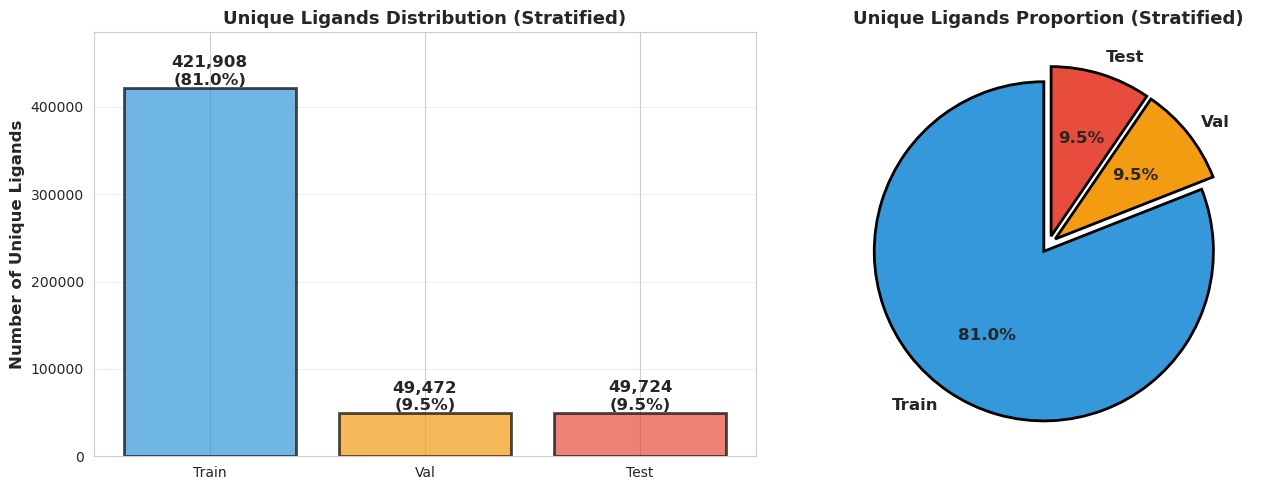


8️⃣ Creating comprehensive summary comparison...
✅ Saved: /scratch/yunmin/data/graph/train/identity50/plots/stratified/split_comprehensive_summary.png


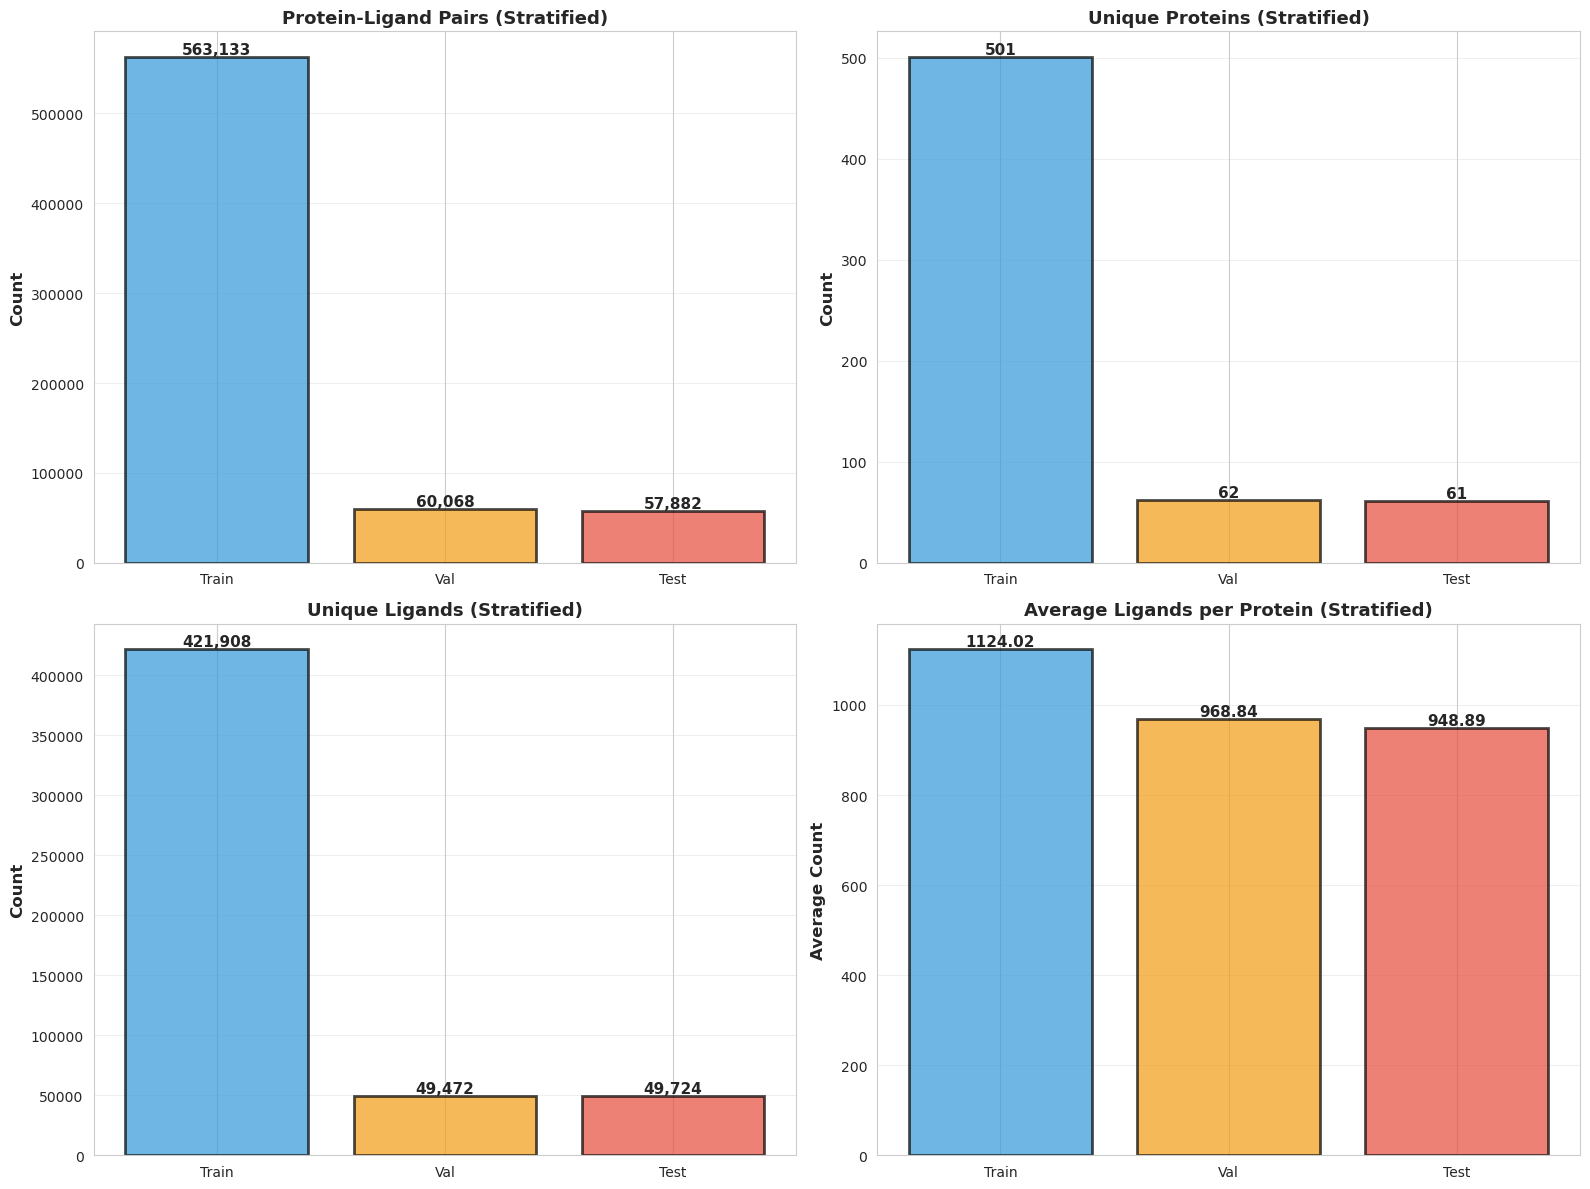


9️⃣ Creating summary statistics table...
✅ Saved: /scratch/yunmin/data/graph/train/identity50/plots/stratified/split_summary_table.png


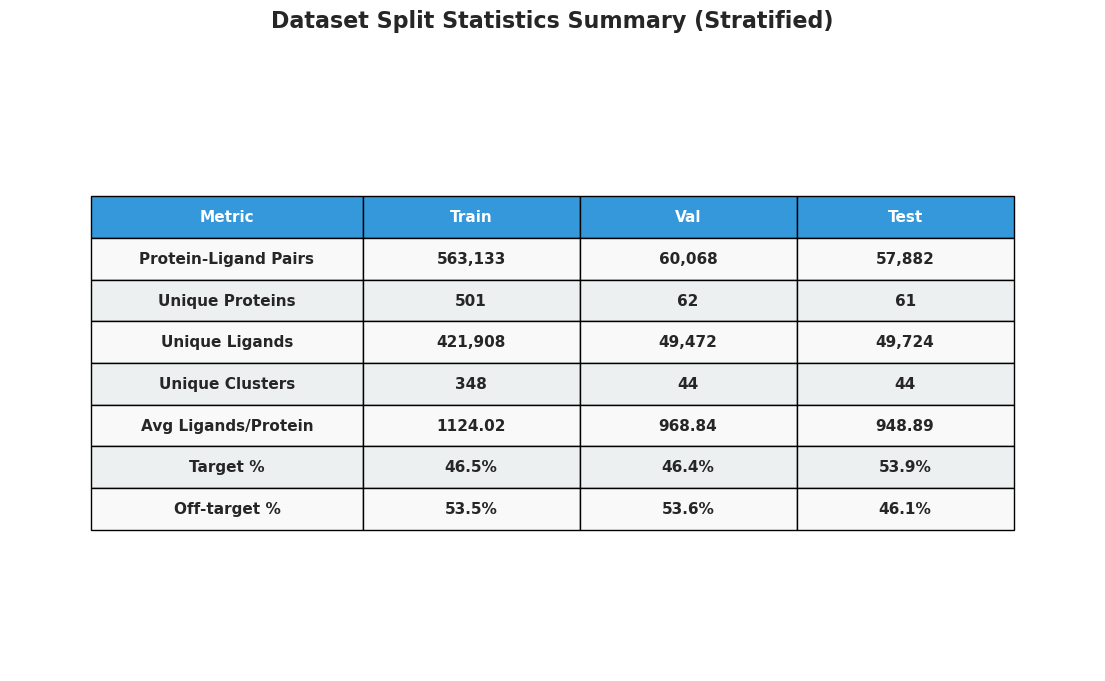


SUMMARY STATISTICS
              Metric   Train    Val   Test
Protein-Ligand Pairs 563,133 60,068 57,882
     Unique Proteins     501     62     61
      Unique Ligands 421,908 49,472 49,724
     Unique Clusters     348     44     44
 Avg Ligands/Protein 1124.02 968.84 948.89
            Target %   46.5%  46.4%  53.9%
        Off-target %   53.5%  53.6%  46.1%

All split distribution visualizations complete!
✅ Generated 9 visualization files:
   1. split_target_type_distribution.png - Individual target type bar charts
   2. split_target_type_stacked.png - Stacked target type comparison
   3. split_data_source_distribution.png - Individual data source bar charts
   4. split_data_source_stacked.png - Stacked data source comparison
   5. split_pl_pairs_distribution.png - Protein-ligand pairs (bar + pie)
   6. split_unique_proteins_distribution.png - Unique proteins (bar + pie)
   7. split_unique_ligands_distribution.png - Unique ligands (bar + pie)
   8. split_comprehensive_summary.png -

In [99]:
print("\n" + "=" * 80)
print("Creating comprehensive split distribution plots (stratified splitting)")
print("=" * 80)

train_proteins_strat = train_df_strat[['uniprot_id', 'sequence']].drop_duplicates()
val_proteins_strat = val_df_strat[['uniprot_id', 'sequence']].drop_duplicates()
test_proteins_strat = test_df_strat[['uniprot_id', 'sequence']].drop_duplicates()

# ========================================================================
# 1. Target Type Distribution across splits
# ========================================================================

print("\n1️⃣ Creating target type distribution plots...")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, (split_name, split_df) in enumerate([('Train', train_df_strat), ('Val', val_df_strat), ('Test', test_df_strat)]):
    target_counts = split_df['target_type'].value_counts()
    colors = ['#3498db', '#e74c3c']
    
    bars = axes[idx].bar(target_counts.index, target_counts.values, 
                         color=colors[:len(target_counts)], alpha=0.7, edgecolor='black', linewidth=1.5)
    axes[idx].set_ylabel('Count', fontsize=12, fontweight='bold')
    axes[idx].set_title(f'{split_name} Set - Target Type\n(n={len(split_df):,}) (Stratified)', 
                        fontsize=13, fontweight='bold')
    axes[idx].grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        axes[idx].text(bar.get_x() + bar.get_width()/2., height,
                      f'{int(height):,}\n({height/len(split_df)*100:.1f}%)',
                      ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    axes[idx].set_ylim(0, max(target_counts.values) * 1.15)

plt.tight_layout()
plt.savefig('/scratch/yunmin/data/graph/train/identity50/plots/stratified/split_target_type_distribution.png', 
            dpi=300, bbox_inches='tight')
print("✅ Saved: /scratch/yunmin/data/graph/train/identity50/plots/stratified/split_target_type_distribution.png")
plt.show()

# ========================================================================
# 2. Target Type Distribution - Stacked Comparison
# ========================================================================

print("\n2️⃣ Creating stacked target type comparison...")

split_data = []
for split_name, split_df in [('Train', train_df_strat), ('Val', val_df_strat), ('Test', test_df_strat)]:
    target_counts = split_df['target_type'].value_counts()
    split_data.append({
        'split': split_name,
        'target': target_counts.get('target', 0),
        'off_target': target_counts.get('off_target', 0)
    })

split_df_vis = pd.DataFrame(split_data)
split_df_vis = split_df_vis.set_index('split')

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(split_df_vis))
width = 0.5

bars1 = ax.bar(x, split_df_vis['target'], width, label='Target', 
               color='#3498db', alpha=0.8, edgecolor='black', linewidth=1.5)
bars2 = ax.bar(x, split_df_vis['off_target'], width, bottom=split_df_vis['target'],
               label='Off-target', color='#e74c3c', alpha=0.8, edgecolor='black', linewidth=1.5)

ax.set_ylabel('Count', fontsize=13, fontweight='bold')
ax.set_title('Target Type Distribution Across Splits (Stratified)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(split_df_vis.index, fontsize=12)
ax.legend(fontsize=12, loc='upper right')
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2., bar.get_y() + height/2.,
                   f'{int(height):,}',
                   ha='center', va='center', fontsize=11, fontweight='bold', color='white')

plt.tight_layout()
plt.savefig('/scratch/yunmin/data/graph/train/identity50/plots/stratified/split_target_type_stacked.png', 
            dpi=300, bbox_inches='tight')
print("✅ Saved: /scratch/yunmin/data/graph/train/identity50/plots/stratified/split_target_type_stacked.png")
plt.show()

# ========================================================================
# 3. Data Source Distribution across splits
# ========================================================================

print("\n3️⃣ Creating data source distribution plots...")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (split_name, split_df) in enumerate([('Train', train_df_strat), ('Val', val_df_strat), ('Test', test_df_strat)]):
    source_counts = split_df['data_source'].value_counts()
    colors = ['#ff9999', '#66b3ff', '#99ff99']
    
    bars = axes[idx].bar(source_counts.index, source_counts.values, 
                         color=colors[:len(source_counts)], alpha=0.7, edgecolor='black', linewidth=1.5)
    axes[idx].set_ylabel('Count', fontsize=12, fontweight='bold')
    axes[idx].set_title(f'{split_name} Set - Data Source\n(n={len(split_df):,}) (Stratified)', 
                        fontsize=13, fontweight='bold')
    axes[idx].grid(True, alpha=0.3, axis='y')
    axes[idx].tick_params(axis='x', rotation=45)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        axes[idx].text(bar.get_x() + bar.get_width()/2., height,
                      f'{int(height):,}\n({height/len(split_df)*100:.1f}%)',
                      ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    axes[idx].set_ylim(0, max(source_counts.values) * 1.15)

plt.tight_layout()
plt.savefig('/scratch/yunmin/data/graph/train/identity50/plots/stratified/split_data_source_distribution.png', 
            dpi=300, bbox_inches='tight')
print("✅ Saved: /scratch/yunmin/data/graph/train/identity50/plots/stratified/split_data_source_distribution.png")
plt.show()

# ========================================================================
# 4. Data Source Distribution - Stacked Comparison
# ========================================================================

print("\n4️⃣ Creating stacked data source comparison...")

split_source_data = {}
for split_name, split_df in [('Train', train_df_strat), ('Val', val_df_strat), ('Test', test_df_strat)]:
    source_counts = split_df['data_source'].value_counts()
    split_source_data[split_name] = source_counts

split_source_df = pd.DataFrame(split_source_data).fillna(0)

fig, ax = plt.subplots(figsize=(12, 6))

split_source_df.T.plot(kind='bar', stacked=True, ax=ax, 
                       color=['#ff9999', '#66b3ff', '#99ff99'],
                       edgecolor='black', linewidth=1.5, alpha=0.8)

ax.set_ylabel('Count', fontsize=13, fontweight='bold')
ax.set_xlabel('Dataset Split', fontsize=13, fontweight='bold')
ax.set_title('Data Source Distribution Across Splits (Stratified)', fontsize=14, fontweight='bold')
ax.legend(title='Data Source', fontsize=11, title_fontsize=12, loc='upper right')
ax.grid(True, alpha=0.3, axis='y')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.savefig('/scratch/yunmin/data/graph/train/identity50/plots/stratified/split_data_source_stacked.png', 
            dpi=300, bbox_inches='tight')
print("✅ Saved: /scratch/yunmin/data/graph/train/identity50/plots/stratified/split_data_source_stacked.png")
plt.show()

# ========================================================================
# 5. Protein-Ligand Pairs Distribution
# ========================================================================

print("\n5️⃣ Creating protein-ligand pairs distribution plots...")

pairs_data = {
    'Train': len(train_df_strat),
    'Val': len(val_df_strat),
    'Test': len(test_df_strat)
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
splits = list(pairs_data.keys())
counts = list(pairs_data.values())
colors_split = ['#3498db', '#f39c12', '#e74c3c']

bars = axes[0].bar(splits, counts, color=colors_split, alpha=0.7, edgecolor='black', linewidth=2)
axes[0].set_ylabel('Number of Protein-Ligand Pairs', fontsize=12, fontweight='bold')
axes[0].set_title('Protein-Ligand Pairs Distribution (Stratified)', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, count in zip(bars, counts):
    height = bar.get_height()
    percentage = count / sum(counts) * 100
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(count):,}\n({percentage:.1f}%)',
                ha='center', va='bottom', fontsize=12, fontweight='bold')

axes[0].set_ylim(0, max(counts) * 1.15)

# Pie plot
axes[1].pie(counts, labels=splits, autopct='%1.1f%%', startangle=90,
           colors=colors_split, explode=(0.05, 0.05, 0.05),
           textprops={'fontsize': 12, 'fontweight': 'bold'},
           wedgeprops={'edgecolor': 'black', 'linewidth': 2})
axes[1].set_title('Protein-Ligand Pairs Proportion', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('/scratch/yunmin/data/graph/train/identity50/plots/stratified/split_pl_pairs_distribution.png', 
            dpi=300, bbox_inches='tight')
print("✅ Saved: /scratch/yunmin/data/graph/train/identity50/plots/stratified/split_pl_pairs_distribution.png")
plt.show()

# ========================================================================
# 6. Unique Proteins Distribution
# ========================================================================

print("\n6️⃣ Creating unique proteins distribution plots...")

proteins_data = {
    'Train': len(train_proteins_strat),
    'Val': len(val_proteins_strat),
    'Test': len(test_proteins_strat)
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
splits = list(proteins_data.keys())
counts = list(proteins_data.values())

bars = axes[0].bar(splits, counts, color=colors_split, alpha=0.7, edgecolor='black', linewidth=2)
axes[0].set_ylabel('Number of Unique Proteins', fontsize=12, fontweight='bold')
axes[0].set_title('Unique Proteins Distribution (Stratified)', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, count in zip(bars, counts):
    height = bar.get_height()
    percentage = count / sum(counts) * 100
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(count):,}\n({percentage:.1f}%)',
                ha='center', va='bottom', fontsize=12, fontweight='bold')

axes[0].set_ylim(0, max(counts) * 1.15)

# Pie plot
axes[1].pie(counts, labels=splits, autopct='%1.1f%%', startangle=90,
           colors=colors_split, explode=(0.05, 0.05, 0.05),
           textprops={'fontsize': 12, 'fontweight': 'bold'},
           wedgeprops={'edgecolor': 'black', 'linewidth': 2})
axes[1].set_title('Unique Proteins Proportion', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('/scratch/yunmin/data/graph/train/identity50/plots/stratified/split_unique_proteins_distribution.png', 
            dpi=300, bbox_inches='tight')
print("✅ Saved: /scratch/yunmin/data/graph/train/identity50/plots/stratified/split_unique_proteins_distribution.png")
plt.show()

# ========================================================================
# 7. Unique Ligands Distribution
# ========================================================================

print("\n7️⃣ Creating unique ligands distribution plots...")

ligands_data = {
    'Train': train_df_strat['ligand_smiles'].nunique(),
    'Val': val_df_strat['ligand_smiles'].nunique(),
    'Test': test_df_strat['ligand_smiles'].nunique()
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
splits = list(ligands_data.keys())
counts = list(ligands_data.values())

bars = axes[0].bar(splits, counts, color=colors_split, alpha=0.7, edgecolor='black', linewidth=2)
axes[0].set_ylabel('Number of Unique Ligands', fontsize=12, fontweight='bold')
axes[0].set_title('Unique Ligands Distribution (Stratified)', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, count in zip(bars, counts):
    height = bar.get_height()
    percentage = count / sum(counts) * 100
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(count):,}\n({percentage:.1f}%)',
                ha='center', va='bottom', fontsize=12, fontweight='bold')

axes[0].set_ylim(0, max(counts) * 1.15)

# Pie plot
axes[1].pie(counts, labels=splits, autopct='%1.1f%%', startangle=90,
           colors=colors_split, explode=(0.05, 0.05, 0.05),
           textprops={'fontsize': 12, 'fontweight': 'bold'},
           wedgeprops={'edgecolor': 'black', 'linewidth': 2})
axes[1].set_title('Unique Ligands Proportion (Stratified)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('/scratch/yunmin/data/graph/train/identity50/plots/stratified/split_unique_ligands_distribution.png', 
            dpi=300, bbox_inches='tight')
print("✅ Saved: /scratch/yunmin/data/graph/train/identity50/plots/stratified/split_unique_ligands_distribution.png")
plt.show()

# ========================================================================
# 8. Comprehensive Summary Comparison
# ========================================================================

print("\n8️⃣ Creating comprehensive summary comparison...")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 8.1 Protein-Ligand Pairs
pairs_data = [len(train_df_strat), len(val_df_strat), len(test_df_strat)]
bars = axes[0, 0].bar(['Train', 'Val', 'Test'], pairs_data, 
                      color=colors_split, alpha=0.7, edgecolor='black', linewidth=2)
axes[0, 0].set_ylabel('Count', fontsize=12, fontweight='bold')
axes[0, 0].set_title('Protein-Ligand Pairs (Stratified)', fontsize=13, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, pairs_data):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                   f'{int(val):,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# 8.2 Unique Proteins
proteins_data = [len(train_proteins_strat), len(val_proteins_strat), len(test_proteins_strat)]
bars = axes[0, 1].bar(['Train', 'Val', 'Test'], proteins_data, 
                      color=colors_split, alpha=0.7, edgecolor='black', linewidth=2)
axes[0, 1].set_ylabel('Count', fontsize=12, fontweight='bold')
axes[0, 1].set_title('Unique Proteins (Stratified)', fontsize=13, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, proteins_data):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                   f'{int(val):,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# 8.3 Unique Ligands
ligands_data = [train_df_strat['ligand_smiles'].nunique(), 
                val_df_strat['ligand_smiles'].nunique(),
                test_df_strat['ligand_smiles'].nunique()]
bars = axes[1, 0].bar(['Train', 'Val', 'Test'], ligands_data, 
                      color=colors_split, alpha=0.7, edgecolor='black', linewidth=2)
axes[1, 0].set_ylabel('Count', fontsize=12, fontweight='bold')
axes[1, 0].set_title('Unique Ligands (Stratified)', fontsize=13, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, ligands_data):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                   f'{int(val):,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# 8.4 Ligands per Protein (Average)
avg_ligands = [
    len(train_df_strat) / len(train_proteins_strat),
    len(val_df_strat) / len(val_proteins_strat),
    len(test_df_strat) / len(test_proteins_strat)
]
bars = axes[1, 1].bar(['Train', 'Val', 'Test'], avg_ligands, 
                      color=colors_split, alpha=0.7, edgecolor='black', linewidth=2)
axes[1, 1].set_ylabel('Average Count', fontsize=12, fontweight='bold')
axes[1, 1].set_title('Average Ligands per Protein (Stratified)', fontsize=13, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, avg_ligands):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                   f'{val:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('/scratch/yunmin/data/graph/train/identity50/plots/stratified/split_comprehensive_summary.png', 
            dpi=300, bbox_inches='tight')
print("✅ Saved: /scratch/yunmin/data/graph/train/identity50/plots/stratified/split_comprehensive_summary.png")
plt.show()

# ========================================================================
# 9. Summary Statistics Table
# ========================================================================

print("\n9️⃣ Creating summary statistics table...")

summary_stats = pd.DataFrame({
    'Metric': [
        'Protein-Ligand Pairs',
        'Unique Proteins',
        'Unique Ligands',
        'Unique Clusters',
        'Avg Ligands/Protein',
        'Target %',
        'Off-target %'
    ],
    'Train': [
        f"{len(train_df_strat):,}",
        f"{len(train_proteins_strat):,}",
        f"{train_df_strat['ligand_smiles'].nunique():,}",
        f"{len(train_clusters_strat):,}",
        f"{len(train_df_strat) / len(train_proteins_strat):.2f}",
        f"{(train_df_strat['target_type'] == 'target').sum() / len(train_df_strat) * 100:.1f}%",
        f"{(train_df_strat['target_type'] == 'off_target').sum() / len(train_df_strat) * 100:.1f}%"
    ],
    'Val': [
        f"{len(val_df_strat):,}",
        f"{len(val_proteins_strat):,}",
        f"{val_df_strat['ligand_smiles'].nunique():,}",
        f"{len(val_clusters_strat):,}",
        f"{len(val_df_strat) / len(val_proteins_strat):.2f}",
        f"{(val_df_strat['target_type'] == 'target').sum() / len(val_df_strat) * 100:.1f}%",
        f"{(val_df_strat['target_type'] == 'off_target').sum() / len(val_df_strat) * 100:.1f}%"
    ],
    'Test': [
        f"{len(test_df_strat):,}",
        f"{len(test_proteins_strat):,}",
        f"{test_df_strat['ligand_smiles'].nunique():,}",
        f"{len(test_clusters_strat):,}",
        f"{len(test_df_strat) / len(test_proteins_strat):.2f}",
        f"{(test_df_strat['target_type'] == 'target').sum() / len(test_df_strat) * 100:.1f}%",
        f"{(test_df_strat['target_type'] == 'off_target').sum() / len(test_df_strat) * 100:.1f}%"
    ]
})

# Create figure with table
fig, ax = plt.subplots(figsize=(14, 8))
ax.axis('tight')
ax.axis('off')

table = ax.table(cellText=summary_stats.values, 
                colLabels=summary_stats.columns,
                cellLoc='center', loc='center',
                colWidths=[0.25, 0.2, 0.2, 0.2])

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.5)

# Style header
for i in range(len(summary_stats.columns)):
    table[(0, i)].set_facecolor('#3498db')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Alternate row colors
for i in range(1, len(summary_stats) + 1):
    for j in range(len(summary_stats.columns)):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#ecf0f1')
        else:
            table[(i, j)].set_facecolor('#f9f9f9')
        table[(i, j)].set_text_props(weight='bold')

plt.title('Dataset Split Statistics Summary (Stratified)', fontsize=16, fontweight='bold', pad=20)
plt.savefig('/scratch/yunmin/data/graph/train/identity50/plots/stratified/split_summary_table.png', 
            dpi=300, bbox_inches='tight')
print("✅ Saved: /scratch/yunmin/data/graph/train/identity50/plots/stratified/split_summary_table.png")
plt.show()

# Print table to console
print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)
print(summary_stats.to_string(index=False))
print("="*80)

print("\n" + "=" * 80)
print("All split distribution visualizations complete!")
print("=" * 80)
print(f"✅ Generated 9 visualization files:")
print(f"   1. split_target_type_distribution.png - Individual target type bar charts")
print(f"   2. split_target_type_stacked.png - Stacked target type comparison")
print(f"   3. split_data_source_distribution.png - Individual data source bar charts")
print(f"   4. split_data_source_stacked.png - Stacked data source comparison")
print(f"   5. split_pl_pairs_distribution.png - Protein-ligand pairs (bar + pie)")
print(f"   6. split_unique_proteins_distribution.png - Unique proteins (bar + pie)")
print(f"   7. split_unique_ligands_distribution.png - Unique ligands (bar + pie)")
print(f"   8. split_comprehensive_summary.png - 2x2 summary comparison")
print(f"   9. split_summary_table.png - Statistics table")

### Visualize clusters using t-SNE and PCA


VISUALIZING CLUSTERS: t-SNE and PCA

1️⃣ Encoding sequences...
Computing k-mer frequencies...
  - Total unique 3-mers: 8,020
  - K-mer matrix shape: (1979, 8020)
✅ Sequences encoded and scaled
  - Unique clusters: 1979

2️⃣ Computing PCA...
  - PCA variance explained: 6.1%
  - PC1: 5.2%
  - PC2: 1.0%
✅ Saved: /scratch/yunmin/data/graph/train/cluster_pca.png


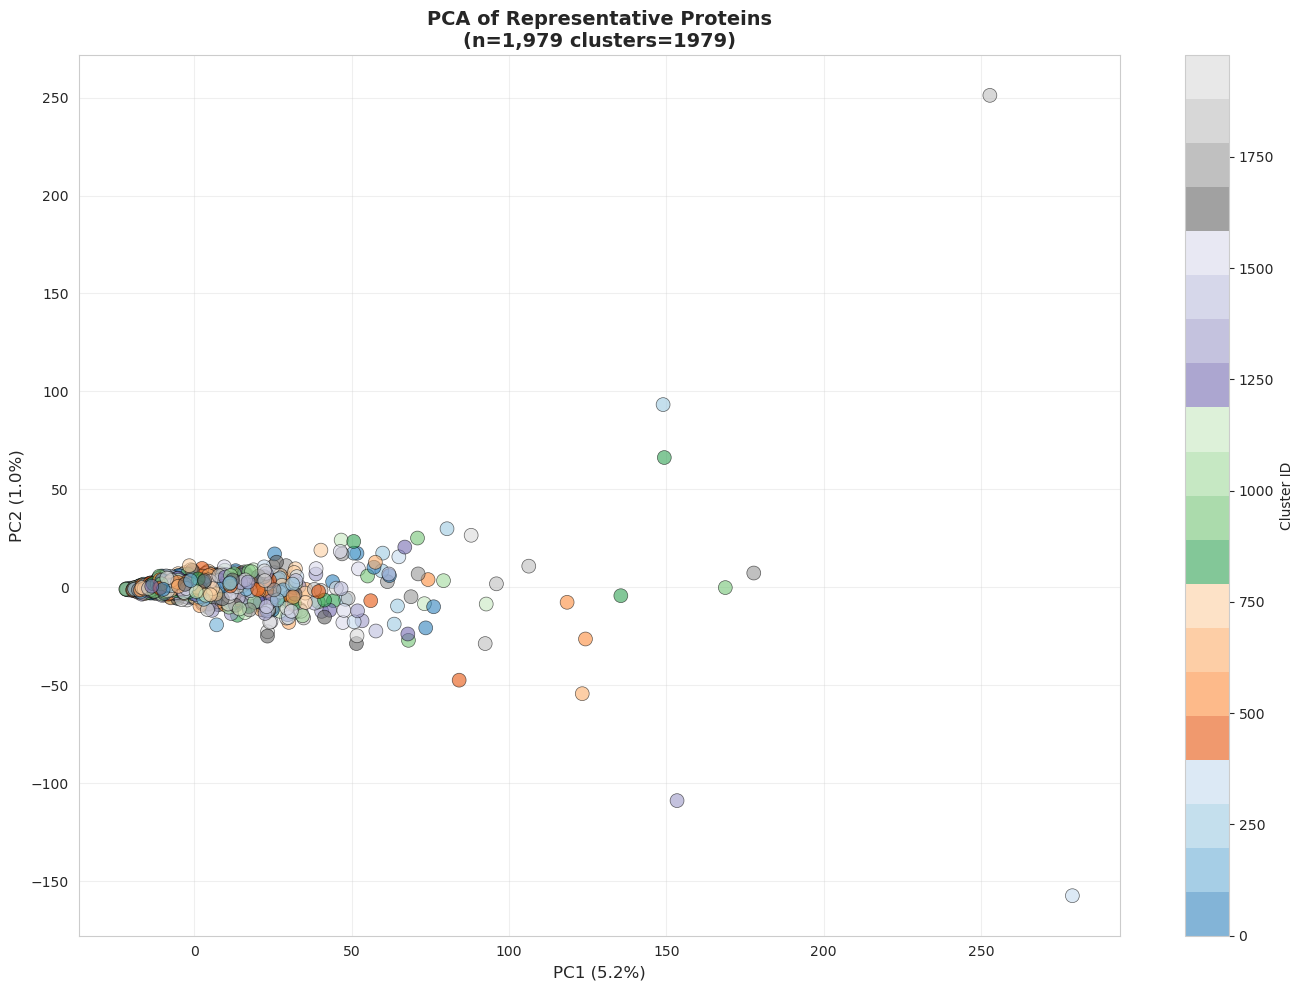


3️⃣ Computing t-SNE...
  (This may take a few minutes for large datasets)
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 1979 samples in 0.001s...
[t-SNE] Computed neighbors for 1979 samples in 0.153s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1979
[t-SNE] Computed conditional probabilities for sample 1979 / 1979
[t-SNE] Mean sigma: 3.096642
[t-SNE] KL divergence after 250 iterations with early exaggeration: 71.965363
[t-SNE] KL divergence after 1000 iterations: 1.498105
✅ t-SNE completed
✅ Saved: /scratch/yunmin/data/graph/train/cluster_tsne.png


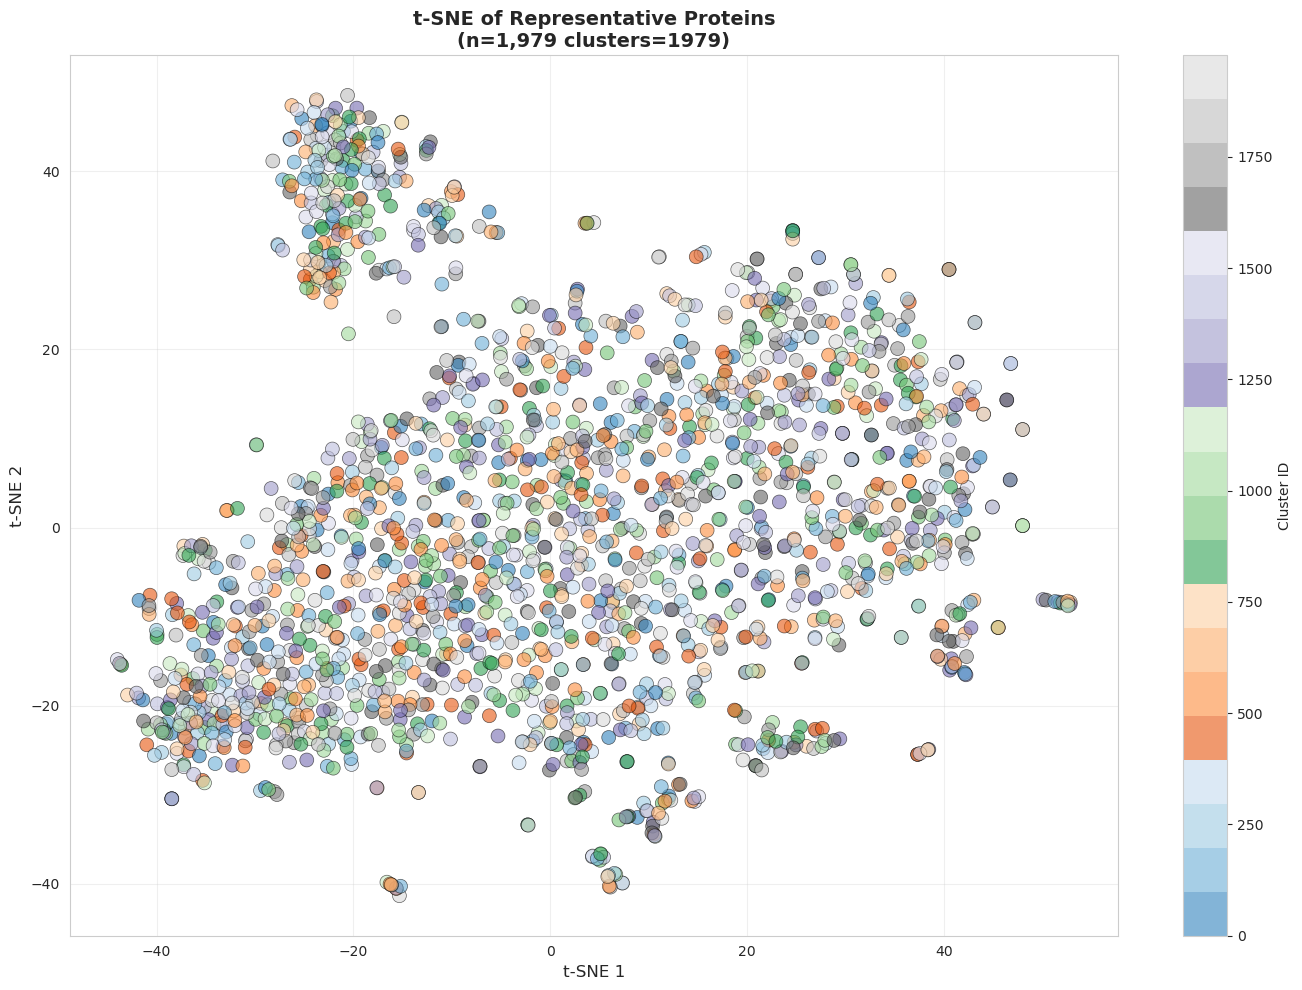


4️⃣ Visualizing Train/Val/Test splits on t-SNE...
✅ Saved: /scratch/yunmin/data/graph/train/cluster_tsne_splits.png


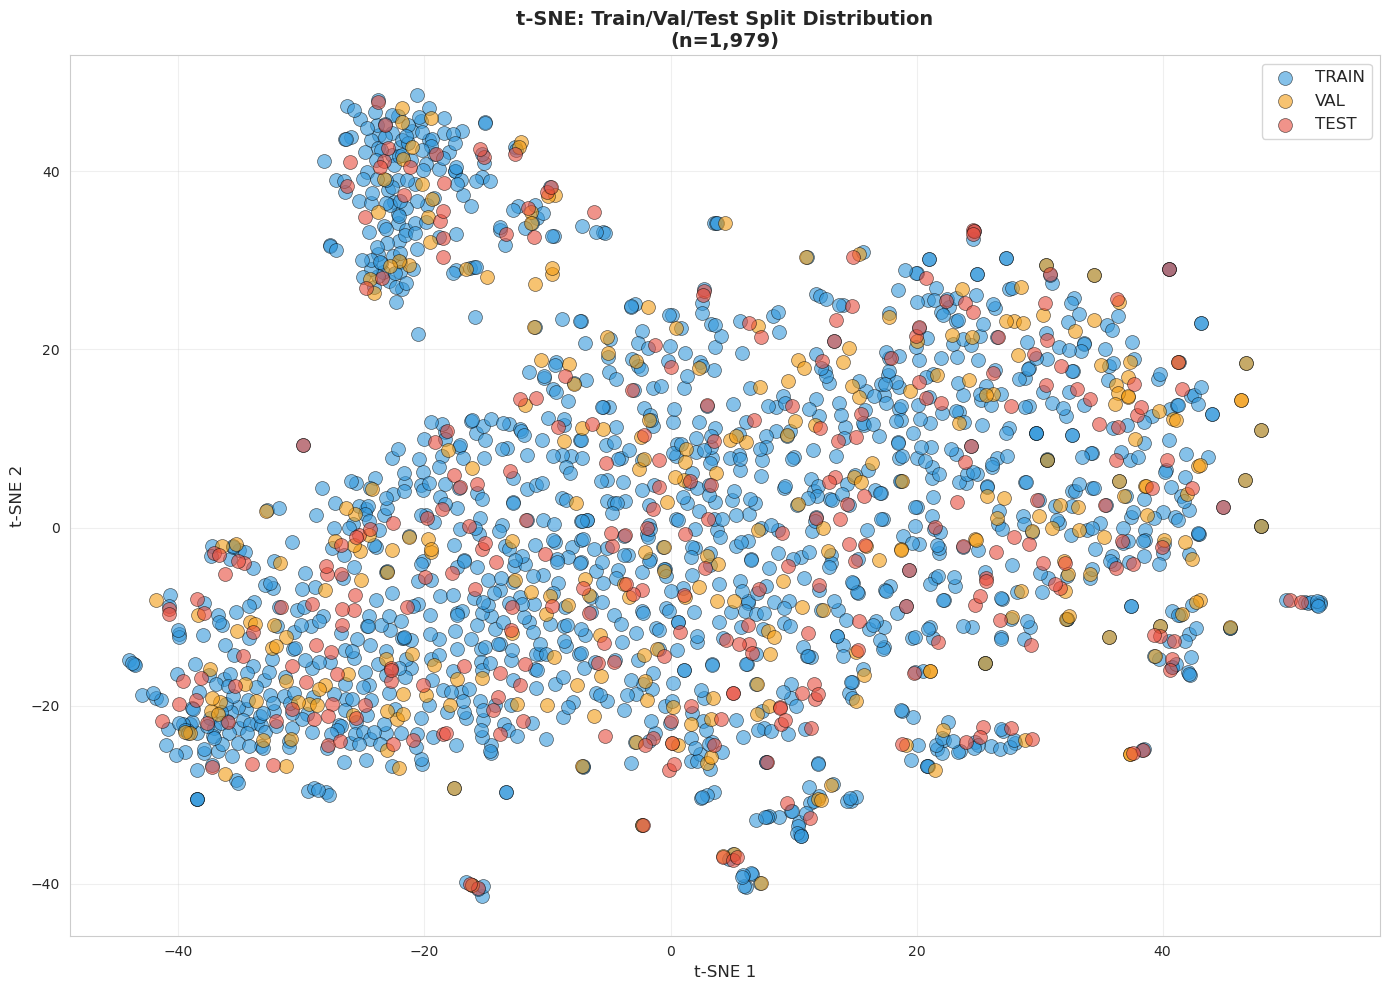


5️⃣ Visualizing cluster sizes on t-SNE...
✅ Saved: /scratch/yunmin/data/graph/train/cluster_tsne_sizes.png


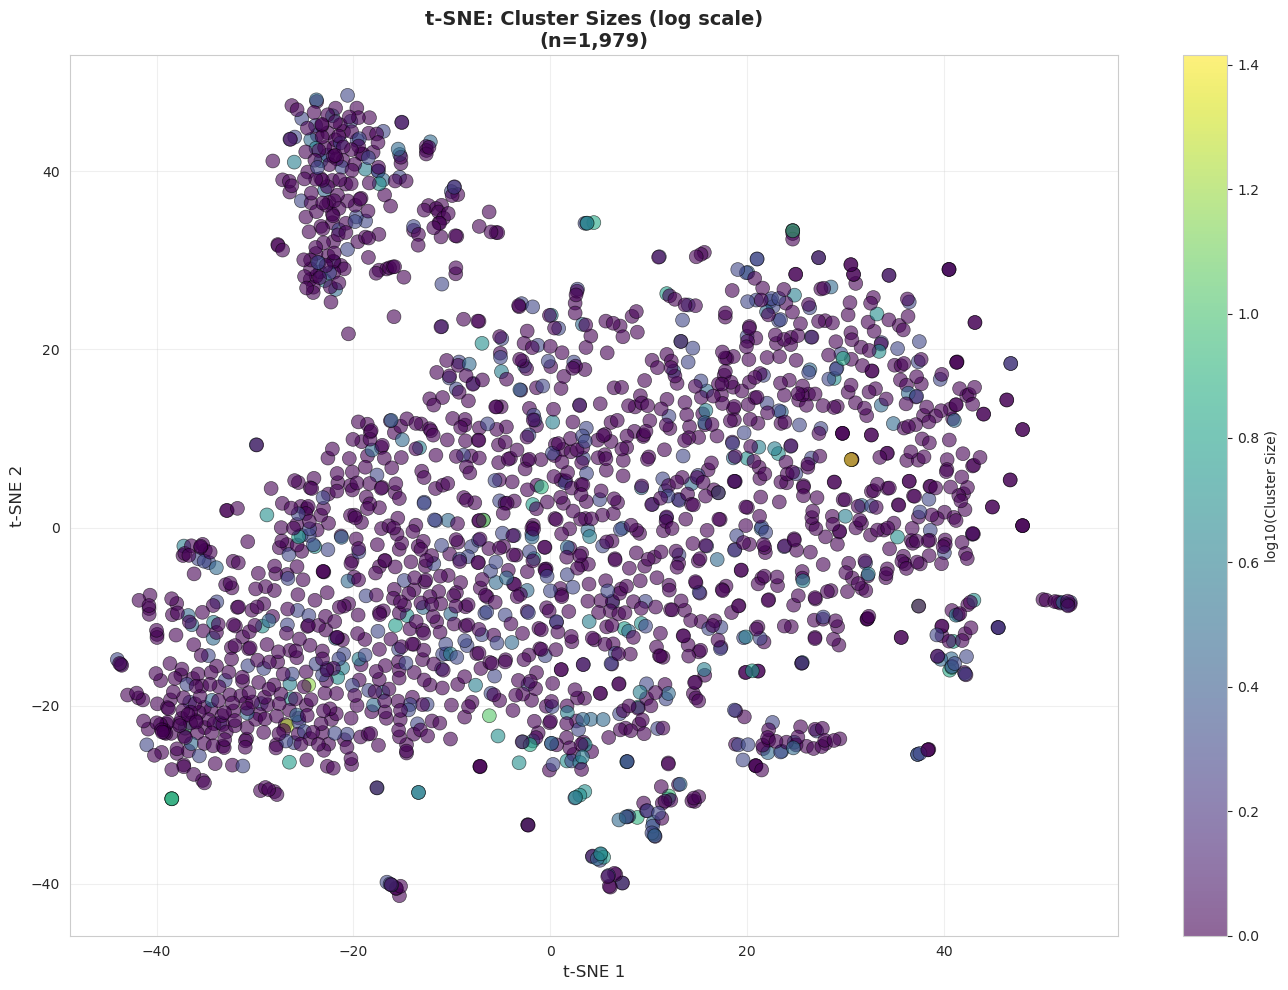


6️⃣ Visualizing sequence length on t-SNE...
✅ Saved: /scratch/yunmin/data/graph/train/cluster_tsne_seqlen.png


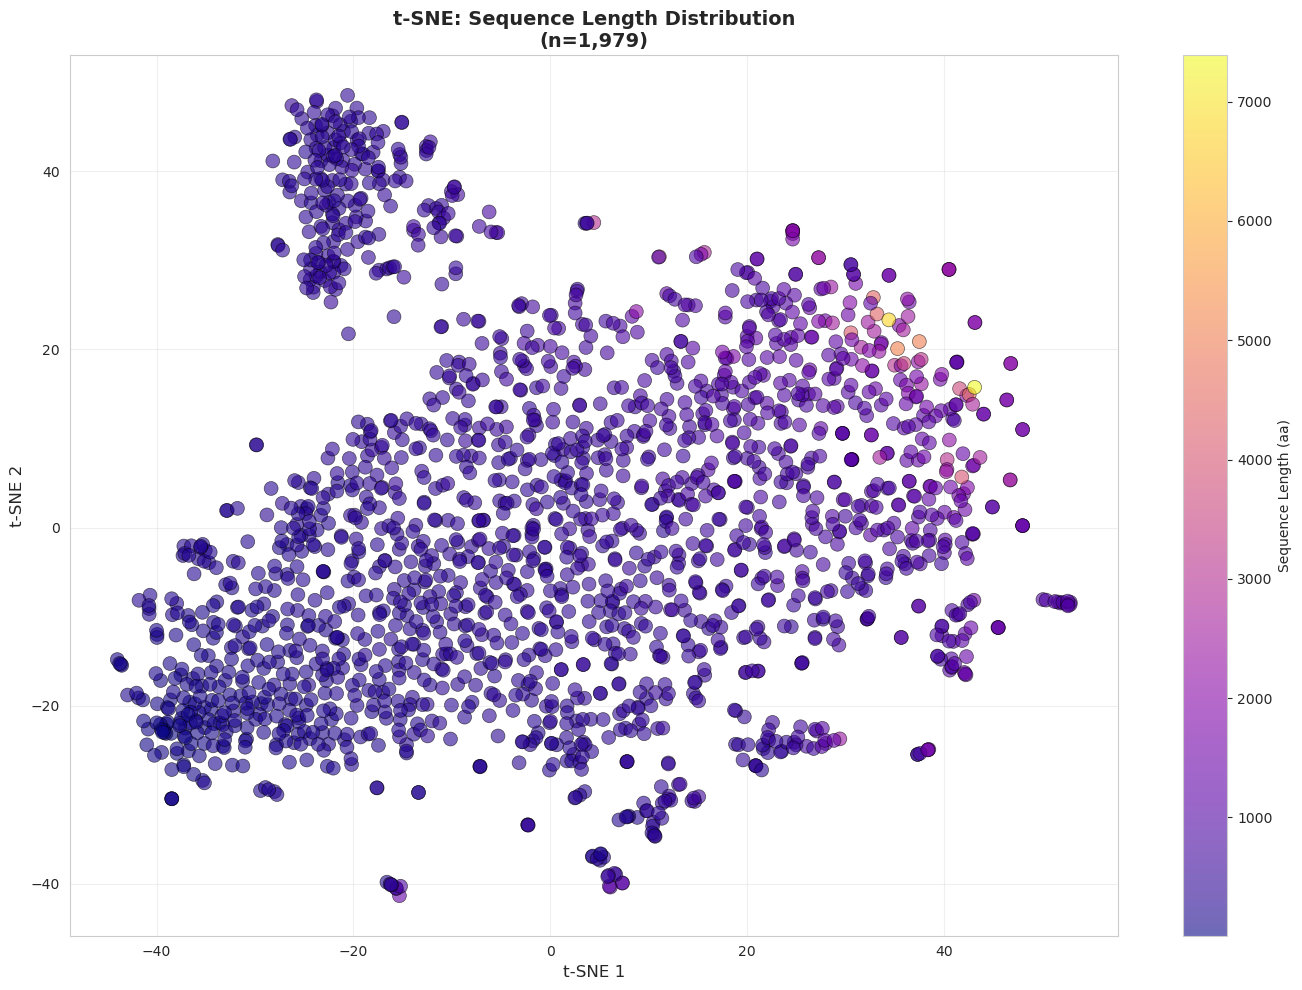


7️⃣ Creating comparison figure...
✅ Saved: /scratch/yunmin/data/graph/train/cluster_comparison_pca_tsne.png


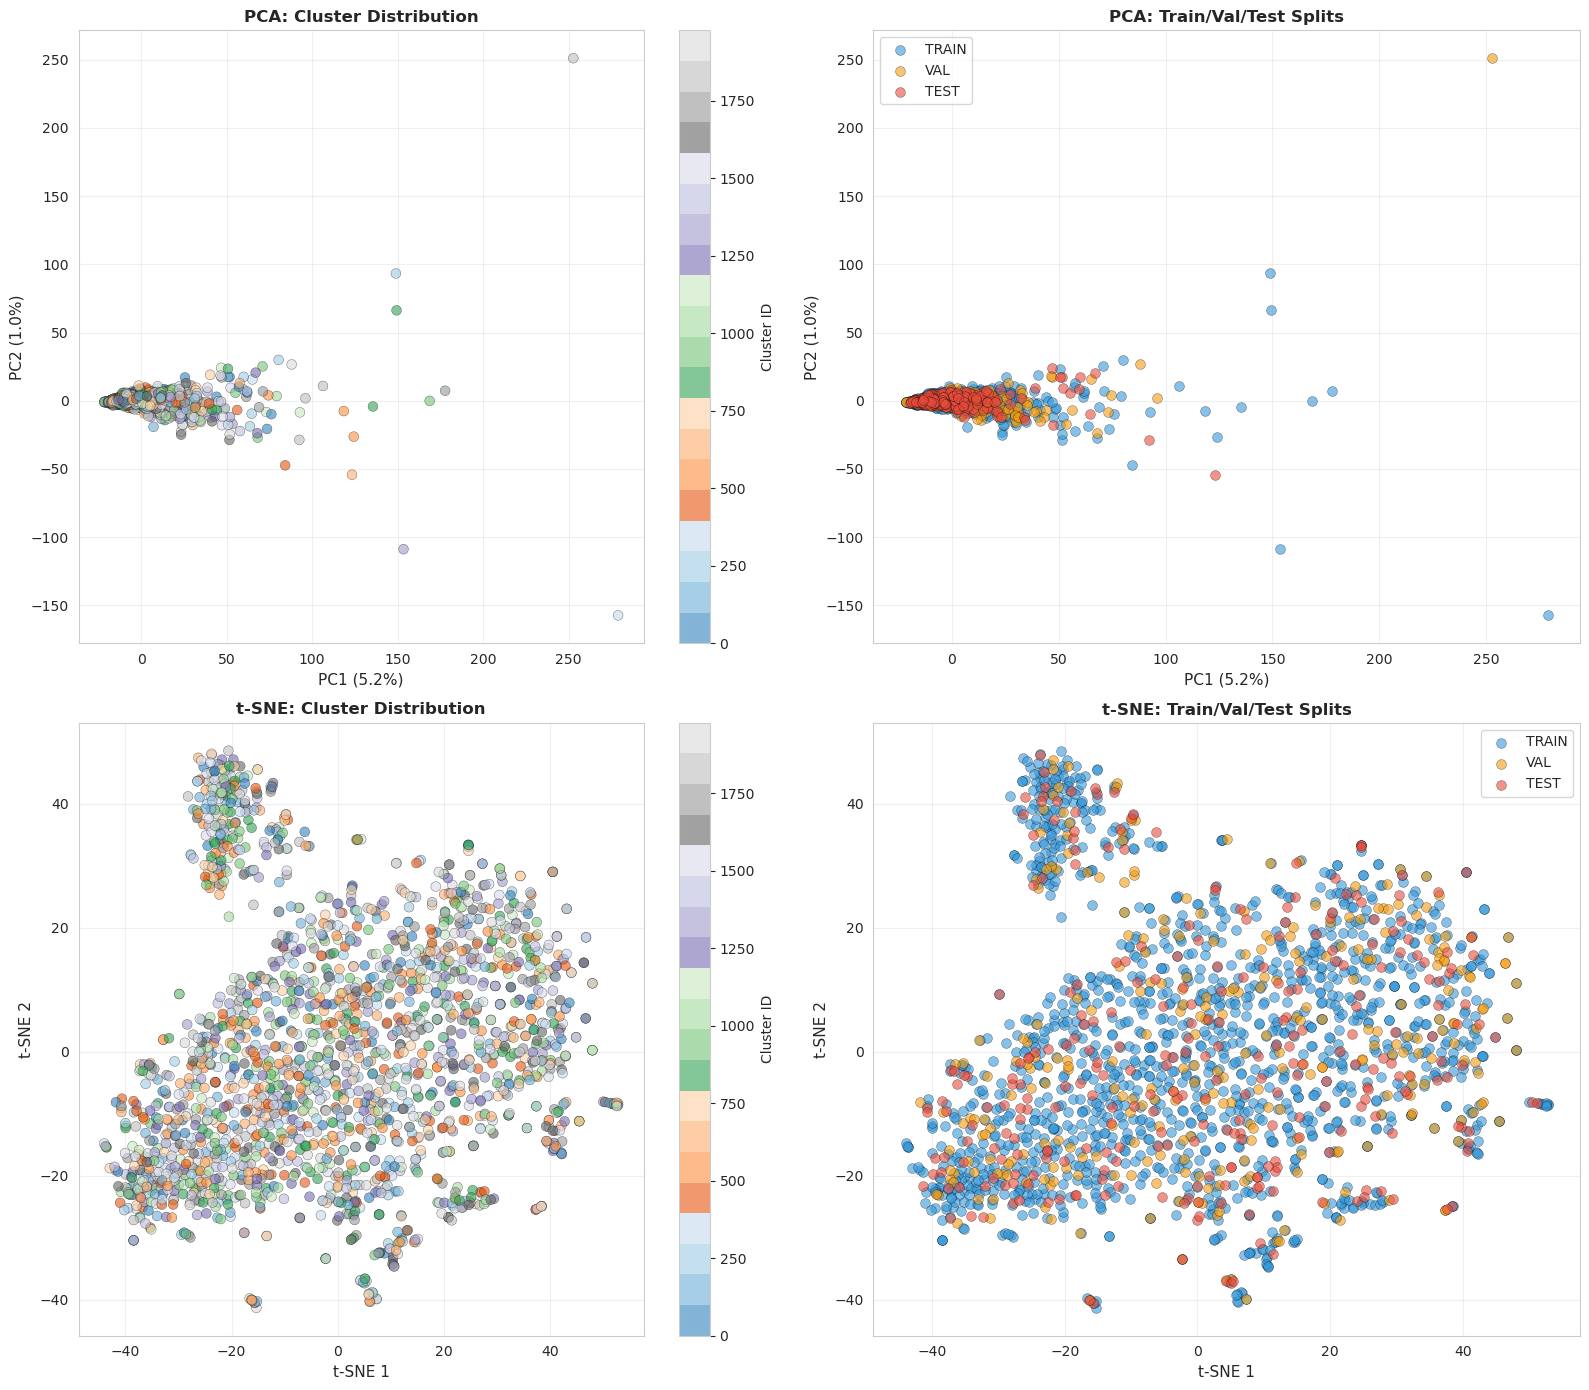


All cluster visualizations complete!
✅ Generated 7 visualization files:
   1. cluster_pca.png - PCA of all clusters
   2. cluster_tsne.png - t-SNE of all clusters
   3. cluster_tsne_splits.png - t-SNE colored by train/val/test
   4. cluster_tsne_sizes.png - t-SNE colored by cluster size
   5. cluster_tsne_seqlen.png - t-SNE colored by sequence length
   6. cluster_comparison_pca_tsne.png - 2x2 comparison figure


In [ ]:
# ========================================================================
# OPTIONAL: Visualize clusters using t-SNE and PCA
# ========================================================================

print("\n" + "=" * 80)
print("VISUALIZING CLUSTERS: t-SNE and PCA")
print("=" * 80)

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Convert sequences to numerical embeddings using ProtT5 or simple encoding
print("\n1️⃣ Encoding sequences...")

def encode_sequence_kmer(sequence, k=3):
    """Simple k-mer encoding of protein sequence"""
    kmers = {}
    for i in range(len(sequence) - k + 1):
        kmer = sequence[i:i+k]
        kmers[kmer] = kmers.get(kmer, 0) + 1
    return kmers

def get_kmer_vector(sequence, all_kmers, k=3):
    """Convert sequence to k-mer frequency vector"""
    kmers = encode_sequence_kmer(sequence, k)
    vector = [kmers.get(kmer, 0) for kmer in all_kmers]
    return vector

# Get all unique 3-mers from representative proteins
print("Computing k-mer frequencies...")
all_kmers = set()
for seq in representative_proteins['sequence']:
    for i in range(len(seq) - 2):
        all_kmers.add(seq[i:i+3])

all_kmers = sorted(list(all_kmers))
print(f"  - Total unique 3-mers: {len(all_kmers):,}")

# Create k-mer vectors for all representative proteins
kmer_vectors = []
for seq in representative_proteins['sequence']:
    kmer_vectors.append(get_kmer_vector(seq, all_kmers, k=3))

X_kmers = np.array(kmer_vectors)
print(f"  - K-mer matrix shape: {X_kmers.shape}")

# Normalize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_kmers)
print(f"✅ Sequences encoded and scaled")

# Get cluster IDs for colors
cluster_ids = representative_proteins['cluster_id'].values
print(f"  - Unique clusters: {len(np.unique(cluster_ids))}")

# ========================================================================
# PCA Visualization
# ========================================================================

print("\n2️⃣ Computing PCA...")
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"  - PCA variance explained: {pca.explained_variance_ratio_.sum():.1%}")
print(f"  - PC1: {pca.explained_variance_ratio_[0]:.1%}")
print(f"  - PC2: {pca.explained_variance_ratio_[1]:.1%}")

fig, ax = plt.subplots(figsize=(14, 10))

# Create scatter plot
scatter = ax.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=cluster_ids, cmap='tab20c', s=100, alpha=0.6, edgecolors='black', linewidth=0.5
)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=12)
ax.set_title(f'PCA of Representative Proteins\n(n={len(representative_proteins):,} clusters={len(np.unique(cluster_ids))})',
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax, label='Cluster ID')

plt.tight_layout()
plt.savefig('/scratch/yunmin/data/graph/train/cluster_pca.png', dpi=300, bbox_inches='tight')
print("✅ Saved: /scratch/yunmin/data/graph/train/cluster_pca.png")
plt.show()

# ========================================================================
# t-SNE Visualization (with perplexity optimization)
# ========================================================================

print("\n3️⃣ Computing t-SNE...")
print("  (This may take a few minutes for large datasets)")

# Use PCA as preprocessing for t-SNE (faster)
X_pca_50 = PCA(n_components=50).fit_transform(X_scaled)

tsne = TSNE(
    n_components=2,
    random_state=RANDOM_SEED,
    perplexity=min(30, (len(representative_proteins) - 1) // 3),
    max_iter=1000,
    verbose=1
)
X_tsne = tsne.fit_transform(X_pca_50)

print(f"✅ t-SNE completed")

fig, ax = plt.subplots(figsize=(14, 10))

# Create scatter plot
scatter = ax.scatter(
    X_tsne[:, 0], X_tsne[:, 1],
    c=cluster_ids, cmap='tab20c', s=100, alpha=0.6, edgecolors='black', linewidth=0.5
)

ax.set_xlabel('t-SNE 1', fontsize=12)
ax.set_ylabel('t-SNE 2', fontsize=12)
ax.set_title(f't-SNE of Representative Proteins\n(n={len(representative_proteins):,} clusters={len(np.unique(cluster_ids))})',
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax, label='Cluster ID')

plt.tight_layout()
plt.savefig('/scratch/yunmin/data/graph/train/cluster_tsne.png', dpi=300, bbox_inches='tight')
print("✅ Saved: /scratch/yunmin/data/graph/train/cluster_tsne.png")
plt.show()

# ========================================================================
# Train/Val/Test Split Visualization (t-SNE)
# ========================================================================

print("\n4️⃣ Visualizing Train/Val/Test splits on t-SNE...")

# Map cluster IDs to split assignments
cluster_to_split = pd.DataFrame({
    'cluster_id': list(train_clusters) + list(val_clusters) + list(test_clusters),
    'split': ['train'] * len(train_clusters) + ['val'] * len(val_clusters) + ['test'] * len(test_clusters)
}).set_index('cluster_id')['split'].to_dict()

split_labels = representative_proteins['cluster_id'].map(cluster_to_split)

# Create color mapping
split_colors = {'train': '#3498db', 'val': '#f39c12', 'test': '#e74c3c'}
split_color_array = [split_colors[s] for s in split_labels]

fig, ax = plt.subplots(figsize=(14, 10))

for split in ['train', 'val', 'test']:
    mask = split_labels == split
    ax.scatter(
        X_tsne[mask, 0], X_tsne[mask, 1],
        c=split_colors[split], s=100, alpha=0.6,
        edgecolors='black', linewidth=0.5, label=split.upper()
    )

ax.set_xlabel('t-SNE 1', fontsize=12)
ax.set_ylabel('t-SNE 2', fontsize=12)
ax.set_title(f't-SNE: Train/Val/Test Split Distribution\n(n={len(representative_proteins):,})',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=12, loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/scratch/yunmin/data/graph/train/cluster_tsne_splits.png', dpi=300, bbox_inches='tight')
print("✅ Saved: /scratch/yunmin/data/graph/train/cluster_tsne_splits.png")
plt.show()

# ========================================================================
# Cluster Size Heatmap on t-SNE
# ========================================================================

print("\n5️⃣ Visualizing cluster sizes on t-SNE...")

# Get cluster sizes
cluster_sizes_map = {cid: len(members) for cid, members in clusters.items()}
sizes = representative_proteins['cluster_id'].map(cluster_sizes_map)

fig, ax = plt.subplots(figsize=(14, 10))

scatter = ax.scatter(
    X_tsne[:, 0], X_tsne[:, 1],
    c=np.log10(sizes), cmap='viridis', s=100, alpha=0.6,
    edgecolors='black', linewidth=0.5
)

ax.set_xlabel('t-SNE 1', fontsize=12)
ax.set_ylabel('t-SNE 2', fontsize=12)
ax.set_title(f't-SNE: Cluster Sizes (log scale)\n(n={len(representative_proteins):,})',
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

cbar = plt.colorbar(scatter, ax=ax, label='log10(Cluster Size)')

plt.tight_layout()
plt.savefig('/scratch/yunmin/data/graph/train/cluster_tsne_sizes.png', dpi=300, bbox_inches='tight')
print("✅ Saved: /scratch/yunmin/data/graph/train/cluster_tsne_sizes.png")
plt.show()

# ========================================================================
# Sequence Length on t-SNE
# ========================================================================

print("\n6️⃣ Visualizing sequence length on t-SNE...")

seq_lengths = representative_proteins['sequence_length'].values

fig, ax = plt.subplots(figsize=(14, 10))

scatter = ax.scatter(
    X_tsne[:, 0], X_tsne[:, 1],
    c=seq_lengths, cmap='plasma', s=100, alpha=0.6,
    edgecolors='black', linewidth=0.5
)

ax.set_xlabel('t-SNE 1', fontsize=12)
ax.set_ylabel('t-SNE 2', fontsize=12)
ax.set_title(f't-SNE: Sequence Length Distribution\n(n={len(representative_proteins):,})',
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

cbar = plt.colorbar(scatter, ax=ax, label='Sequence Length (aa)')

plt.tight_layout()
plt.savefig('/scratch/yunmin/data/graph/train/cluster_tsne_seqlen.png', dpi=300, bbox_inches='tight')
print("✅ Saved: /scratch/yunmin/data/graph/train/cluster_tsne_seqlen.png")
plt.show()

# ========================================================================
# Summary comparison figure
# ========================================================================

print("\n7️⃣ Creating comparison figure...")

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# PCA - Clusters
scatter1 = axes[0, 0].scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=cluster_ids, cmap='tab20c', s=50, alpha=0.6, edgecolors='black', linewidth=0.3
)
axes[0, 0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=11)
axes[0, 0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=11)
axes[0, 0].set_title('PCA: Cluster Distribution', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=axes[0, 0], label='Cluster ID')

# PCA - Splits
for split in ['train', 'val', 'test']:
    mask = split_labels == split
    axes[0, 1].scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=split_colors[split], s=50, alpha=0.6,
        edgecolors='black', linewidth=0.3, label=split.upper()
    )
axes[0, 1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=11)
axes[0, 1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=11)
axes[0, 1].set_title('PCA: Train/Val/Test Splits', fontsize=12, fontweight='bold')
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(True, alpha=0.3)

# t-SNE - Clusters
scatter3 = axes[1, 0].scatter(
    X_tsne[:, 0], X_tsne[:, 1],
    c=cluster_ids, cmap='tab20c', s=50, alpha=0.6, edgecolors='black', linewidth=0.3
)
axes[1, 0].set_xlabel('t-SNE 1', fontsize=11)
axes[1, 0].set_ylabel('t-SNE 2', fontsize=11)
axes[1, 0].set_title('t-SNE: Cluster Distribution', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)
plt.colorbar(scatter3, ax=axes[1, 0], label='Cluster ID')

# t-SNE - Splits
for split in ['train', 'val', 'test']:
    mask = split_labels == split
    axes[1, 1].scatter(
        X_tsne[mask, 0], X_tsne[mask, 1],
        c=split_colors[split], s=50, alpha=0.6,
        edgecolors='black', linewidth=0.3, label=split.upper()
    )
axes[1, 1].set_xlabel('t-SNE 1', fontsize=11)
axes[1, 1].set_ylabel('t-SNE 2', fontsize=11)
axes[1, 1].set_title('t-SNE: Train/Val/Test Splits', fontsize=12, fontweight='bold')
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/scratch/yunmin/data/graph/train/cluster_comparison_pca_tsne.png', dpi=300, bbox_inches='tight')
print("✅ Saved: /scratch/yunmin/data/graph/train/cluster_comparison_pca_tsne.png")
plt.show()

print("\n" + "=" * 80)
print("All cluster visualizations complete!")
print("=" * 80)
print(f"✅ Generated 7 visualization files:")
print(f"   1. cluster_pca.png - PCA of all clusters")
print(f"   2. cluster_tsne.png - t-SNE of all clusters")
print(f"   3. cluster_tsne_splits.png - t-SNE colored by train/val/test")
print(f"   4. cluster_tsne_sizes.png - t-SNE colored by cluster size")
print(f"   5. cluster_tsne_seqlen.png - t-SNE colored by sequence length")
print(f"   6. cluster_comparison_pca_tsne.png - 2x2 comparison figure")